<h6>
<u>File</u>: clustering_eval.ipynb <br>
<br>
<u>Author</u>: Prabhjot Singh (prabhjot@fnal.gov) <br>
<br>
<u>Goal</u>: an internal notebook to be run by main_cluster_eval.ipynb. It is automatically run. <br>
<br>

### Helper function

In [2]:
import builtins
print = builtins.print

print("")
print("We are ready to start the clustering evaluation process.")
print("We are now running script: clustering_eval.ipynb. This script does the actual work.")
print("We call this script from the main workflow script: main_cluster_eval.ipynb")
print("")


We are ready to start the clustering evaluation process.
We are now running script: clustering_eval.ipynb. This script does the actual work.
We call this script from the main workflow script: main_cluster_eval.ipynb



In [3]:
# skip notebook if missing truth files
SKIP_NOTEBOOK = False   # TODO: what does this do?

print ("Checking for required truth files...")

# helper function to skip notebook execution
def skip_if_needed():
    if globals().get("SKIP_NOTEBOOK", False):
        return True
    return False

Checking for required truth files...


In [4]:
# Just adding some variables here for testing purposes to make sure this script actually runs
# Otherwise we pass these variables from the main script

SBNDCODE_VERSION    = "v10_06_00"   # Use the latest version available
PROCESS             = "nu_spill"    # options: "nu_spill", "cosmic_spill"
evt                 = 1
apa                 = "APA0"        # options: "APA0", "APA1"
metric              = "efficiency"  # options: "efficiency", "purity"
knn_dist_threshold  = 1.0           # in cm
min_cluster_energy  = 10            # in MeV

print("SBNDCODE_VERSION:", SBNDCODE_VERSION)
print("PROCESS:", PROCESS)
print("evt:", evt)
print("apa:", apa)
print("metric:", metric)
print("knn_dist_threshold:", knn_dist_threshold)
print("min_cluster_energy:", min_cluster_energy)

SBNDCODE_VERSION: v10_06_00
PROCESS: nu_spill
evt: 1
apa: APA0
metric: efficiency
knn_dist_threshold: 1.0
min_cluster_energy: 10


In [5]:
# some other user defined variables
marker_size = 5

In [1]:
# read input and create arrays
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import sys
import os
from scipy.spatial import KDTree

OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/out/")
SUBDIR="24308437_0" # TODO: we need to find a way of not hardcoding this
OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"
else:
  print("\n Incorrect PROCESS.\n\n")

def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

def read_pred_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q 

NEWOUTDIR     = OUTDIR/"xyz-coordinates"    
fx_true_apa0  = NEWOUTDIR / str(evt) / "x_truth_apa0.txt"
fy_true_apa0  = NEWOUTDIR / str(evt) / "y_truth_apa0.txt"
fz_true_apa0  = NEWOUTDIR / str(evt) / "z_truth_apa0.txt"
fq_true_apa0  = NEWOUTDIR / str(evt) / "charge_truth_apa0.txt"
fid_true_apa0 = NEWOUTDIR / str(evt) / "clusterid_truth_apa0.txt"
fe_true_apa0  = NEWOUTDIR / str(evt) / "energy_truth_apa0.txt"
ft_true_apa0  = NEWOUTDIR / str(evt) / "time_truth_apa0.txt"

fx_true_apa1  = NEWOUTDIR / str(evt) / "x_truth_apa1.txt"
fy_true_apa1  = NEWOUTDIR / str(evt) / "y_truth_apa1.txt"
fz_true_apa1  = NEWOUTDIR / str(evt) / "z_truth_apa1.txt"
fq_true_apa1  = NEWOUTDIR / str(evt) / "charge_truth_apa1.txt"
fid_true_apa1 = NEWOUTDIR / str(evt) / "clusterid_truth_apa1.txt"
fe_true_apa1  = NEWOUTDIR / str(evt) / "energy_truth_apa1.txt"
ft_true_apa1  = NEWOUTDIR / str(evt) / "time_truth_apa1.txt"

fx_pred_apa0  = NEWOUTDIR / str(evt) / "x_clustering_apa0.txt"
fy_pred_apa0  = NEWOUTDIR / str(evt) / "y_clustering_apa0.txt"
fz_pred_apa0  = NEWOUTDIR / str(evt) / "z_clustering_apa0.txt"
fq_pred_apa0  = NEWOUTDIR / str(evt) / "charge_clustering_apa0.txt"
fid_pred_apa0 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa0.txt"

fx_pred_apa1  = NEWOUTDIR / str(evt) / "x_clustering_apa1.txt"
fy_pred_apa1  = NEWOUTDIR / str(evt) / "y_clustering_apa1.txt"
fz_pred_apa1  = NEWOUTDIR / str(evt) / "z_clustering_apa1.txt"
fq_pred_apa1  = NEWOUTDIR / str(evt) / "charge_clustering_apa1.txt"
fid_pred_apa1 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa1.txt"

# check for missing or empty truth files
if apa =='APA0':
    if not fx_true_apa0.exists() or os.stat(fx_true_apa0).st_size <= 1:
        print(f"{fx_true_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_true_apa0.exists() or os.stat(fy_true_apa0).st_size<= 1:
        print(f"{fy_true_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_true_apa0.exists() or os.stat(fz_true_apa0).st_size <= 1:
        print(f"{fz_true_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fx_pred_apa0.exists() or os.stat(fx_pred_apa0).st_size <= 1:
        print(f"{fx_pred_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_pred_apa0.exists() or os.stat(fy_pred_apa0).st_size<= 1:
        print(f"{fy_pred_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_pred_apa0.exists() or os.stat(fz_pred_apa0).st_size <= 1:
        print(f"{fz_pred_apa0} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
elif apa =='APA1':
    if not fx_true_apa1.exists() or os.stat(fx_true_apa1).st_size <= 1:
        print(f"{fx_true_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_true_apa1.exists() or os.stat(fy_true_apa1).st_size <= 1:
        print(f"{fy_true_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_true_apa1.exists() or os.stat(fz_true_apa1).st_size <= 1:
        print(f"{fz_true_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fx_pred_apa1.exists() or os.stat(fx_pred_apa1).st_size <= 1:
        print(f"{fx_pred_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fy_pred_apa1.exists() or os.stat(fy_pred_apa1).st_size<= 1:
        print(f"{fy_pred_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
    if not fz_pred_apa1.exists() or os.stat(fz_pred_apa1).st_size <= 1:
        print(f"{fz_pred_apa1} not found or empty. Skipping rest of notebook.")
        SKIP_NOTEBOOK = True
else:
  print("Incorrect apa.")
    
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    
    # group files for loading
    true_files_apa0 = [fx_true_apa0, fy_true_apa0, fz_true_apa0, fid_true_apa0, fq_true_apa0, fe_true_apa0, ft_true_apa0]  # Replace with file names
    true_files_apa1 = [fx_true_apa1, fy_true_apa1, fz_true_apa1, fid_true_apa1, fq_true_apa1, fe_true_apa1, ft_true_apa1]  # Replace with file names
    pred_files_apa0 = [fx_pred_apa0, fy_pred_apa0, fz_pred_apa0, fid_pred_apa0, fq_pred_apa0]
    pred_files_apa1 = [fx_pred_apa1, fy_pred_apa1, fz_pred_apa1, fid_pred_apa1, fq_pred_apa1]

    # Define placeholders
    x_true = y_true = z_true = id_true = q_true = e_true = t_true = None
    x_pred = y_pred = z_pred = id_pred = q_pred = None

    # Load the true and predicted coordinates
    if apa =='APA0':
      x_true_apa0, y_true_apa0, z_true_apa0, id_true_apa0, q_true_apa0, e_true_apa0 , t_true_apa0 = read_true_coordinates(true_files_apa0)
      x_pred_apa0, y_pred_apa0, z_pred_apa0, id_pred_apa0, q_pred_apa0              = read_pred_coordinates(pred_files_apa0)
      
      x_true  = x_true_apa0
      y_true  = y_true_apa0
      z_true  = z_true_apa0
      id_true = id_true_apa0
      q_true  = q_true_apa0
      e_true  = e_true_apa0
      t_true  = t_true_apa0

      x_pred  = x_pred_apa0
      y_pred  = y_pred_apa0
      z_pred  = z_pred_apa0
      id_pred = id_pred_apa0
      q_pred  = q_pred_apa0

    elif apa =='APA1':
      x_true_apa1, y_true_apa1, z_true_apa1, id_true_apa1, q_true_apa1, e_true_apa1, t_true_apa1= read_true_coordinates(true_files_apa1)
      x_pred_apa1, y_pred_apa1, z_pred_apa1, id_pred_apa1, q_pred_apa1              = read_pred_coordinates(pred_files_apa1)
      
      x_true  = x_true_apa1
      y_true  = y_true_apa1
      z_true  = z_true_apa1
      id_true = id_true_apa1
      q_true  = q_true_apa1   
      e_true  = e_true_apa1
      t_true  = t_true_apa1

      x_pred  = x_pred_apa1
      y_pred  = y_pred_apa1
      z_pred  = z_pred_apa1
      id_pred = id_pred_apa1
      q_pred  = q_pred_apa1

    else:
      print("Incorrect apa.") 

NameError: name 'PROCESS' is not defined

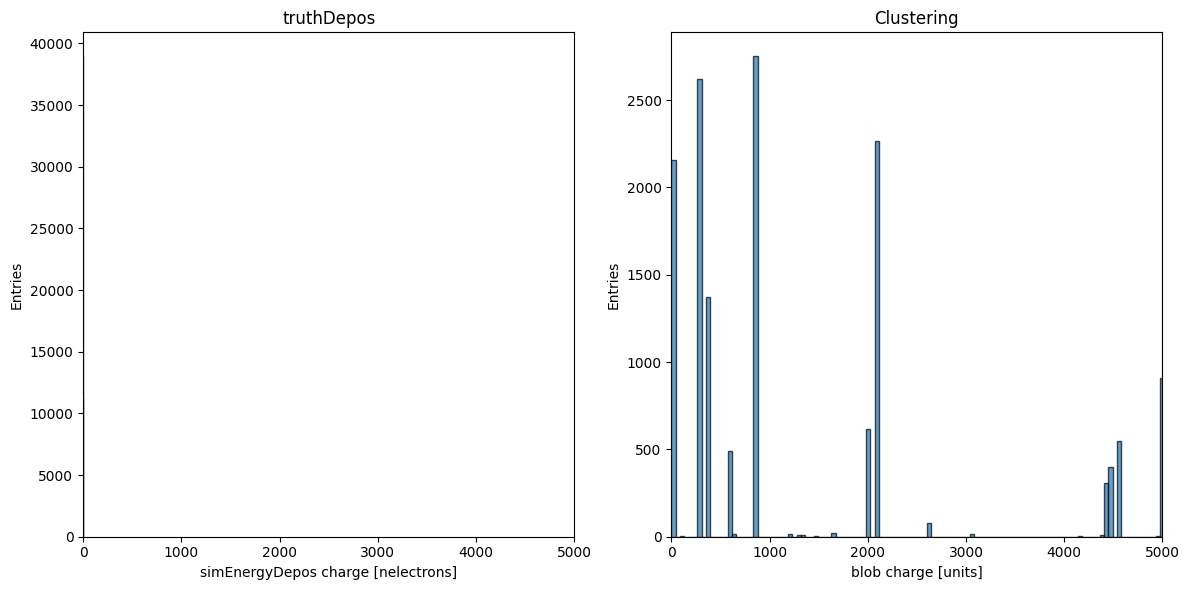

In [7]:
# For Illustration: Plotting histograms of true and predicted charges

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    
    # Create figure and subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

    # First scatter plot (left)
    axes[0].hist(q_true, bins=200, edgecolor='black', alpha=0.7)
    axes[0].set_xlim(0, 5000) # Set x-axis range
    #axes[0].set_ylim(-150, 0)  # Set y-axis range
    axes[0].set_xlabel("simEnergyDepos charge [nelectrons]")
    axes[0].set_ylabel("Entries")
    axes[0].set_title("truthDepos")

    # First scatter plot (left)
    axes[1].hist(q_pred, bins=200, edgecolor='black', alpha=0.7)
    axes[1].set_xlim(0, 5000) # Set x-axis range
    #axes[1].set_ylim(-150, 0)  # Set y-axis range
    axes[1].set_xlabel("blob charge [units]")
    axes[1].set_ylabel("Entries")
    axes[1].set_title("Clustering")

    # Adjust layout and show plot
    plt.tight_layout()
    # plt.show(block=False)

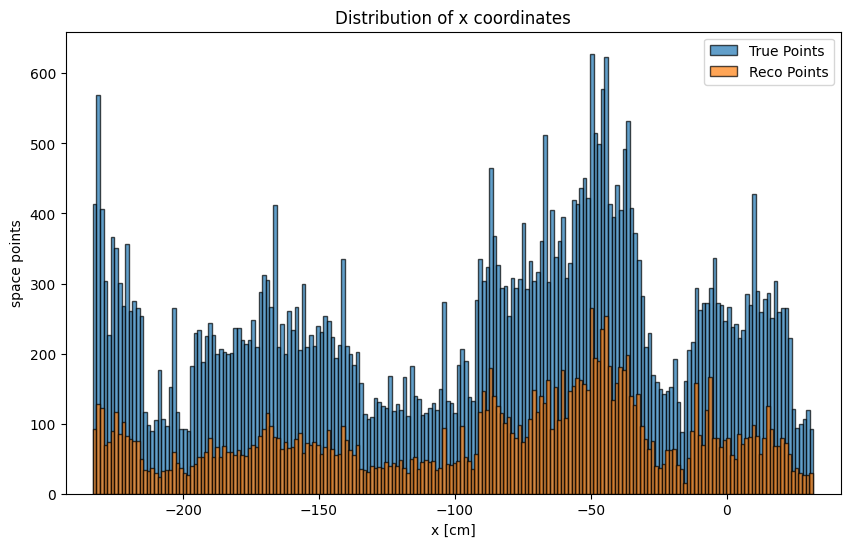

In [8]:
# draw all x values for true points and reco points in one plot to see the distribution of points in x direction
plt.figure(figsize=(10, 6))
plt.hist(x_true, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(x_pred, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(x_true.min() - 10, x_true.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("x [cm]")
plt.ylabel("space points")
plt.title("Distribution of x coordinates")
plt.legend()
# plt.show(block=False)

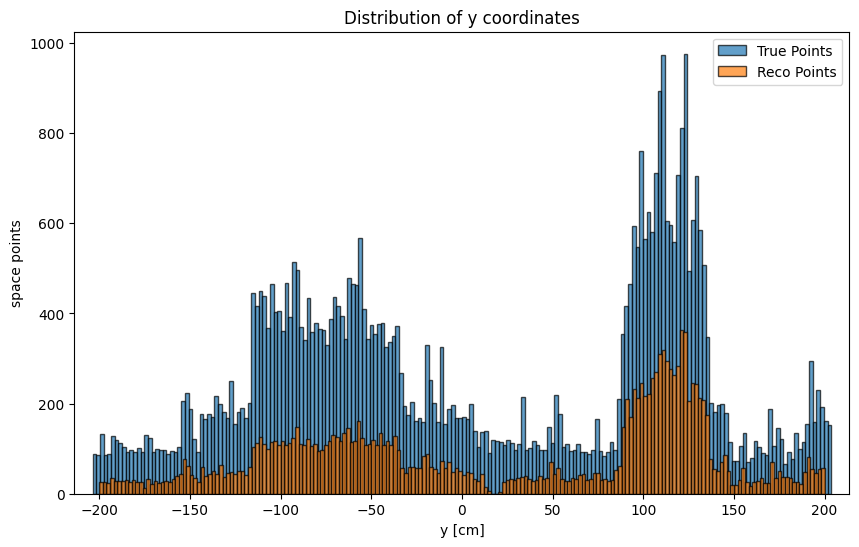

In [9]:
# draw all y values for true points and reco points in one plot to see the distribution of points in x direction
plt.figure(figsize=(10, 6))
plt.hist(y_true, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(y_pred, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(y_true.min() - 10, y_true.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("y [cm]")
plt.ylabel("space points")
plt.title("Distribution of y coordinates")
plt.legend()
# plt.show(block=False)

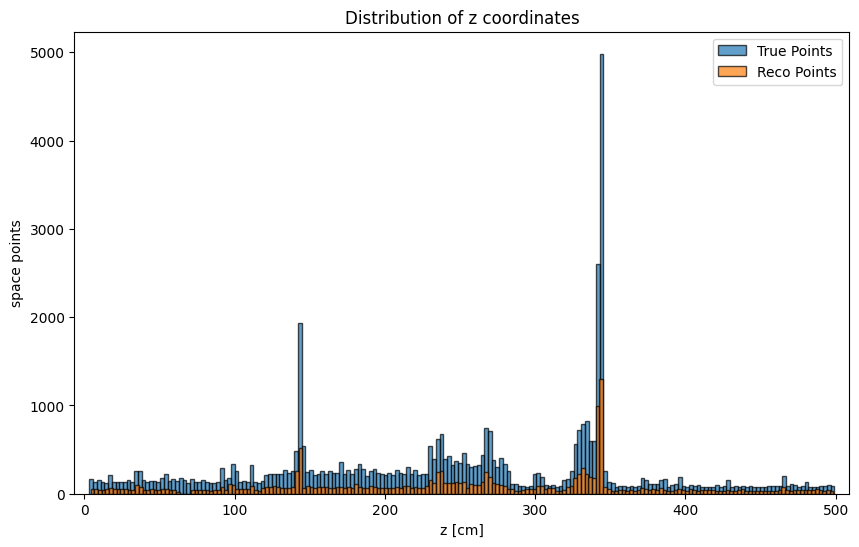

In [10]:
# draw all z values for true points and reco points in one plot to see the distribution of points in x direction
plt.figure(figsize=(10, 6))
plt.hist(z_true, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(z_pred, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(z_true.min() - 10, z_true.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("z [cm]")
plt.ylabel("space points")
plt.title("Distribution of z coordinates")
plt.legend()
# plt.show(block=False)

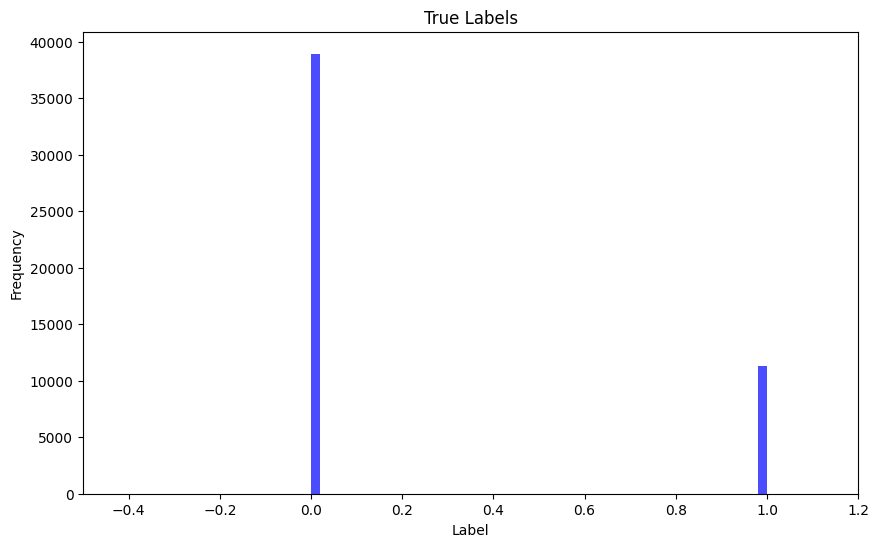

In [11]:
# make a plot of q_true
plt.figure(figsize=(10, 6))
plt.hist(q_true, bins=50, alpha=0.7, color='blue')
plt.title('True Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xlim(-0.5, 1.2)
plt.show()

In [12]:
# lets draw true time for clusters with q_true = 1
# draw this only if there is a neutrino cluster otherwise do not draw this plot

if q_true.all == 1:
  plt.figure(figsize=(10, 6))
  plt.hist(t_true[q_true == 1], bins=2000, edgecolor='orange', alpha=0.7, color='orange')
  #plt.xlim(-1000000, 1000000)
  plt.xlim(-2000, 4000)
  plt.xlabel("true time [ticks?]")
  plt.ylabel("Entries")
  plt.title(f"true time distribution for neutrino cluster APA {apa}")
  plt.tight_layout()
  # plt.show(block=False)

  # print some values of t_true for q_true = 1 to see the range of true time for these clusters
  print("True time values for q_true = 1:")
  print(t_true[q_true == 1][:10]) # print first 100 values

  # draw its x
  plt.figure(figsize=(10, 6))
  plt.hist(x_true[q_true == 1], bins=100, edgecolor='orange', alpha=0.7, color='orange')
  plt.xlim(x_true.min() - 10, x_true.max() + 10) # Set x-axis range based on true points
  plt.xlabel("x [cm]")
  plt.ylabel("space points")
  plt.title(f"x distribution for neutrino cluster for {apa}")
  plt.tight_layout()
  # plt.show(block=False)

  print("xlow: ", np.min(x_true[q_true == 1]), " xhigh: ", np.max(x_true[q_true == 1]))
else:
  print("No neutrino cluster found for APA", apa)



No neutrino cluster found for APA APA0


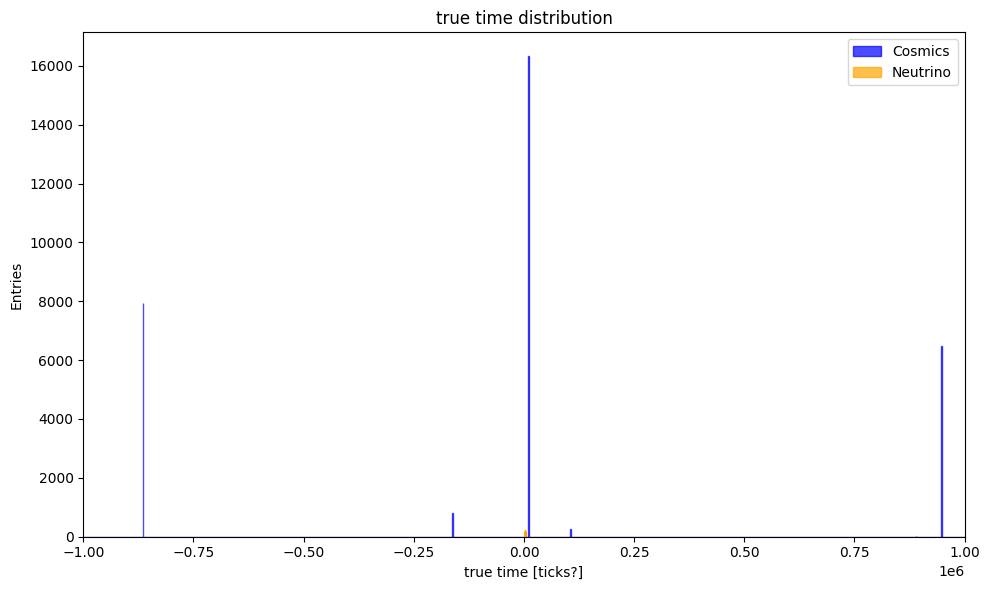

Minimum true time: -1375526.9
Maximum true time: 1194932.2


In [13]:
# make a plot of true time 
plt.figure(figsize=(10, 6))
plt.hist(t_true[q_true == 0], bins=2000, edgecolor='blue', alpha=0.7, color='blue', label='Cosmics')
plt.hist(t_true[q_true == 1], bins=2000, edgecolor='orange', alpha=0.7, color='orange', label='Neutrino')
plt.xlim(-1000000, 1000000)
plt.xlabel("true time [ticks?]")
plt.ylabel("Entries")
plt.title("true time distribution")
plt.tight_layout()
plt.legend()
# plt.show(block=False)


# find the minimum and maximum true time to get a sense of the range
print("Minimum true time:", np.min(t_true))
print("Maximum true time:", np.max(t_true))

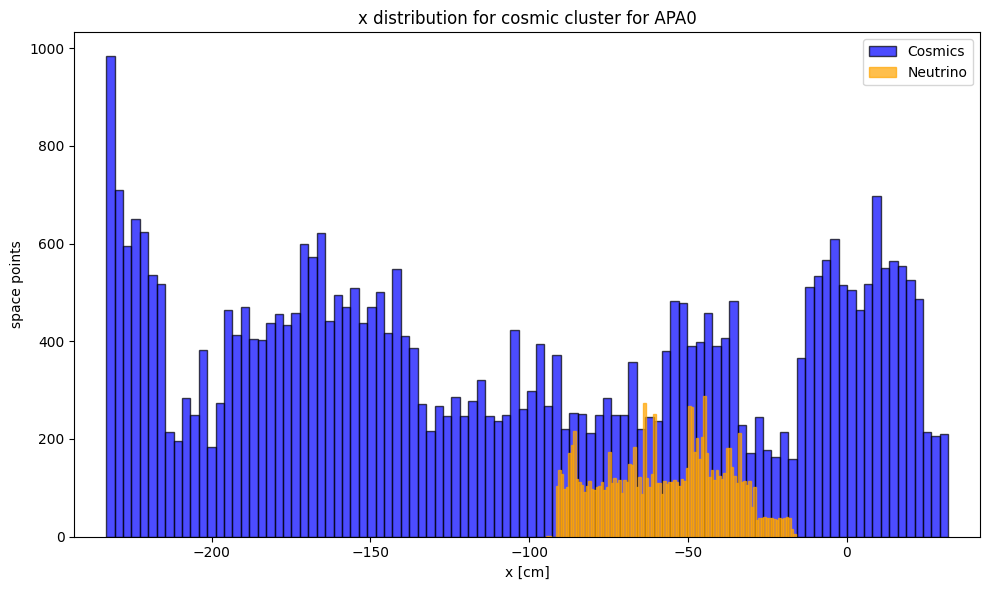

In [14]:
# draw x for cosmics
plt.figure(figsize=(10, 6))
plt.hist(x_true[q_true == 0], bins=100, edgecolor='black', alpha=0.7, color='blue', label='Cosmics')
plt.hist(x_true[q_true == 1], bins=100, edgecolor='orange', alpha=0.7, color='orange', label='Neutrino')
plt.xlim(x_true.min() - 10, x_true.max() + 10) # Set x-axis range based on true points
plt.xlabel("x [cm]")
plt.ylabel("space points")
plt.title(f"x distribution for cosmic cluster for {apa}")
plt.tight_layout()
plt.legend()
# plt.show(block=False)

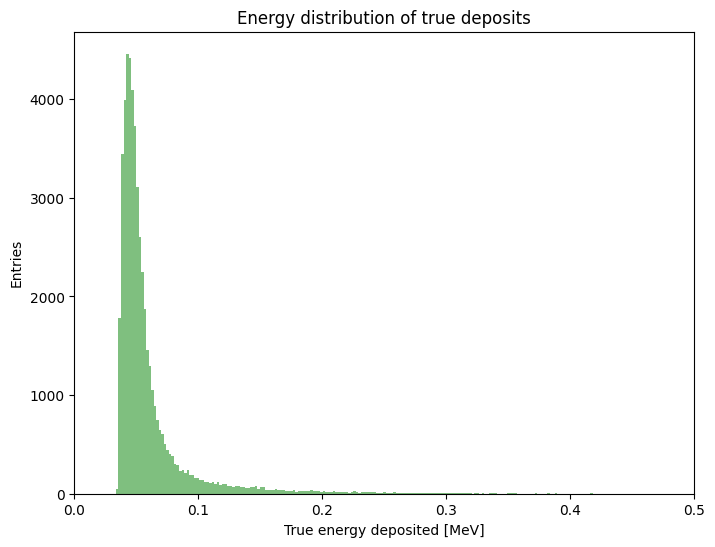

In [15]:
# For Illustration: Plotting energy of true deposits

plt.figure(figsize=(8, 6))
plt.hist(e_true, bins=1000, color='green', alpha=0.5)
plt.xlim(0, 0.5) # Set x-axis range
plt.xlabel("True energy deposited [MeV]")
plt.ylabel("Entries")
plt.title("Energy distribution of true deposits")
# plt.show(block=False)





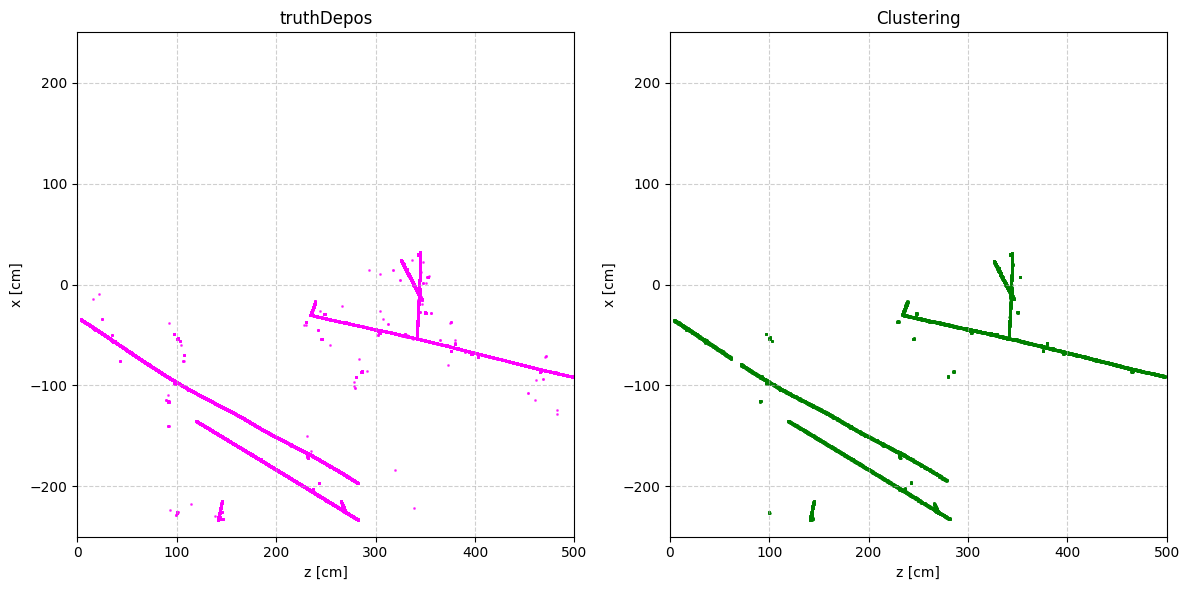

In [16]:
# Draw 2D scatter plots of x vs z for truth and predicted data

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:

    # plot 2D
    import matplotlib.pyplot as plt

    # Create figure and subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

    # First scatter plot (left)
    axes[0].scatter(z_true, x_true, color='magenta', alpha=0.7, s=1)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("x [cm]")
    axes[0].set_title("truthDepos")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # First scatter plot (left)
    axes[1].scatter(z_pred, x_pred, color='green', alpha=0.7, s=1)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("x [cm]")
    axes[1].set_title("Clustering")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Adjust layout and show plot
    plt.tight_layout()
    # plt.show(block=False)

In [17]:
# In this block, we evaluate the true energy per cluster by adding up the e_true values for each unique id_true.
# Then we apply a minimum cluster energy cut (min_cluster_energy) to filter out low-energy clusters.

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    
    # apply energy cutoff for each true cluster
    true_5d_points = np.column_stack((x_true, y_true, z_true, id_true, q_true, e_true, t_true))

    # Compute sum of e_true per cluster (grouped by id_true)
    cluster_sums = {}
    for point in true_5d_points:
        cluster_sums[point[3]] = cluster_sums.get(point[3], 0) + point[5]  # id_true at index 3, e_true at index 5

    # Filter points, keeping only clusters where sum(e_true) >= min_cluster_energy
    true_5d_points = np.array([point for point in true_5d_points if cluster_sums[point[3]] >= min_cluster_energy])

    # skip if no truth clusters with min_cluster_energy
    if(len(true_5d_points)==0):
        SKIP_NOTEBOOK = True

    print(len(true_5d_points) , "true points after energy cut of", min_cluster_energy, "nelectrons")
    print("Structure of true_5d_points:", true_5d_points.shape)

49860 true points after energy cut of 10 nelectrons
Structure of true_5d_points: (49860, 7)


In [18]:
# In this block, we re-assign the cluster ID of each true point to be the average x-position of its cluster.
# This is done to facilitate comparison with predicted clusters.
# This way each cluster ID corresponds to a average x-position (drift time) of the cluster.

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:

    # re-assign cluster ID to be the average x-position of the cluster
    import numpy as np

    # Group points by ID and compute average x for each cluster
    clusters = {}
    for point in true_5d_points:   
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)

    # Compute new cluster IDs based on average x position
    new_points = []
    for cluster_id, points in clusters.items():
        points = np.array(points)
        avg_x = np.mean(points[:, 0])  # Compute average x-position, 0 is x-coordinate index
        # convert avg_x to nearest integer (since x is in cm, we can round to nearest cm)
        #avg_x = round(avg_x)
        if points[:, 4].any() == 1:
            avg_x = 9999
        else:
            avg_x = round(avg_x)
        points[:, 3] = avg_x  # Reassign cluster ID to avg_x, because index 3 is cluster ID
        new_points.append(points)

    # Flatten list into a NumPy array
    true_5d_points = np.vstack(new_points)

    print("After re-assinging, we still have ", len(true_5d_points), " true points in ", len(clusters), " clusters, with structure", true_5d_points.shape)

After re-assinging, we still have  49860  true points in  9  clusters, with structure (49860, 7)


Cluster ID (avg x): 9999.0  Number of points: 11190
Cluster ID (avg x): -227.0  Number of points: 2302
Cluster ID (avg x): -116.0  Number of points: 16321
Cluster ID (avg x): -10.0  Number of points: 6483
Cluster ID (avg x): -221.0  Number of points: 802
Cluster ID (avg x): 5.0  Number of points: 4803
Cluster ID (avg x): -186.0  Number of points: 7937
Cluster ID (avg x): -59.0  Number of points: 22
We have  8  true clusters


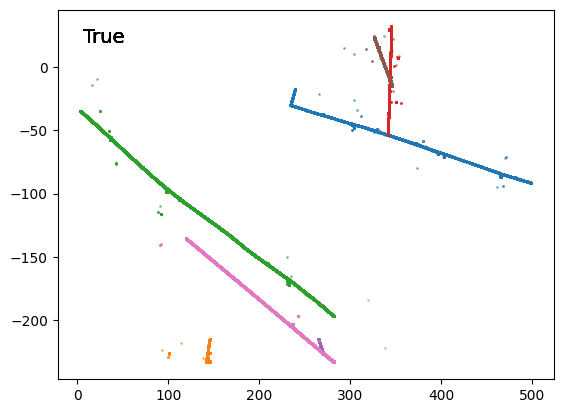

In [19]:
# Lets redraw true clusters
# Give different color for each cluster

# Group points by ID and draw each true cluster by a different color
clusters_true = {}
for point in true_5d_points:   
    cluster_id = point[3]  # Original cluster ID
    if cluster_id not in clusters_true:
        clusters_true[cluster_id] = []
    clusters_true[cluster_id].append(point)

for cluster_id, points in clusters_true.items():
    print( "Cluster ID (avg x):", cluster_id, " Number of points:", len(points))
    points = np.array(points)
    true_x_cluster = points[:, 0]
    true_z_cluster = points[:, 2]
    scatter = plt.scatter(true_z_cluster, true_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    plt.plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    # write True on the top left corner of the plot
    plt.text(0.05, 0.95, 'True', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')   
    # #plt.legend()

print("We have ", len(clusters_true), " true clusters")

Cluster ID (avg x) vs sum of e_true in that cluster:
Cluster ID (avg x)    sum of e_true in that cluster
           9999.0000             738.6468
           -227.0000             139.7231
           -116.0000             936.8797
            -10.0000             373.7135
           -221.0000              46.8867
              5.0000             285.7513
           -186.0000             475.0489
            -59.0000              22.9679


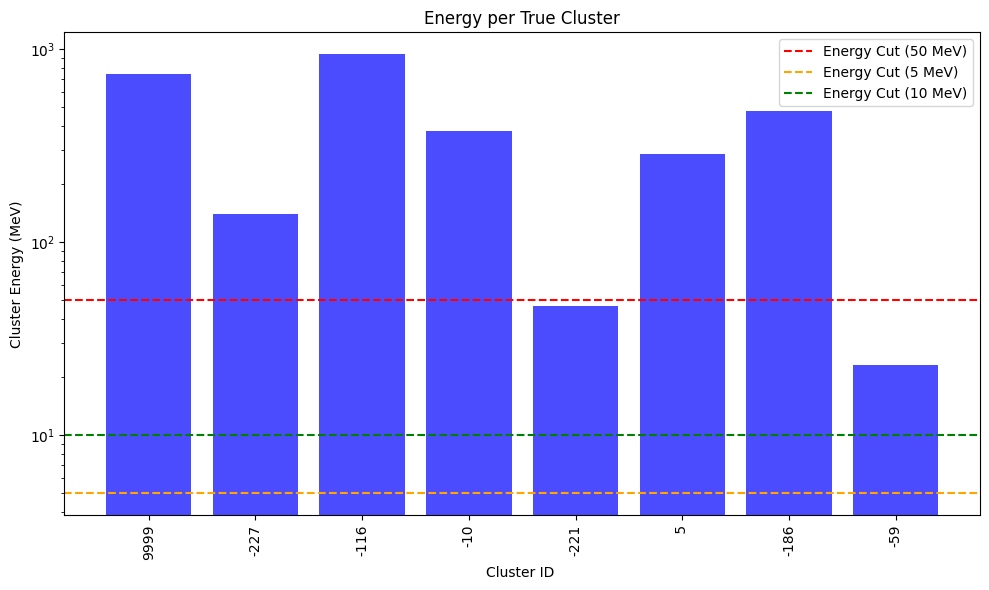

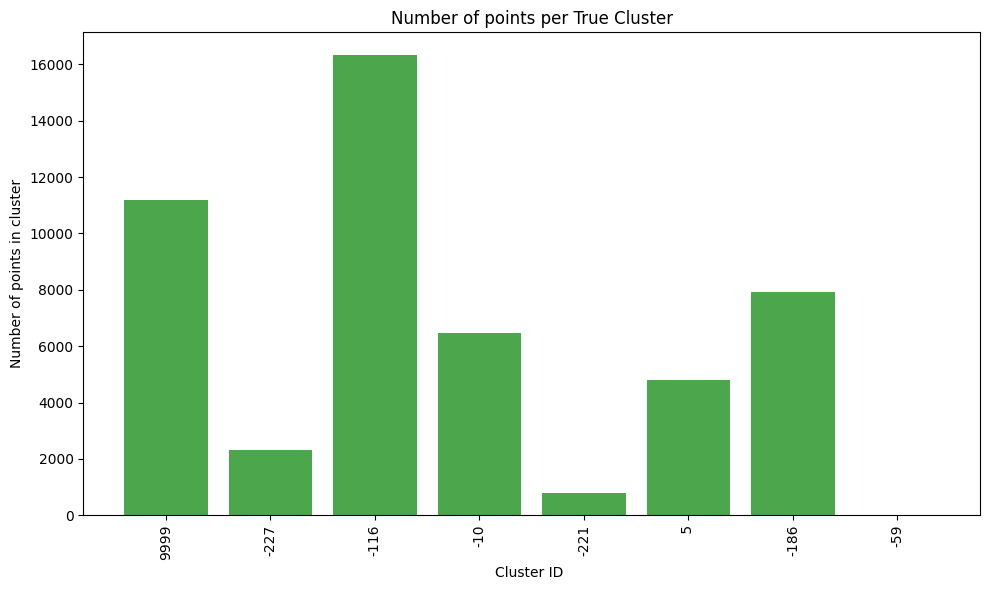

In [20]:
# For each true cluster sum of e_true and make a table of cluster ID (avg x) vs sum of q_true in that cluster.
print("Cluster ID (avg x) vs sum of e_true in that cluster:")
print("Cluster ID (avg x)    sum of e_true in that cluster")
for cluster_id, points in clusters_true.items():
    points = np.array(points)
    sum_e_true = np.sum(points[:, 5])  # e_true is at index 5
    print(f"{cluster_id:20.4f} {sum_e_true:20.4f}")
    # draw a bar plot of cluster ID vs sum of q_true
plt.figure(figsize=(10, 6))
cluster_ids = []
sum_e_trues = []
cluster_ids_labels = []
number_of_points_in_cluster = []
for cluster_id, points in clusters_true.items():
    points = np.array(points)
    sum_e_true = np.sum(points[:, 5])  # e_true is at index 5
    cluster_ids.append(cluster_id)
    sum_e_trues.append(sum_e_true)
    cluster_ids_labels.append(f"{cluster_id:2.4g}")
    number_of_points_in_cluster.append(len(points))
plt.bar(cluster_ids_labels, sum_e_trues, color='blue', alpha=0.7)
plt.xlabel('Cluster ID ')
plt.ylabel('Cluster Energy (MeV)')
plt.title('Energy per True Cluster')
# log scale for y-axis
plt.yscale('log')
plt.xticks(rotation=90)
# draw a line at 50 MeV energy on the y-axis
plt.axhline(y=50, color='red', linestyle='--', label='Energy Cut (50 MeV)')
plt.axhline(y=5, color='orange', linestyle='--', label='Energy Cut (5 MeV)')
plt.axhline(y=10, color='green', linestyle='--', label='Energy Cut (10 MeV)')
plt.tight_layout()
plt.legend()
# plt.show(block=False)

# Draw similar plot but this time for number of points in each cluster instead of energy
plt.figure(figsize=(10, 6))
plt.bar(cluster_ids_labels, number_of_points_in_cluster, color='green', alpha=0.7)
plt.xlabel('Cluster ID ')
plt.ylabel('Number of points in cluster')
plt.title('Number of points per True Cluster')
plt.xticks(rotation=90)
plt.tight_layout()
# plt.show(block=False)


Slope: 0.0589, Intercept: 10.1901, R-squared: 0.9911


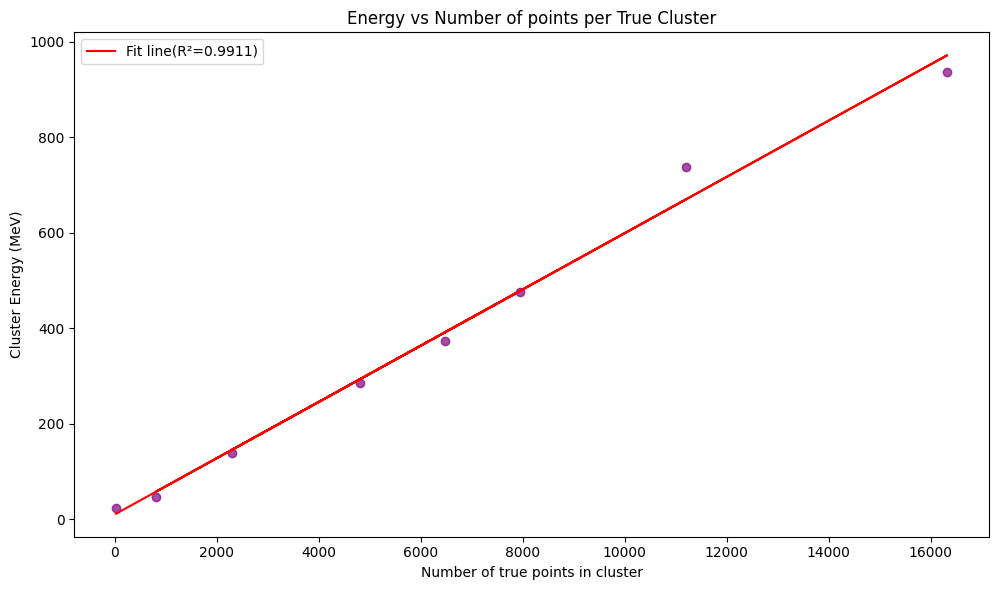

In [29]:
# Draw above true energies and number of points for each cluster in a 2D scatter plot where x-axis is number of points, and y-axis is energy

plt.figure(figsize=(10, 6))
plt.scatter(number_of_points_in_cluster, sum_e_trues, color='purple', alpha=
0.7)
plt.xlabel('Number of true points in cluster')
plt.ylabel('Cluster Energy (MeV)')
plt.title('Energy vs Number of points per True Cluster')
#plt.xscale('log')
#plt.yscale('log')
plt.tight_layout()

# fit it with a line
# fit it with a line using numpy.polyfit instead of scipy.stats
slope, intercept = np.polyfit(number_of_points_in_cluster, sum_e_trues, 1)
predicted = intercept + slope * np.array(number_of_points_in_cluster)
residuals = np.array(sum_e_trues) - predicted
ss_res = np.sum(residuals**2)
ss_tot = np.sum((np.array(sum_e_trues) - np.mean(sum_e_trues))**2)
r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R-squared: {r_squared:.4f}")
plt.plot(number_of_points_in_cluster, predicted, color='red', label=f'Fit line(R²={r_squared:.4f})')
plt.legend()



# plt.show(block=False)


In [20]:
# Now we do the same re-assignment of cluster IDs for the predicted points.

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:

    # re-assign cluster ID to be the average x-position
    import numpy as np

    # These were previously selected and stored
    predicted_5d_points = np.column_stack((x_pred, y_pred, z_pred, id_pred, q_pred))

    # Group points by ID and compute average x for each cluster
    clusters = {}
    for point in predicted_5d_points:
        cluster_id = point[3]  # Original cluster ID
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)

    # Compute new cluster IDs based on average x position
    new_points = []
    for cluster_id, points in clusters.items():
        points          = np.array(points)
        avg_x           = np.mean(points[:, 0] + points[:, 1])  # Compute average x-position
        # convert avg_x to nearest integer (since x is in cm, we can round to nearest cm)
        avg_x = round(avg_x)
        points[:, 3]    = avg_x  # Reassign cluster ID to avg_x
        new_points.append(points)

    # Flatten list into a NumPy array
    predicted_5d_points = np.vstack(new_points)

    print("After re-assinging, we have ", len(predicted_5d_points), " predicted points in ", len(clusters), " clusters.")

After re-assinging, we have  16188  predicted points in  9  clusters.


Cluster ID (avg x): -150.0  Number of points: 17
Cluster ID (avg x): -28.0  Number of points: 204
Cluster ID (avg x): 59.0  Number of points: 4942
Cluster ID (avg x): -74.0  Number of points: 1772
Cluster ID (avg x): -167.0  Number of points: 4715
Cluster ID (avg x): 148.0  Number of points: 1506
Cluster ID (avg x): -118.0  Number of points: 652
Cluster ID (avg x): -259.0  Number of points: 2333
Cluster ID (avg x): 66.0  Number of points: 47
We have  9  reco clusters


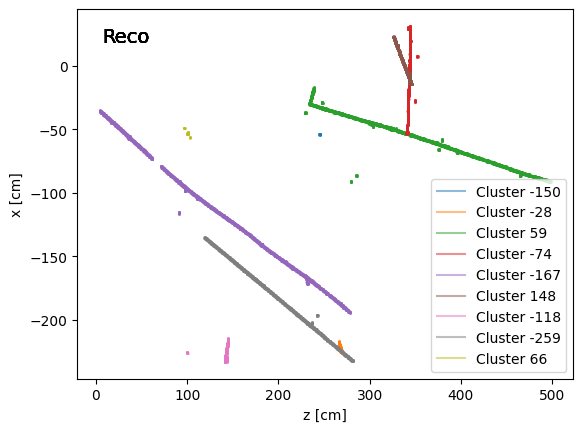

In [21]:
# Lets redraw reco clusters
# Give different color to each reco cluster

# Group points by ID and draw each reco cluster by a different color
clusters_reco = {}
for point in predicted_5d_points:   
    cluster_id = point[3]  # Original cluster ID
    if cluster_id not in clusters_reco:
        clusters_reco[cluster_id] = []
    clusters_reco[cluster_id].append(point)

new_points = []
for cluster_id, points in clusters_reco.items():
    print( "Cluster ID (avg x):", cluster_id, " Number of points:", len(points))
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]
    scatter = plt.scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    plt.plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    plt.text(0.05, 0.95, 'Reco', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top') 
    plt.legend()
    plt.xlabel("z [cm]")
    plt.ylabel("x [cm]")

print("We have ", len(clusters_reco), " reco clusters")

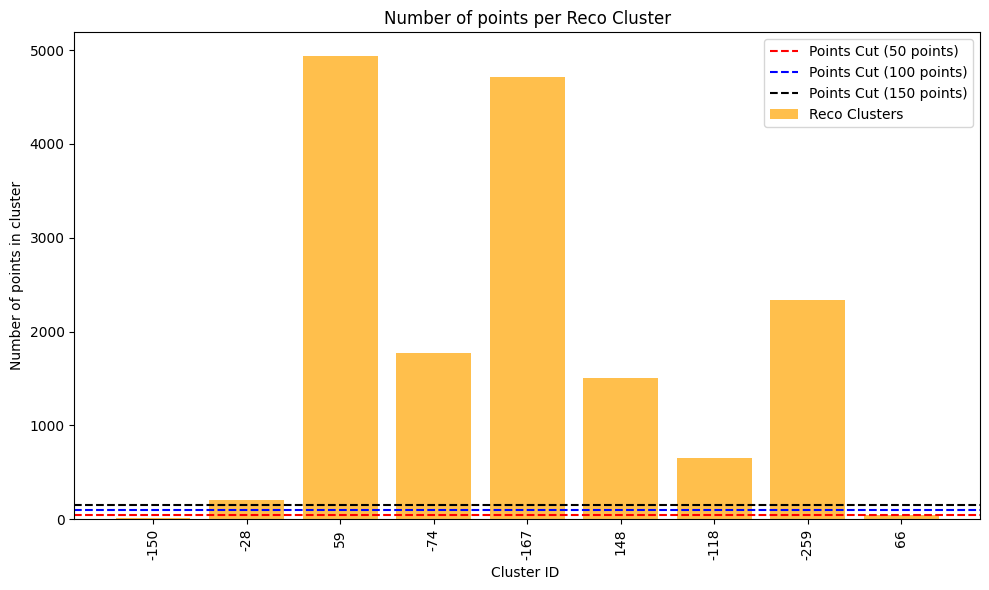

In [22]:
# Now lets draw number of points in each reco cluster

number_of_points_in_reco_cluster = []
cluster_ids_reco = []
cluster_ids_labels_reco = []
for cluster_id, points in clusters_reco.items():
    points = np.array(points)
    cluster_ids_reco.append(cluster_id)
    cluster_ids_labels_reco.append(f"{cluster_id:2.4g}")
    number_of_points_in_reco_cluster.append(len(points))

plt.figure(figsize=(10, 6))
plt.bar(cluster_ids_labels_reco, number_of_points_in_reco_cluster, color='orange', alpha=0.7, label='Reco Clusters')
plt.xlabel('Cluster ID ')
plt.ylabel('Number of points in cluster')
plt.title('Number of points per Reco Cluster')
plt.xticks(rotation=90)
plt.tight_layout()
#plt.yscale('log') 

# lets draw some lines
plt.axhline(y=50,   color='red',    linestyle='--', label='Points Cut (50 points)')
plt.axhline(y=100,  color='blue',   linestyle='--', label='Points Cut (100 points)')
plt.axhline(y=150,  color='black',  linestyle='--', label='Points Cut (150 points)')

plt.legend()
# plt.show(block=False)

Cluster ID (avg x): -150.0  Number of points: 17
Cluster ID (avg x): -28.0  Number of points: 204
Cluster ID (avg x): 59.0  Number of points: 4942
Cluster ID (avg x): -74.0  Number of points: 1772
Cluster ID (avg x): -167.0  Number of points: 4715
Cluster ID (avg x): 148.0  Number of points: 1506
Cluster ID (avg x): -118.0  Number of points: 652
Cluster ID (avg x): -259.0  Number of points: 2333
Cluster ID (avg x): 66.0  Number of points: 47


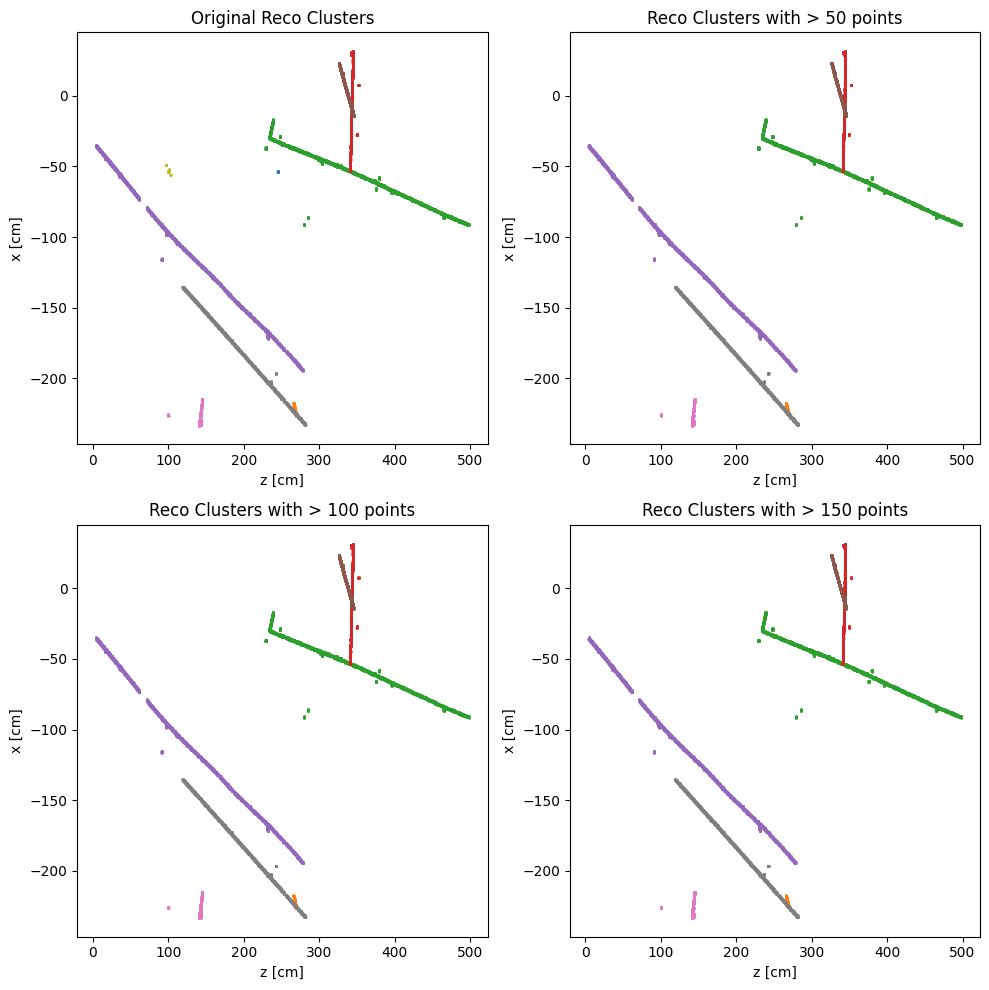

In [23]:
# lets draw side by side reco clusters for 4 cases, original, and with cuts of 50, 100, 150 points
# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))  # 2 row, 2 columns
# Original plot (top left)
for cluster_id, points in clusters_reco.items():
    print( "Cluster ID (avg x):", cluster_id, " Number of points:", len(points))
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]
    scatter_00 = axes[0, 0].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
    color = scatter_00.get_facecolor()[0]
    axes[0, 0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')

    # only above 50 points (top right)
    scatter_01 = axes[0, 1].scatter(reco_z_cluster[len(points) > 50], reco_x_cluster[len(points) > 50], s=1, alpha=0.5)
    color = scatter_01.get_facecolor()[0]
    axes[0, 1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    
    # only above 100 points (bottom left)
    scatter_10 = axes[1, 0].scatter(reco_z_cluster[len(points) > 100], reco_x_cluster[len(points) > 100], s=1, alpha=0.5)
    color = scatter_10.get_facecolor()[0]
    axes[1, 0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')

    # only above 150 points (bottom right)
    scatter_11 = axes[1, 1].scatter(reco_z_cluster[len(points) > 150], reco_x_cluster[len(points) > 150], s=1, alpha=0.5)
    color = scatter_11.get_facecolor()[0]
    axes[1, 1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')


axes[0, 0].set_title('Original Reco Clusters')
axes[0, 1].set_title('Reco Clusters with > 50 points')
axes[1, 0].set_title('Reco Clusters with > 100 points')
axes[1, 1].set_title('Reco Clusters with > 150 points')
axes[0, 0].set_xlabel("z [cm]")
axes[0, 0].set_ylabel("x [cm]")
axes[0, 1].set_xlabel("z [cm]")
axes[0, 1].set_ylabel("x [cm]")
axes[1, 0].set_xlabel("z [cm]")
axes[1, 0].set_ylabel("x [cm]")
axes[1, 1].set_xlabel("z [cm]")
axes[1, 1].set_ylabel("x [cm]")
# Apply cuts and plot
# Adjust layout and show plot
plt.tight_layout()
# plt.show(block=False)


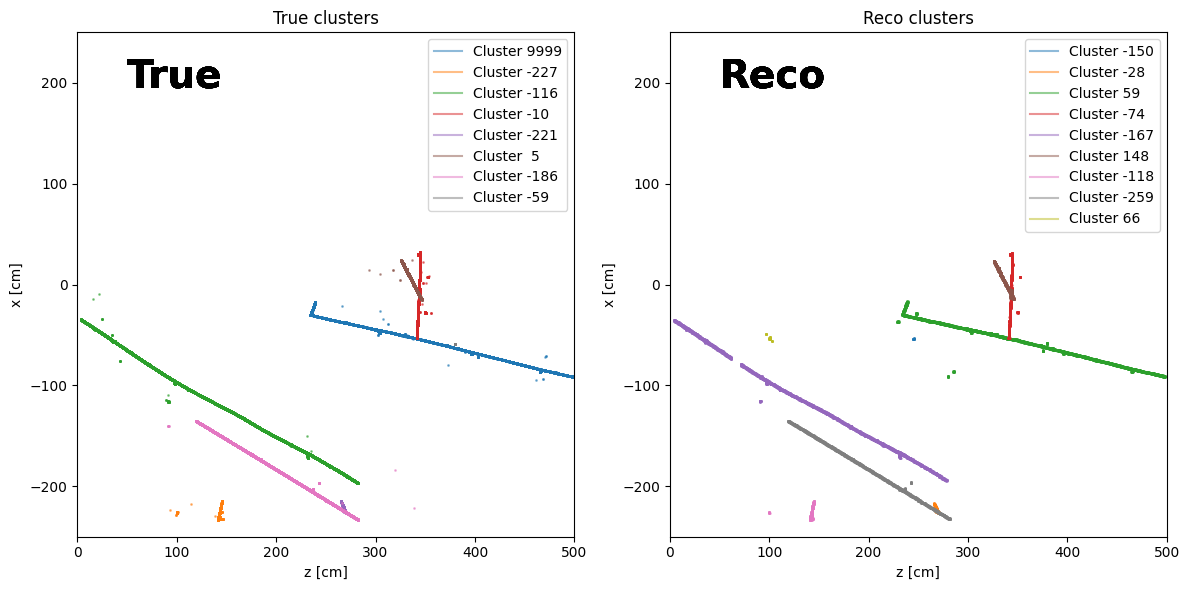

In [24]:
# Lets draw the true and the reco clusters together in the same plot to visually compare them. We will use different colors for true and reco clusters.
# Draw true and reco clusters together
# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
# First scatter plot (left)
axes[0].set_xlim(0, 500)  # Set x-axis range
axes[0].set_ylim(-250, 250)  # Set y-axis range
axes[0].set_xlabel("z [cm]")
axes[0].set_ylabel("x [cm]")
axes[0].set_title("True clusters")
# Draw true clusters in the first subplot
for cluster_id, points in clusters_true.items():
    points = np.array(points)
    true_x_cluster = points[:, 0]
    true_z_cluster = points[:, 2]
    scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[0].text(0.10, 0.95, "True", transform=axes[0].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
axes[0].legend()
# Second scatter plot (right)
axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
axes[1].set_xlabel("z [cm]")
axes[1].set_ylabel("x [cm]")
axes[1].set_title("Reco clusters")
# Draw reco clusters in the second subplot
for cluster_id, points in clusters_reco.items():
    points = np.array(points)
    reco_x_cluster = points[:, 0]
    reco_z_cluster = points[:, 2]
    scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
    color = scatter.get_facecolor()[0]
    axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
    axes[1].text(0.10, 0.95, "Reco", transform=axes[1].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
axes[1].legend()
# Adjust layout and show plot
plt.tight_layout()
# plt.show(block=False)


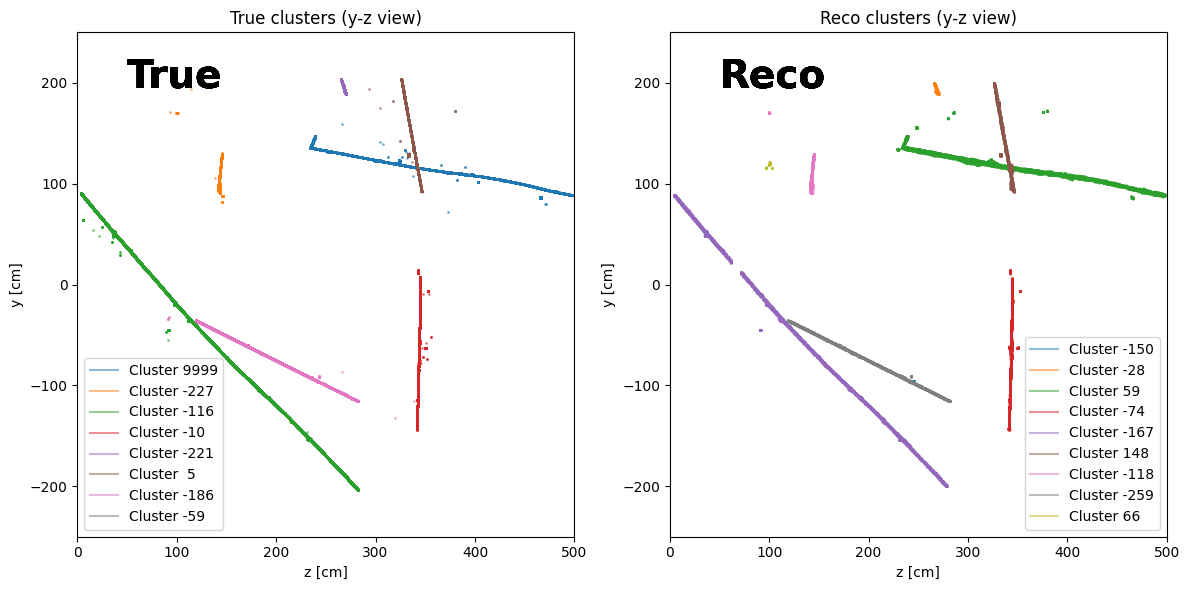

In [25]:
# Draw y-z view

# decide whether to draw y-z or not
draw_yz = True

if draw_yz:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns
    # First scatter plot (left)
    axes[0].set_xlim(0, 500)  # Set x-axis range
    axes[0].set_ylim(-250, 250)  # Set y-axis range
    axes[0].set_xlabel("z [cm]")
    axes[0].set_ylabel("y [cm]")
    axes[0].set_title("True clusters (y-z view)")
    # Draw true clusters in the first subplot
    for cluster_id, points in clusters_true.items():
        points = np.array(points)
        true_x_cluster = points[:, 1]
        true_z_cluster = points[:, 2]
        scatter = axes[0].scatter(true_z_cluster, true_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[0].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
        axes[0].text(0.10, 0.95, "True", transform=axes[0].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
    axes[0].legend()
    # Second scatter plot (right)
    axes[1].set_xlim(axes[0].get_xlim())  # Set x-axis range
    axes[1].set_ylim(axes[0].get_ylim())  # Set y-axis range
    axes[1].set_xlabel("z [cm]")
    axes[1].set_ylabel("y [cm]")
    axes[1].set_title("Reco clusters (y-z view)")
    # Draw reco clusters in the second subplot
    for cluster_id, points in clusters_reco.items():
        points = np.array(points)
        reco_x_cluster = points[:, 1]
        reco_z_cluster = points[:, 2]
        scatter = axes[1].scatter(reco_z_cluster, reco_x_cluster, s=1, alpha=0.5)
        color = scatter.get_facecolor()[0]
        axes[1].plot([], [], color=color, label=f'Cluster {cluster_id:2.4g}')
        axes[1].text(0.10, 0.95, "Reco", transform=axes[1].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')

    axes[1].legend()
    # Adjust layout and show plot
    plt.tight_layout()
    # plt.show(block=False)
else:
    print("We are not drawing y-z view")


In [26]:
# Lets print some true and predicted charges for each cluster to see how they compare
# Print true and predicted charges for each cluster
print("True and predicted charges for each cluster:")
for cluster_id in clusters_true.keys():
    true_points = np.array(clusters_true[cluster_id])
    true_charge = np.sum(true_points[:, 4])  # q_true is at index 4
    print(f"True Cluster {cluster_id:2.4g}: Total Charge = {true_charge:.2f} nelectrons")

for cluster_id in clusters_reco.keys():
    reco_points = np.array(clusters_reco[cluster_id])
    reco_charge = np.sum(reco_points[:, 4])  # q_pred is at index 4
    print(f"Reco Cluster {cluster_id:2.4g}: Total Charge = {reco_charge:.2f} units")


# lets debug by printing some of the charge values for some particular cluster IDs in true clusters
print("Charge values for some particular true cluster IDs:")
for cluster_id in list(clusters_true.keys())[:5]:  # Just print for the first 5 clusters
    true_points = np.array(clusters_true[cluster_id])
    charges = true_points[:, 4]  # q_true is at index 4
    print(f"True Cluster {cluster_id:2.4g}: Charges = {charges[:10]} ...")  # Print first 10 charge values for this cluster



True and predicted charges for each cluster:
True Cluster 9999: Total Charge = 11190.00 nelectrons
True Cluster -227: Total Charge = 0.00 nelectrons
True Cluster -116: Total Charge = 0.00 nelectrons
True Cluster -10: Total Charge = 0.00 nelectrons
True Cluster -221: Total Charge = 0.00 nelectrons
True Cluster  5: Total Charge = 0.00 nelectrons
True Cluster -186: Total Charge = 0.00 nelectrons
True Cluster -59: Total Charge = 0.00 nelectrons
Reco Cluster -150: Total Charge = 17994.31 units
Reco Cluster -28: Total Charge = 264555.88 units
Reco Cluster 59: Total Charge = 14605033.17 units
Reco Cluster -74: Total Charge = 2327174.35 units
Reco Cluster -167: Total Charge = 6073735.61 units
Reco Cluster 148: Total Charge = 3616877.10 units
Reco Cluster -118: Total Charge = 2401259.83 units
Reco Cluster -259: Total Charge = 2712845.10 units
Reco Cluster 66: Total Charge = 36385.83 units
Charge values for some particular true cluster IDs:
True Cluster 9999: Charges = [1. 1. 1. 1. 1. 1. 1. 1. 1

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


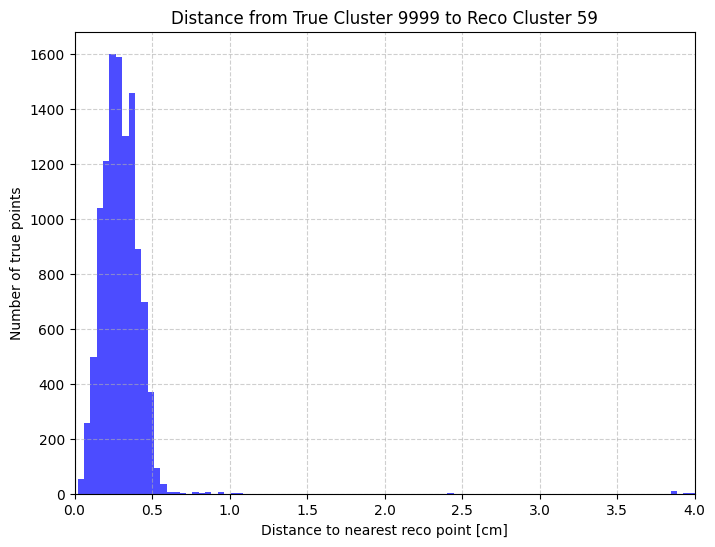

Total number of true points in this cluster: 11190
Number of true points having a nearest reco point within 0.5 cm: 10909 = 97.49% of the true points in this cluster
Number of true points having a nearest reco point within 1.0 cm: 11140 = 99.55% of the true points in this cluster
Number of true points having a nearest reco point within 2.0 cm: 11144 = 99.59% of the true points in this cluster


In [27]:
# Lets find the distance between each predicted cluster and the true clusters to see how well they match. We can compute the distance between the average x and z positions of the predicted cluster and the true clusters, and find the closest true cluster for each predicted cluster.

# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)
# Query the KDTree with the true points to find nearest neighbors
distances, indices = reco_tree.query(true_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=1000, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest reco point [cm]")
plt.ylabel("Number of true points")
plt.title(f"Distance from True Cluster {true_cluster_id:2.4g} to Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

print("Total number of true points in this cluster:", len(indices))

# lets counts how many true points are within the knn_dist_threshold of the predicted cluster
num_matched_points = np.sum(distances <= 0.5*knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {0.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")
num_matched_points = np.sum(distances <= knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")
num_matched_points = np.sum(distances <= 2*knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")



Testing KDTree matching for True Cluster -116 and Reco Cluster -167


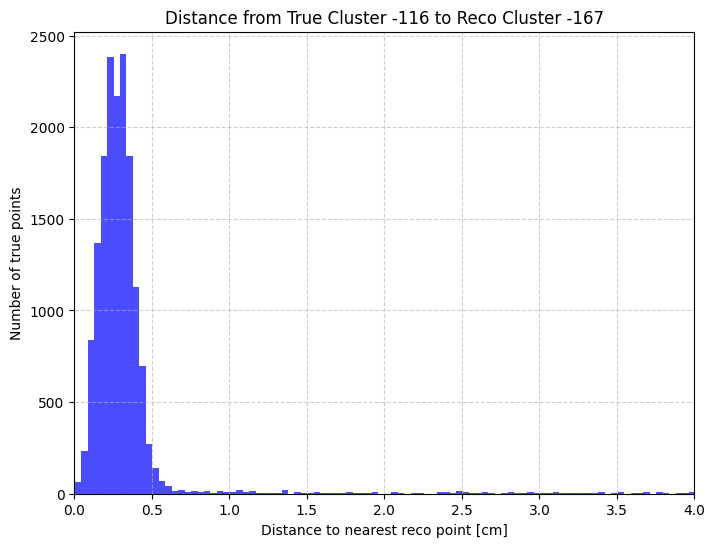

Total number of true points in this cluster: 16321
Number of true points having a nearest reco point within 0.5 cm: 15236 = 93.35% of the true points in this cluster
Number of true points having a nearest reco point within 1.0 cm: 15597 = 95.56% of the true points in this cluster
Number of true points having a nearest reco point within 2.0 cm: 15779 = 96.68% of the true points in this cluster


In [28]:
# Another example to draw distance between two nearby clusters

# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[2]
reco_cluster_id = list(clusters_reco.keys())[4]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)
# Query the KDTree with the true points to find nearest neighbors
distances, indices = reco_tree.query(true_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=1000, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest reco point [cm]")
plt.ylabel("Number of true points")
plt.title(f"Distance from True Cluster {true_cluster_id:2.4g} to Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

print("Total number of true points in this cluster:", len(indices))

# lets counts how many true points are within the knn_dist_threshold of the predicted cluster
num_matched_points = np.sum(distances <= 0.5*knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {0.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")
num_matched_points = np.sum(distances <= knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")
num_matched_points = np.sum(distances <= 2*knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")

total true points: 49860 , with shape: (49860, 3)
total reco points: 16188 , with shape: (16188, 3)


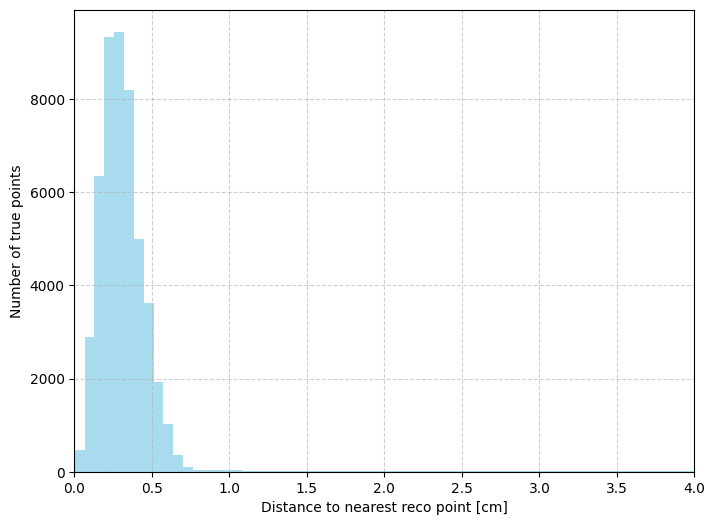

Number of true points having a nearest reco point within 0.5 cm: 44825 = 89.90% of the true points in this cluster
Number of true points having a nearest reco point within 1.0 cm: 48817 = 97.91% of the true points in this cluster
Number of true points having a nearest reco point within 2.0 cm: 49080 = 98.44% of the true points in this cluster


In [29]:
# Now lets draw distances for all true points to their nearest reco points.

all_true_coords = true_5d_points[:, :3]
all_reco_coords = predicted_5d_points[:, :3]

print("total true points:", len(all_true_coords), ", with shape:", all_true_coords.shape)
print("total reco points:", len(all_reco_coords), ", with shape:", all_reco_coords.shape)

reco_tree = KDTree(all_reco_coords)
# Query the KDTree with the true points to find nearest neighbors
distances, indices = reco_tree.query(all_true_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=1000, color='skyblue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest reco point [cm]")
plt.ylabel("Number of true points")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

# lets counts how many true points are within the knn_dist_threshold of the predicted cluster
num_matched_points = np.sum(distances <= 0.5*knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {0.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")
num_matched_points = np.sum(distances <= knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")
num_matched_points = np.sum(distances <= 2*knn_dist_threshold)
print(f"Number of true points having a nearest reco point within {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the true points in this cluster")

In [30]:
#--------------------------------------
# match prediction to true using KDTree query
#--------------------------------------
# Compare predicted clusters to true clusters using KDTree query
# Do it pair wise for each predicted cluster and each true cluster, and compute the distance between them
# Find if any true point in the true cluster is within knn_dist_threshold of any predicted point in the predicted cluster
# If yes, then we consider that predicted cluster to be matched to that true cluster
# Then we compute the efficiency
# Efficiency is defined as the number of true points that are matched to a predicted cluster divided by the total number of true points in that cluster
# 
# Lets test it only for one predicted cluster and one true cluster first to see if it works, before we do it for all clusters
# for true cluster with avg x = -116, and predicted cluster with avg x = -114, we want to see if any true point in the true cluster is within knn_dist_threshold of any predicted point in the predicted cluster

# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    from scipy.spatial import KDTree

    # Select one true cluster and one predicted cluster for testing
    true_cluster_id = list(clusters_true.keys())[0]
    reco_cluster_id = list(clusters_reco.keys())[2]
    print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
    true_points = np.array(clusters_true[true_cluster_id])
    reco_points = np.array(clusters_reco[reco_cluster_id])
    true_coords = true_points[:, :3]
    reco_coords = reco_points[:, :3]
    # Build KDTree for the predicted cluster
    reco_tree = KDTree(reco_coords)
    # Query the KDTree with the true points to find nearest neighbors
    distances, indices = reco_tree.query(true_coords)
    # Check how many true points are within the knn_dist_threshold of any predicted point
    matched_true_points = np.sum(distances <= knn_dist_threshold)
    total_true_points = len(true_points)
    efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    print(f"Matched True Points: {matched_true_points} / {total_true_points}, Efficiency: {efficiency:.2f}")
    

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59
Matched True Points: 11140 / 11190, Efficiency: 1.00


In [31]:
# find efficiency for another pair of clusters

# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[3]
reco_cluster_id = list(clusters_reco.keys())[3]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)
# Query the KDTree with the true points to find nearest neighbors
distances, indices = reco_tree.query(true_coords)
# Check how many true points are within the knn_dist_threshold of any predicted point
matched_true_points = np.sum(distances <= knn_dist_threshold)
total_true_points = len(true_points)
efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
print(f"Matched True Points: {matched_true_points} / {total_true_points}, Efficiency: {efficiency:.2f}")
    

Testing KDTree matching for True Cluster -10 and Reco Cluster -74
Matched True Points: 6466 / 6483, Efficiency: 1.00


True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 11140 / 11190, Efficiency = 1.00
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -22

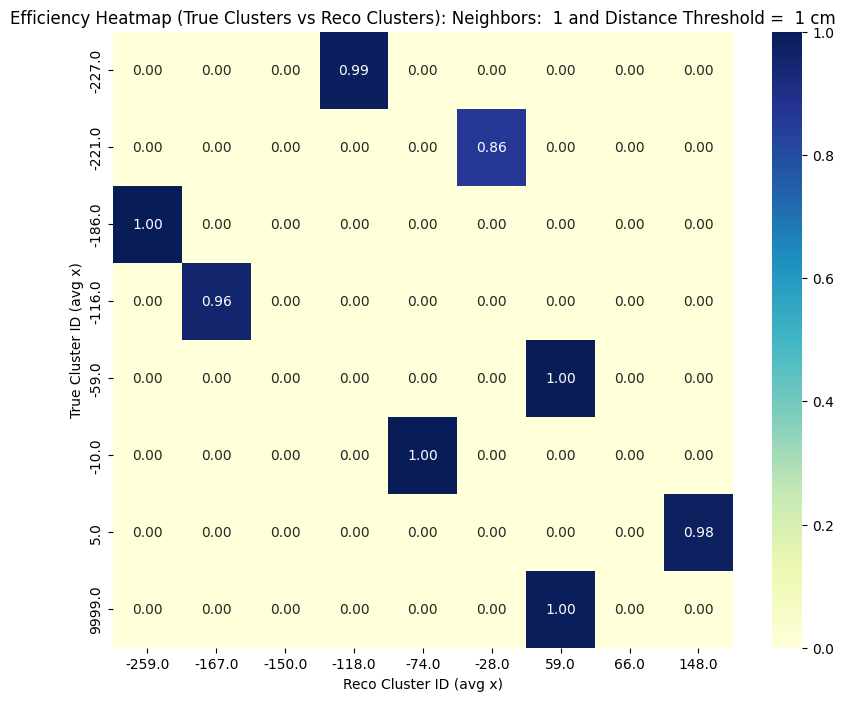

In [32]:
# Above part works, now we can do it for all clusters and find the best matching predicted cluster for each true cluster based on efficiency
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    from scipy.spatial import KDTree

neighborhood_size = 1 # We can also try with k=5 or k=10 to see if it improves the matching, but for now we will keep it at 1 for simplicity

# Create a list to store efficiency results for each true cluster
efficiency_results = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        distances, indices = reco_tree.query(true_coords, k=neighborhood_size)
        # Check how many true points are within the knn_dist_threshold of any predicted point
        matched_true_points = np.sum(distances <= knn_dist_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Efficiency Heatmap (True Clusters vs Reco Clusters): Neighborhood Size = 1")
plt.title(f"Efficiency Heatmap (True Clusters vs Reco Clusters): Neighbors: {neighborhood_size:2.4g} and Distance Threshold = {knn_dist_threshold:2.4g} cm")
plt.xlabel("Reco Cluster ID (avg x)")
plt.ylabel("True Cluster ID (avg x)")
# plt.show(block=False)




reco_cluster_id    -259.0   -167.0  -150.0    -118.0    -74.0     -28.0   \
true_cluster_id                                                            
-227.0           0.000000  0.00000     0.0  0.986751  0.000000  0.000000   
-221.0           0.000000  0.00000     0.0  0.000000  0.000000  0.857855   
-186.0           0.998299  0.00000     0.0  0.000000  0.000000  0.000000   
-116.0           0.000000  0.95515     0.0  0.000000  0.000000  0.000000   
-59.0            0.000000  0.00000     0.0  0.000000  0.000000  0.000000   
-10.0            0.000000  0.00000     0.0  0.000000  0.996992  0.000000   
 5.0             0.000000  0.00000     0.0  0.000000  0.000000  0.000000   
 9999.0          0.000000  0.00000     0.0  0.000000  0.000000  0.000000   

reco_cluster_id     59.0    66.0      148.0  
true_cluster_id                              
-227.0           0.000000     0.0  0.000000  
-221.0           0.000000     0.0  0.000000  
-186.0           0.000000     0.0  0.000000  
-116.0   

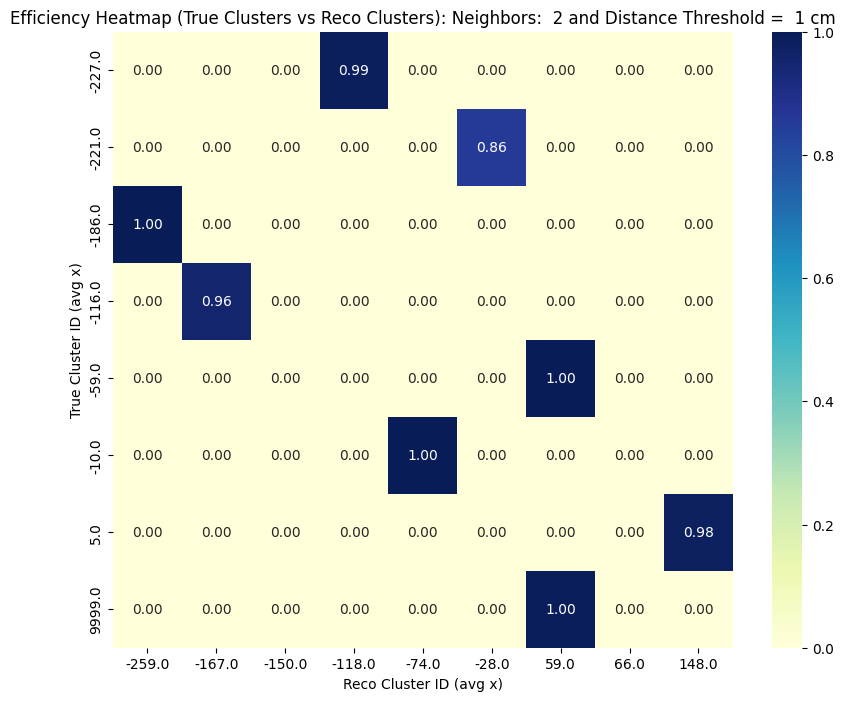

In [33]:
# For 2 nearest point
# Re-calculate efficiency but this instead of finding one nearest neighbor,
# we should find two nearest neighbours for each true point

# Above part works, now we can do it for all clusters and find the best matching predicted cluster for each true cluster based on efficiency
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    from scipy.spatial import KDTree

neighborhood_size = 2  # Number of nearest neighbors to consider

# Create a list to store efficiency results for each true cluster
efficiency_results = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        distances, indices = reco_tree.query(true_coords, k=neighborhood_size)  # Find 2 nearest neighbors
        # Check how many true points are within the knn_dist_threshold of any predicted point
        matched_true_points = np.sum(distances <= knn_dist_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
        efficiency = efficiency/neighborhood_size  # Normalize by neighborhood size to get a value between 0 and 1
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
# Print the efficiency results
#for result in efficiency_results:
    #print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
    #        f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
    #        f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap (True Clusters vs Reco Clusters): Neighbors: {neighborhood_size:2.4g} and Distance Threshold = {knn_dist_threshold:2.4g} cm")

plt.xlabel("Reco Cluster ID (avg x)")
plt.ylabel("True Cluster ID (avg x)")
# plt.show(block=False)

True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 110968 / 11190, Efficiency = 0.99
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -2

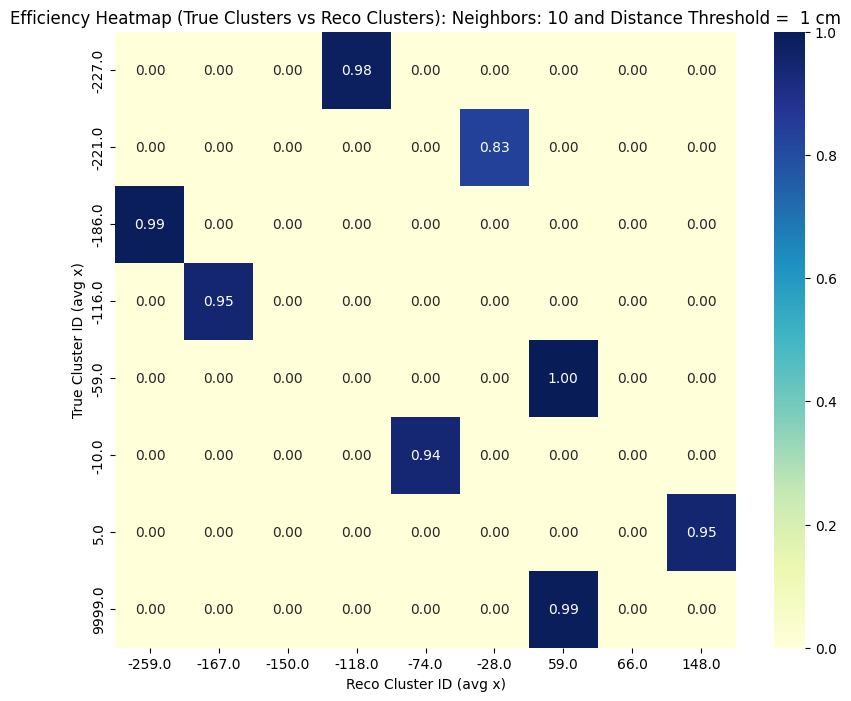

In [34]:
# Re-calculate efficiency but this instead of finding one nearest neighbor,
# we should find two nearest neighbours for each true point

# Above part works, now we can do it for all clusters and find the best matching predicted cluster for each true cluster based on efficiency
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    from scipy.spatial import KDTree

neighborhood_size = 10  # Number of nearest neighbors to consider

# Create a list to store efficiency results for each true cluster
efficiency_results = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        distances, indices = reco_tree.query(true_coords, k=neighborhood_size)  # Find 2 nearest neighbors
        # Check how many true points are within the knn_dist_threshold of any predicted point
        matched_true_points = np.sum(distances <= knn_dist_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
        efficiency = efficiency/neighborhood_size  # Normalize by neighborhood size to get a value between 0 and 1
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap (True Clusters vs Reco Clusters): Neighbors: {neighborhood_size:2.4g} and Distance Threshold = {knn_dist_threshold:2.4g} cm")

plt.xlabel("Reco Cluster ID (avg x)")
plt.ylabel("True Cluster ID (avg x)")
# plt.show(block=False)

Testing Number of nearest neighbors for True Cluster 9999 and Reco Cluster 59
Radius: 0.5 cm, Number of true points with zero neighbors: 281 = 2.51% of the true points in this cluster
Radius: 0.5 cm, Number of true points with less than 5 neighbors: 10943 = 97.79% of the true points in this cluster
Radius: 1.0 cm, Number of true points with zero neighbors: 50 = 0.45% of the true points in this cluster
Radius: 1.0 cm, Number of true points with less than 5 neighbors: 71 = 0.63% of the true points in this cluster
Radius: 1.5 cm, Number of true points with zero neighbors: 46 = 0.41% of the true points in this cluster
Radius: 1.5 cm, Number of true points with less than 5 neighbors: 46 = 0.41% of the true points in this cluster
Radius: 2.0 cm, Number of true points with zero neighbors: 46 = 0.41% of the true points in this cluster
Radius: 2.0 cm, Number of true points with less than 5 neighbors: 46 = 0.41% of the true points in this cluster


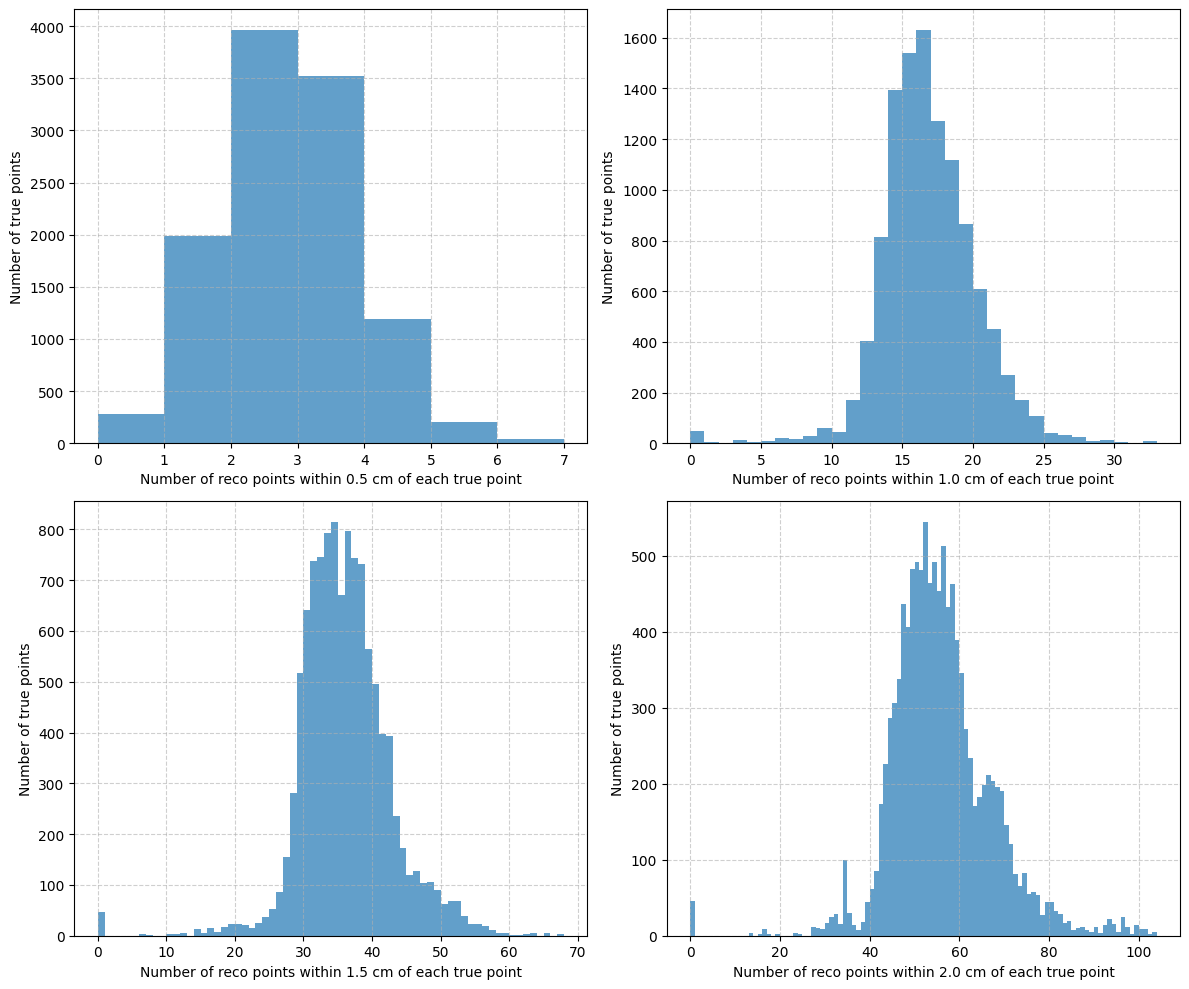

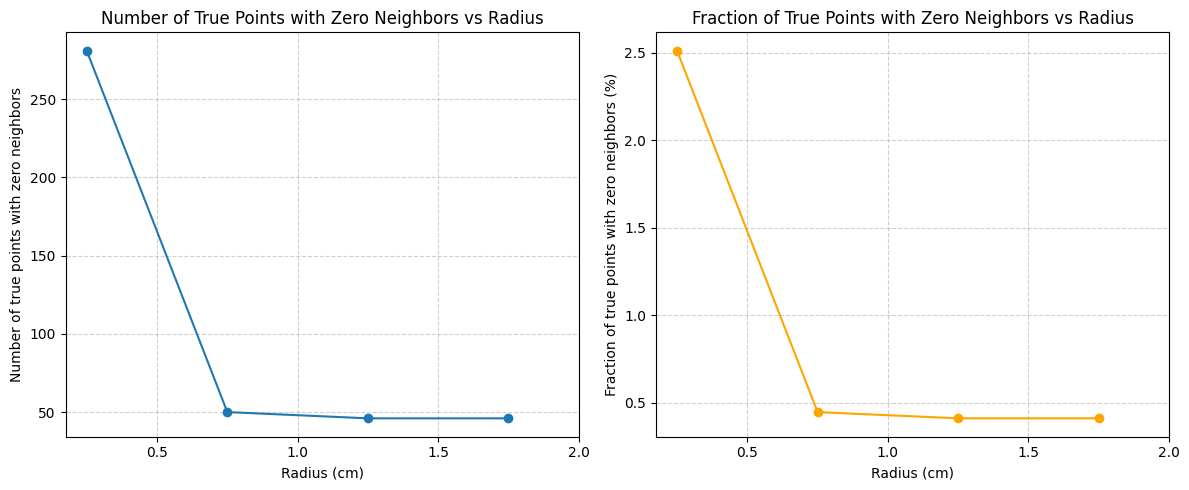

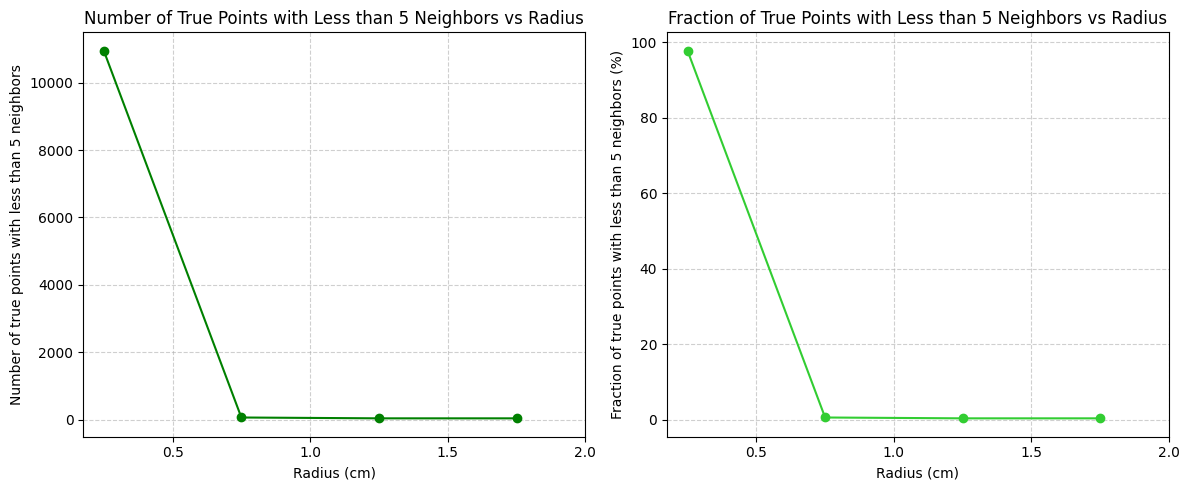

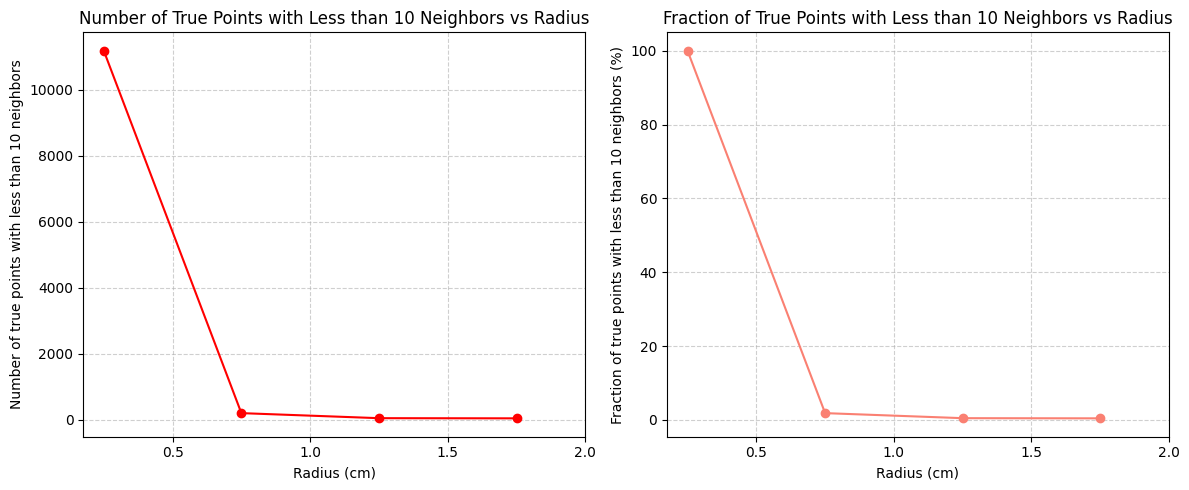

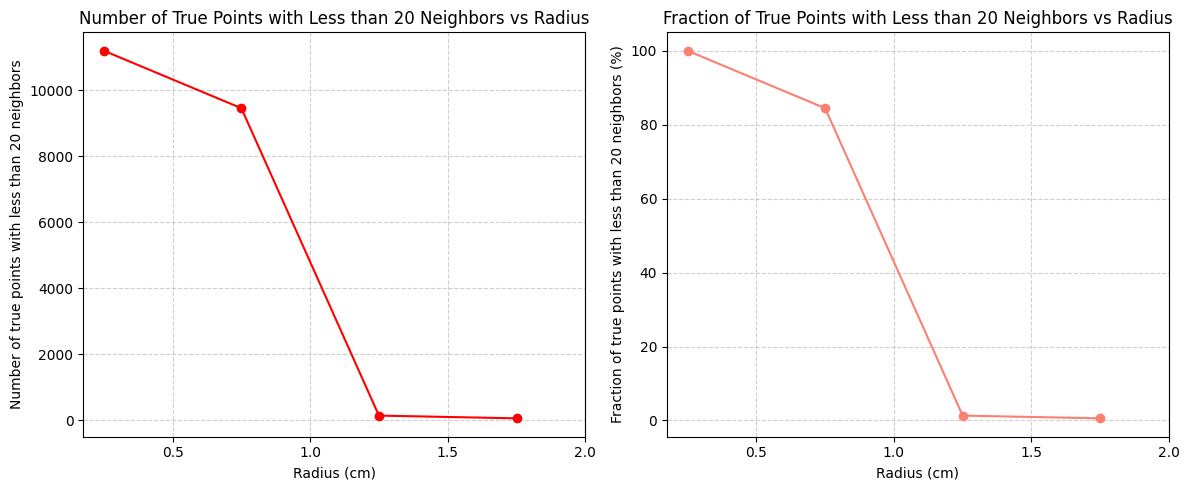

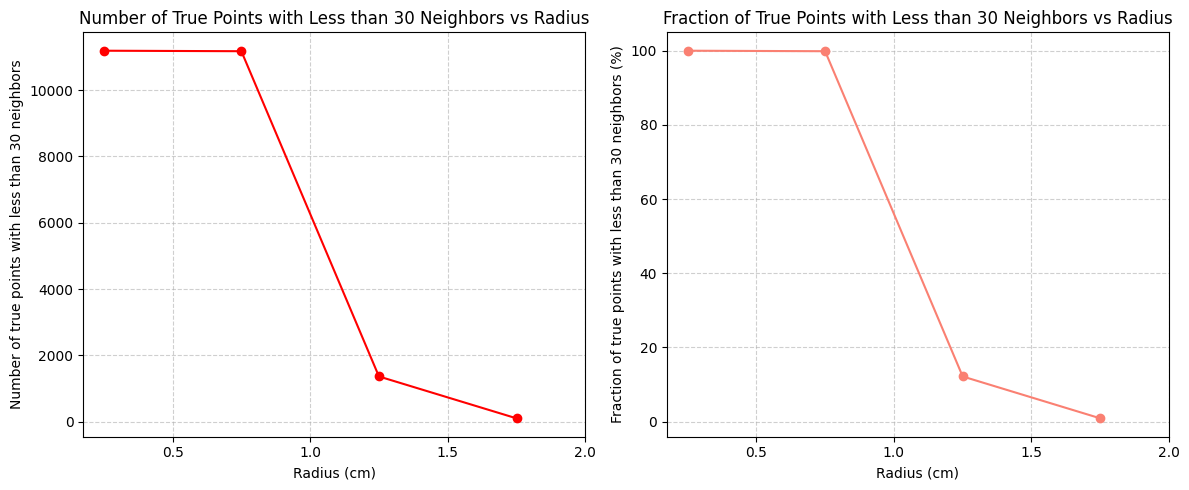

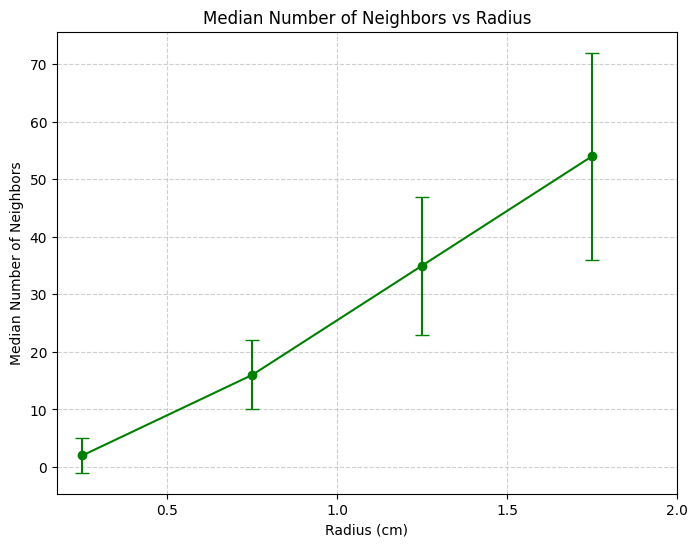

Radius: 0.5 cm, Median Number of Neighbors: 2.0, Uncertainty: 3
Radius: 1.0 cm, Median Number of Neighbors: 16.0, Uncertainty: 6
Radius: 1.5 cm, Median Number of Neighbors: 35.0, Uncertainty: 12
Radius: 2.0 cm, Median Number of Neighbors: 54.0, Uncertainty: 18


In [35]:
# Make a distributions of how many reco points exist within knn_dist_threshold of each true point, for all true points in all clusters.
# lets first do this for one good looking true and reco cluster pair
# Select one true cluster and one predicted cluster for testing
# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing Number of nearest neighbors for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# Now lets remake this for several values of radius and see how the distribution changes
radii = [0.5, 1.0, 1.5, 2.0]
num_zero_neighbors = []
num_zero_neighbors_fraction = []

num_less_than_5_neighbors = []
num_less_than_5_neighbors_fraction = []

num_less_than_10_neighbors = []
num_less_than_10_neighbors_fraction = []

num_less_than_20_neighbors = []
num_less_than_20_neighbors_fraction = []

num_less_than_30_neighbors = []
num_less_than_30_neighbors_fraction = []

median_num_neighbors = []
uncertainty_num_neighbors = []
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns

for radius in radii:
    indices = reco_tree.query_ball_point(true_coords, r=radius)  # Find all neighbors within radius
    # Count the number of neighbors for each true point
    num_neighbors = [len(neighbors) for neighbors in indices]

    # how many true points have zero neighbors within this radius?
    num_zero = np.sum(np.array(num_neighbors) == 0)
    num_zero_neighbors.append(num_zero)
    num_zero_neighbors_fraction.append(num_zero/len(num_neighbors)*100)

    print(f"Radius: {radius} cm, Number of true points with zero neighbors: {num_zero} = {num_zero/len(num_neighbors)*100:.2f}% of the true points in this cluster")

    # lets count how many true points have less than 5 neighbors within this radius?
    num_less_than_5_neighbors.append(np.sum(np.array(num_neighbors) < 5))
    num_less_than_5_neighbors_fraction.append(np.sum(np.array(num_neighbors) < 5)/len(num_neighbors)*100)
    print(f"Radius: {radius} cm, Number of true points with less than 5 neighbors: {num_less_than_5_neighbors[-1]} = {num_less_than_5_neighbors_fraction[-1]:.2f}% of the true points in this cluster")

    # lets count how many true points have less than 10 neighbors within this radius?
    num_less_than_10_neighbors.append(np.sum(np.array(num_neighbors) < 10))
    num_less_than_10_neighbors_fraction.append(np.sum(np.array(num_neighbors) < 10)/len(num_neighbors)*100)

    # for 20 neighbors
    num_less_than_20_neighbors.append(np.sum(np.array(num_neighbors) < 20))
    num_less_than_20_neighbors_fraction.append(np.sum(np.array(num_neighbors) < 20)/len(num_neighbors)*100)

    # for 30 neighbors
    num_less_than_30_neighbors.append(np.sum(np.array(num_neighbors) < 30))
    num_less_than_30_neighbors_fraction.append(np.sum(np.array(num_neighbors) < 30)/len(num_neighbors)*100)


    # get the median and the uncertainty (width at half maximum) of the distribution of number of neighbors
    median_num_neighbors.append(np.median(num_neighbors))
    counts, bin_edges = np.histogram(num_neighbors, bins=range(0, max(num_neighbors)+1))
    half_max = np.max(counts) / 2
    # Find the bin edges where the count is greater than or equal to half max
    above_half_max = np.where(counts >= half_max)[0]
    if len(above_half_max) > 0:
        lower_edge = bin_edges[above_half_max[0]]
        upper_edge = bin_edges[above_half_max[-1] + 1]
        uncertainty_num_neighbors.append(upper_edge - lower_edge)
    else:
        uncertainty_num_neighbors.append(0)

    # Plot the distribution of number of neighbors
    ax = axes[radii.index(radius) // 2, radii.index(radius) % 2]
    ax.hist(num_neighbors, bins=range(0, max(num_neighbors)+1), alpha=0.7)
    ax.set_xlabel(f"Number of reco points within {radius} cm of each true point")
    ax.set_ylabel("Number of true points")
    #ax.set_title(f"(True Cluster {true_cluster_id:2.4g} vs Reco Cluster {reco_cluster_id:2.4g})")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.plot([], [], color='blue', label=f'Radius: {radius} cm')

plt.tight_layout()
# plt.show(block=False)

radii_shifted = [v - 0.25 for v in radii] # shift the x values a bit for better visualization but there is no real meaning to this shift, its just for better visualization of the two curves in the next plot

# make a plot of number of zero neighbor true points vs radius and also the fraction of zero neighbor true points vs radius
# draw two subplots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(radii_shifted, num_zero_neighbors, marker='o')
plt.xlabel("Radius (cm)")
plt.ylabel("Number of true points with zero neighbors")
plt.xticks(radii)
plt.title(f"Number of True Points with Zero Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.plot(radii_shifted, num_zero_neighbors_fraction, marker='o', color='orange')
plt.xlabel("Radius (cm)")
plt.ylabel("Fraction of true points with zero neighbors (%)")
plt.xticks(radii)
plt.title(f"Fraction of True Points with Zero Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# lets make a plot of number of less than 5 neighbor true points vs radius and also the fraction of less than 5 neighbor true points vs radius
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(radii_shifted, num_less_than_5_neighbors, marker='o', color='green')
plt.xlabel("Radius (cm)")
plt.ylabel("Number of true points with less than 5 neighbors")
plt.xticks(radii)
plt.title(f"Number of True Points with Less than 5 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.plot(radii_shifted, num_less_than_5_neighbors_fraction, marker='o', color='limegreen')
plt.xlabel("Radius (cm)")
plt.ylabel("Fraction of true points with less than 5 neighbors (%)")
plt.xticks(radii)
plt.title(f"Fraction of True Points with Less than 5 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# make same plot for 10 neighbors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(radii_shifted, num_less_than_10_neighbors, marker='o', color='red')
plt.xlabel("Radius (cm)")
plt.ylabel("Number of true points with less than 10 neighbors")
plt.xticks(radii)
plt.title(f"Number of True Points with Less than 10 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.plot(radii_shifted, num_less_than_10_neighbors_fraction, marker='o', color='salmon')
plt.xlabel("Radius (cm)")
plt.ylabel("Fraction of true points with less than 10 neighbors (%)")
plt.xticks(radii)
plt.title(f"Fraction of True Points with Less than 10 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# for 20 neighbors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(radii_shifted, num_less_than_20_neighbors, marker='o', color='red')
plt.xlabel("Radius (cm)")
plt.ylabel("Number of true points with less than 20 neighbors")
plt.xticks(radii)
plt.title(f"Number of True Points with Less than 20 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.plot(radii_shifted, num_less_than_20_neighbors_fraction, marker='o', color='salmon')
plt.xlabel("Radius (cm)")
plt.ylabel("Fraction of true points with less than 20 neighbors (%)")
plt.xticks(radii)
plt.title(f"Fraction of True Points with Less than 20 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# for 20 neighbors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(radii_shifted, num_less_than_30_neighbors, marker='o', color='red')
plt.xlabel("Radius (cm)")
plt.ylabel("Number of true points with less than 30 neighbors")
plt.xticks(radii)
plt.title(f"Number of True Points with Less than 30 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.plot(radii_shifted, num_less_than_30_neighbors_fraction, marker='o', color='salmon')
plt.xlabel("Radius (cm)")
plt.ylabel("Fraction of true points with less than 30 neighbors (%)")
plt.xticks(radii)
plt.title(f"Fraction of True Points with Less than 30 Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# lets draw median and uncertainty of number of neighbors vs radius
plt.figure(figsize=(8, 6))
plt.errorbar(radii_shifted, median_num_neighbors, yerr=uncertainty_num_neighbors, marker='o', color='green', ecolor='green', capsize=5)
plt.xlabel("Radius (cm)")
plt.ylabel("Median Number of Neighbors")
plt.xticks(radii)
plt.title(f"Median Number of Neighbors vs Radius")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

# print median and uncertainty values
for i in range(len(radii)):
    print(f"Radius: {radii[i]} cm, Median Number of Neighbors: {median_num_neighbors[i]}, Uncertainty: {uncertainty_num_neighbors[i]}")



True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 10909 / 11190, Efficiency = 0.97
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -22

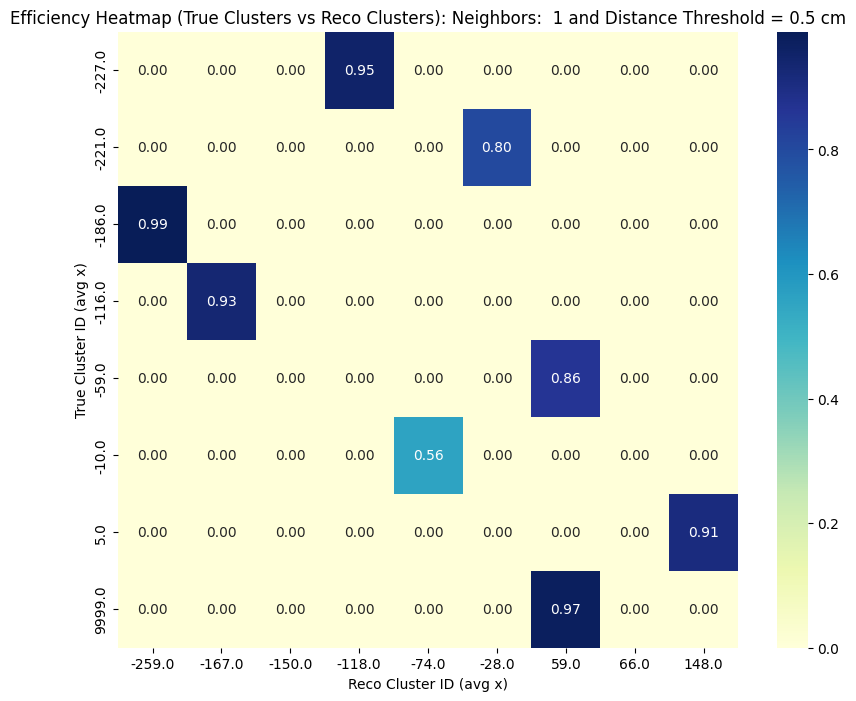

In [36]:
# Recalulate efficiency for one nearest neighbor but this time with a distance threshold of 0.5 cm instead of 1 cm, to see how it affects the efficiency values

# Above part works, now we can do it for all clusters and find the best matching predicted cluster for each true cluster based on efficiency
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    from scipy.spatial import KDTree

neighborhood_size = 1 # We can also try with k=5 or k=10 to see if it improves the matching, but for now we will keep it at 1 for simplicity
closest_distance = 0.5  # Distance threshold for matching

# Create a list to store efficiency results for each true cluster
efficiency_results = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        distances, indices = reco_tree.query(true_coords, k=neighborhood_size)
        # Check how many true points are within the knn_dist_threshold of any predicted point
        matched_true_points = np.sum(distances <= closest_distance)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap (True Clusters vs Reco Clusters): Neighbors: {neighborhood_size:2.4g} and Distance Threshold = {closest_distance:2.4g} cm")
plt.xlabel("Reco Cluster ID (avg x)")
plt.ylabel("True Cluster ID (avg x)")
# plt.show(block=False)

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59
Radius: 0.5 cm, Matched True Points: 10909 / 11190, Efficiency: 0.975
Radius: 1.0 cm, Matched True Points: 11140 / 11190, Efficiency: 0.996
Radius: 1.5 cm, Matched True Points: 11144 / 11190, Efficiency: 0.996
Radius: 2.0 cm, Matched True Points: 11144 / 11190, Efficiency: 0.996


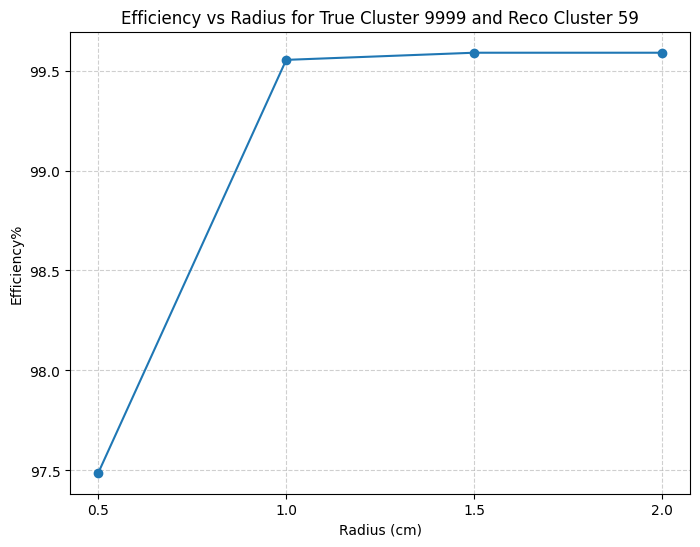

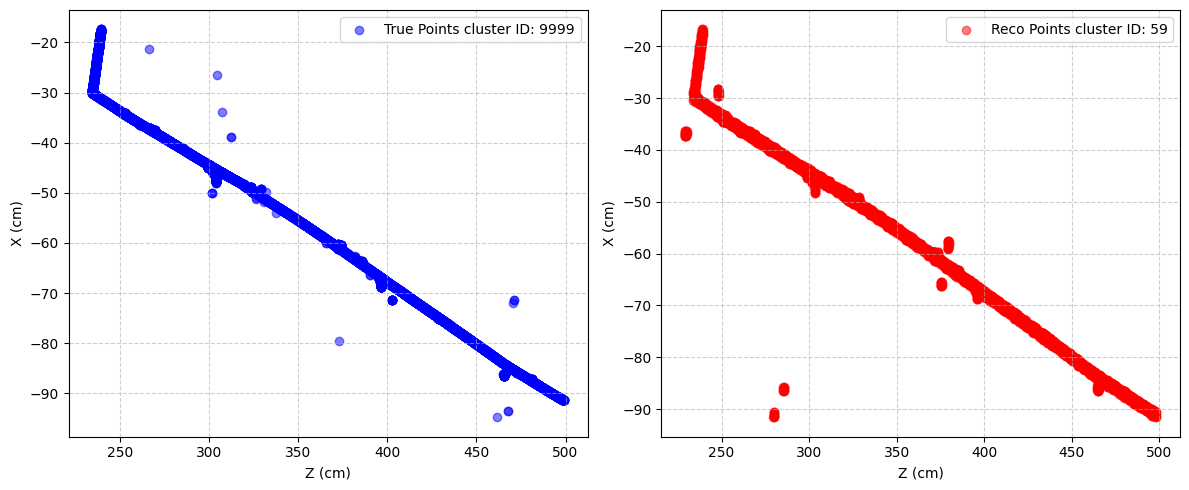

In [37]:
# Now calculate efficiency for an example cluster and make a plot of efficiency vs distance threshold for that cluster
# to see how efficiency changes with distance threshold for that cluster

radii = [0.5, 1.0, 1.5, 2.0]
efficiency_values = []
efficiency_percentages = []

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])

reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# loop over different radii and calculate efficiency for each radius
for radius in radii:

  # Query the KDTree with the true points to find nearest neighbors
  indices = reco_tree.query_ball_point(true_coords, r=radius)  # Find all neighbors within radius
  # Count the number of neighbors for each true point
  num_neighbors = [len(neighbors) for neighbors in indices]
  # Check how many true points are within the radius of any predicted point
  matched_true_points = np.sum(np.array(num_neighbors) > 0)
  total_true_points = len(true_points)
  efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
  efficiency_values.append(efficiency)
  efficiency_percentages = [eff*100 for eff in efficiency_values]  # convert to percentage
  print(f"Radius: {radius} cm, Matched True Points: {matched_true_points} / {total_true_points}, Efficiency: {efficiency:.3f}")

# Plot efficiency vs radius
plt.figure(figsize=(8, 6))
plt.plot(radii, efficiency_percentages, marker='o')
plt.xlabel("Radius (cm)")
plt.ylabel("Efficiency%")
plt.xticks(radii)
plt.title(f"Efficiency vs Radius for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

# also draw this true and reco side by side in x-z plane to see how they look like
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.scatter(reco_cluster[:, 2], reco_cluster[:, 0], color='red', alpha=0.5, label=f'Reco Points cluster ID: {reco_cluster_id:.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)



Testing KDTree matching for True Cluster -10 and Reco Cluster -74
Radius: 0.5 cm, Matched True Points: 3611 / 6483, Efficiency: 0.557
Radius: 1.0 cm, Matched True Points: 6466 / 6483, Efficiency: 0.997
Radius: 1.5 cm, Matched True Points: 6466 / 6483, Efficiency: 0.997
Radius: 2.0 cm, Matched True Points: 6466 / 6483, Efficiency: 0.997


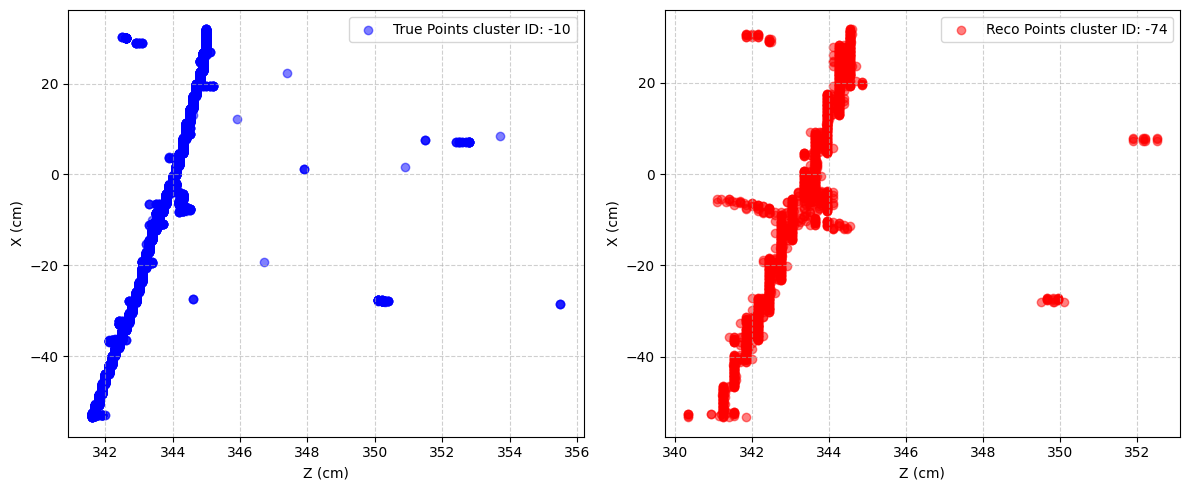

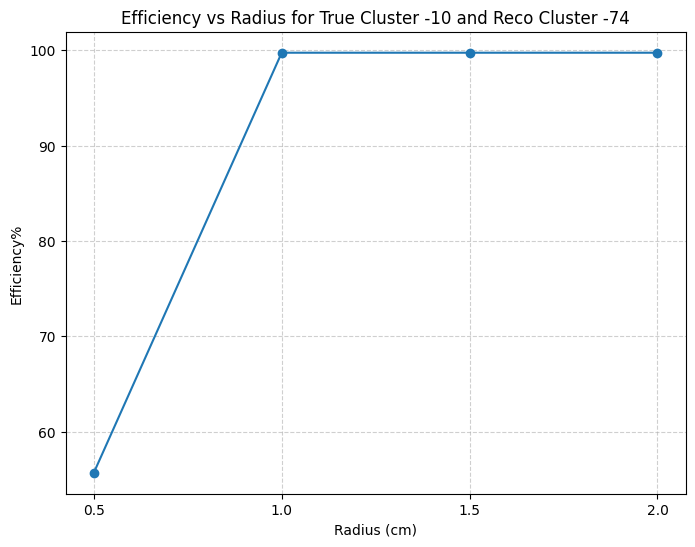

In [38]:
# lets do same thing above for another set of clusters
# Now calculate efficiency for an example cluster and make a plot of efficiency vs distance threshold for that cluster
# to see how efficiency changes with distance threshold for that cluster

radii = [0.5, 1.0, 1.5, 2.0]
efficiency_values = []
efficiency_percentages = []

true_cluster_id = list(clusters_true.keys())[3]
reco_cluster_id = list(clusters_reco.keys())[3]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# loop over different radii and calculate efficiency for each radius
for radius in radii:

  # Query the KDTree with the true points to find nearest neighbors
  indices = reco_tree.query_ball_point(true_coords, r=radius)  # Find all neighbors within radius
  # Count the number of neighbors for each true point
  num_neighbors = [len(neighbors) for neighbors in indices]
  # Check how many true points are within the radius of any predicted point
  matched_true_points = np.sum(np.array(num_neighbors) > 0)
  total_true_points = len(true_points)
  efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
  efficiency_values.append(efficiency)
  efficiency_percentages = [eff*100 for eff in efficiency_values]  # convert to percentage
  print(f"Radius: {radius} cm, Matched True Points: {matched_true_points} / {total_true_points}, Efficiency: {efficiency:.3f}")

# also draw this true and reco side by side in x-z plane to see how they look like
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.scatter(reco_cluster[:, 2], reco_cluster[:, 0], color='red', alpha=0.5, label=f'Reco Points cluster ID: {reco_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# Plot efficiency vs radius
plt.figure(figsize=(8, 6))
plt.plot(radii, efficiency_percentages, marker='o')
plt.xlabel("Radius (cm)")
plt.ylabel("Efficiency%")
plt.xticks(radii)
plt.title(f"Efficiency vs Radius for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 11140 / 11190, Efficiency = 1.00
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -22

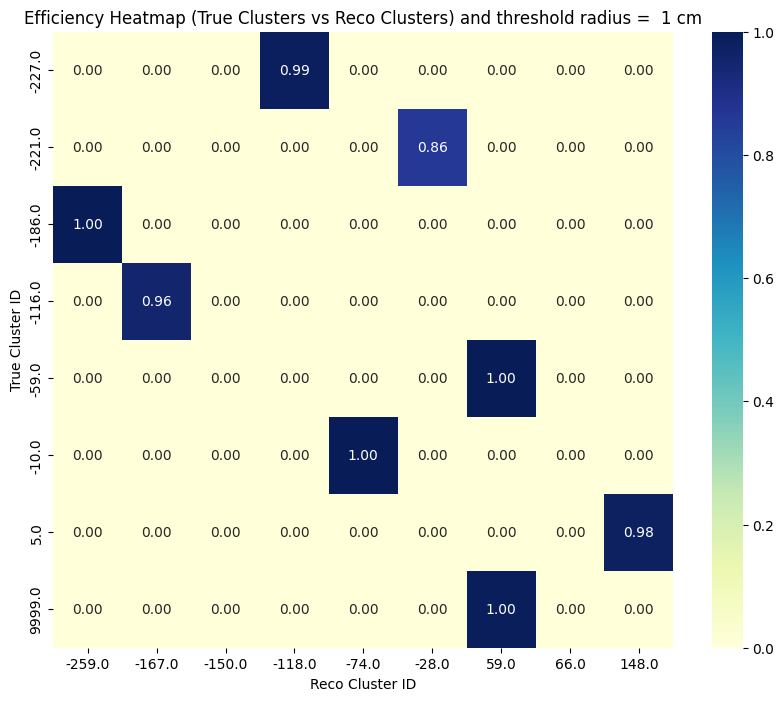

In [39]:
# Now recalculate efficiency within a radius of 1 cm
# without putting any restriction on number of reco points
# Recalulate efficiency for one nearest neighbor but this time with a distance threshold of 0.5 cm instead of 1 cm, to see how it affects the efficiency values

# Above part works, now we can do it for all clusters and find the best matching predicted cluster for each true cluster based on efficiency
# Skip if truth files not found
if skip_if_needed():
    print("Skipping this cell.")
else:
    from scipy.spatial import KDTree


# Create a list to store efficiency results for each true cluster
efficiency_results = []

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius
        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]
        # Check how many true points are within the radius of any predicted point
        matched_true_points = np.sum(np.array(num_neighbors) > 0)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap (True Clusters vs Reco Clusters) and threshold radius = {knn_dist_threshold:2.4g} cm")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
# plt.show(block=False)

True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 11111 / 11190, Efficiency = 0.99
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -22

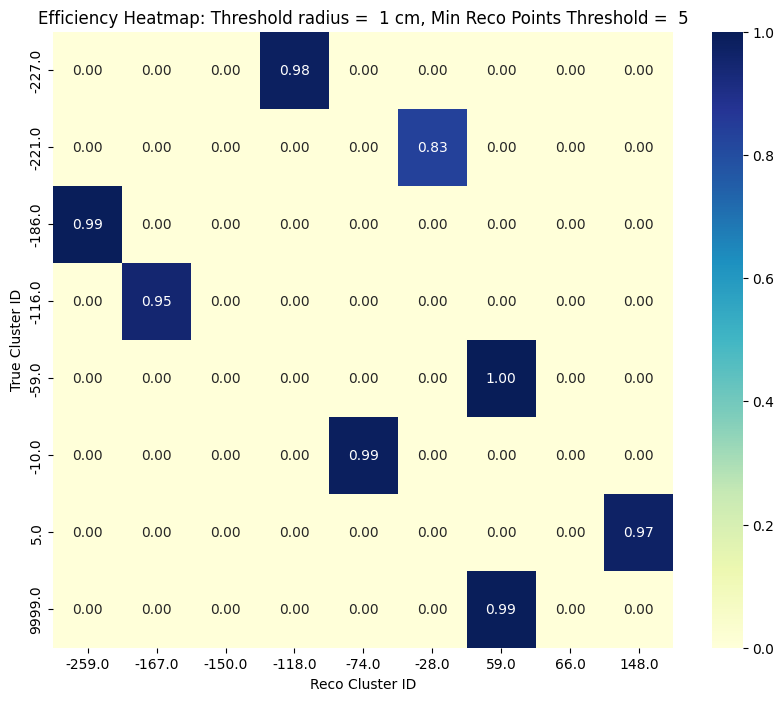

In [40]:
# Lets recalculate efficiency
# for radius 1 cm and 5 or more neighbors and make a heatmap of efficiency values for all true and reco cluster pairs

# Create a list to store efficiency results for each true cluster
efficiency_results = []

min_recopoints_threshold = 5  # Minimum number of reco points within the radius to consider a true point as matched

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius
        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]
        # Check how many true points are within the radius of any predicted point
        matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap: Threshold radius = {knn_dist_threshold:2.4g} cm, Min Reco Points Threshold = {min_recopoints_threshold:2.4g}")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
# plt.show(block=False)

True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 11144 / 11190, Efficiency = 1.00
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -22

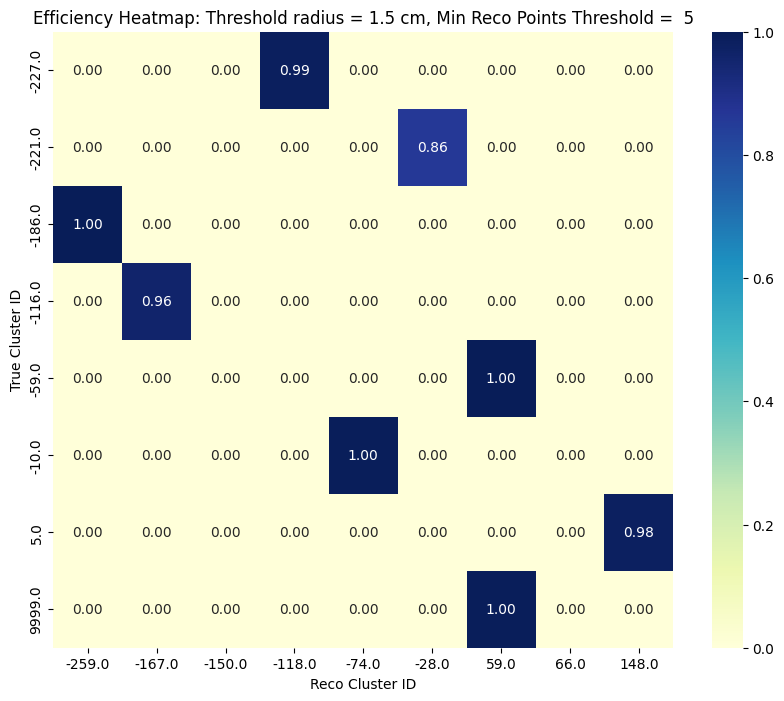

In [41]:
# Lets recalculate efficiency
# for radius 1.5 cm and 5 or more neighbors and make a heatmap of efficiency values for all true and reco cluster pairs

# Create a list to store efficiency results for each true cluster
efficiency_results = []

min_recopoints_threshold = 5  # Minimum number of reco points within the radius to consider a true point as matched

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=1.5*knn_dist_threshold)  # Find all neighbors within radius
        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]
        # Check how many true points are within the radius of any predicted point
        matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
    
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap: Threshold radius = {1.5*knn_dist_threshold:2.4g} cm, Min Reco Points Threshold = {min_recopoints_threshold:2.4g}")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
# plt.show(block=False)

True Cluster 9999 - Reco Cluster -150: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Points = 11144 / 11190, Efficiency = 1.00
True Cluster 9999 - Reco Cluster -74: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Points = 0 / 11190, Efficiency = 0.00
True Cluster -227 - Reco Cluster -150: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -227 - Reco Cluster -28: Matched True Points = 0 / 2302, Efficiency = 0.00
True Cluster -22

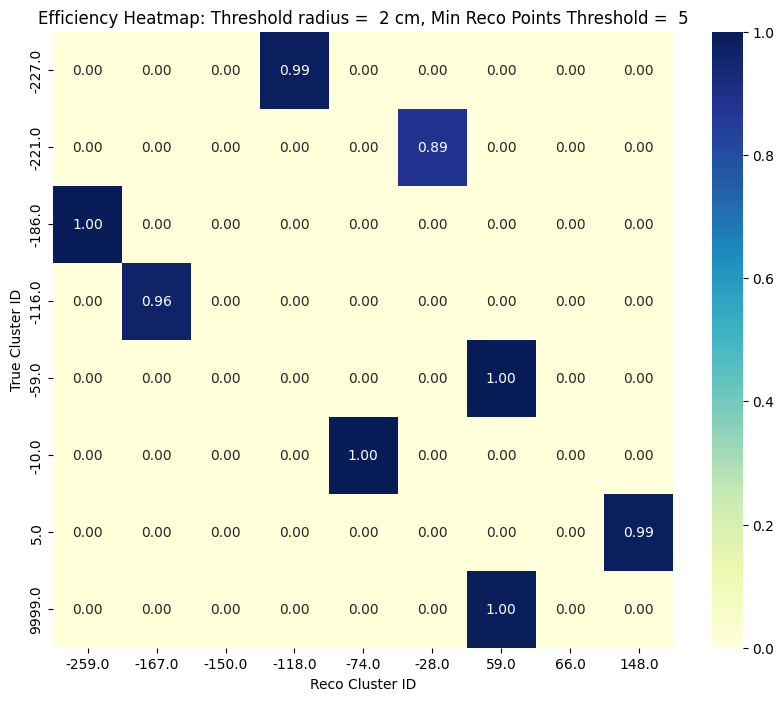

In [42]:
# Lets recalculate efficiency
# for radius 1.5 cm and 5 or more neighbors and make a heatmap of efficiency values for all true and reco cluster pairs

# Create a list to store efficiency results for each true cluster
efficiency_results = []

min_recopoints_threshold = 5  # Minimum number of reco points within the radius to consider a true point as matched

# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]
        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)
        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=2.0*knn_dist_threshold)  # Find all neighbors within radius
        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]
        # Check how many true points are within the radius of any predicted point
        matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold)
        total_true_points = len(true_points)
        efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_points': matched_true_points,
            'total_true_points': total_true_points,
            'efficiency': efficiency
        })
    
# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Points = {result['matched_true_points']} / {result['total_true_points']}, "
            f"Efficiency = {result['efficiency']:.2f}")
    
# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency').fillna(0)
print(efficiency_matrix)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Efficiency Heatmap: Threshold radius = {2.0*knn_dist_threshold:2.4g} cm, Min Reco Points Threshold = {min_recopoints_threshold:2.4g}")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
# plt.show(block=False)

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59
Number of reco points within 5 cm of the first true point: 134


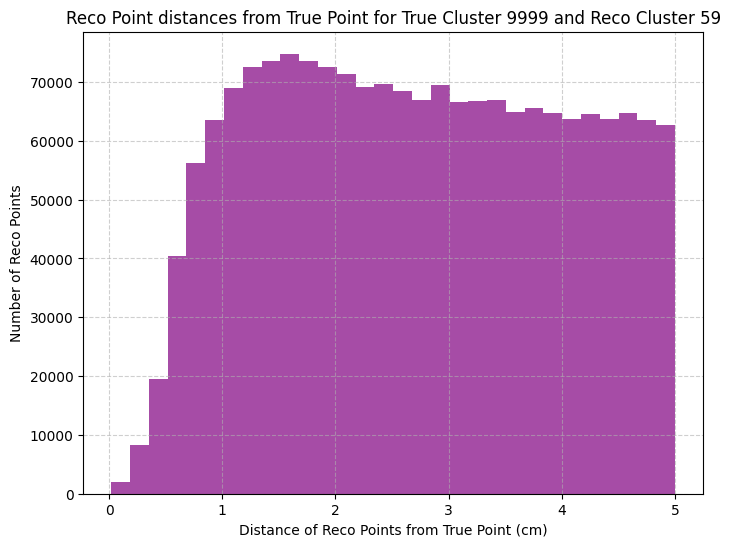

In [43]:
# now lets make a distribution of all 5 and more reco points that lie within 1.5 cm from true points
# First check it for one pair of reco and true cluster and then we can do it for all clusters

radius = 5

min_recopoints_threshold = 5  # Minimum number of reco points within the radius to consider a true point as matched

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# Query the KDTree with the true points to find nearest neighbors
indices = reco_tree.query_ball_point(true_coords, r=radius)  # Find all neighbors within radius

# Count the number of neighbors for each true point
num_neighbors = [len(neighbors) for neighbors in indices]

# how many neighbor points the first true point has within the radius?
print(f"Number of reco points within {radius} cm of the first true point: {num_neighbors[0]}")

distances = []

for i, neighbors in enumerate(indices):
  for neighbor in neighbors if num_neighbors[i] >= min_recopoints_threshold else []:
    distance = np.linalg.norm(reco_coords[neighbor] - true_coords[i], axis=0)
    distances.append(distance)

# make a plot of the distribution of distances of reco points from the first true point
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=30, alpha=0.7, color='purple')
plt.xlabel(f"Distance of Reco Points from True Point (cm)")
plt.ylabel("Number of Reco Points")
plt.title(f"Reco Point distances from True Point for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

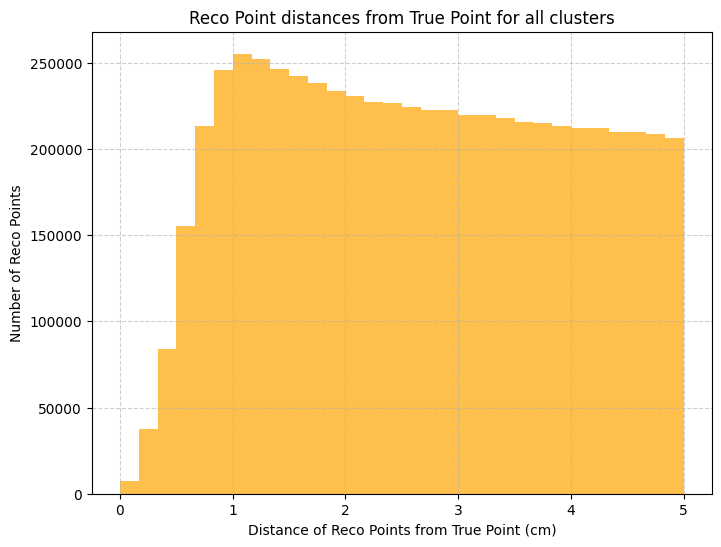

In [44]:
# lets do exactly the same above for all clusters
radius = 5
min_recopoints_threshold = 5  # Minimum number of reco points within the radius to consider a true point as matched

all_distances = []

for true_cluster_id, true_points in clusters_true.items():
  true_points = np.array(true_points)
  true_coords = true_points[:, :3]

  for reco_cluster_id, reco_points in clusters_reco.items():
    reco_points = np.array(reco_points)
    reco_coords = reco_points[:, :3]

    # Build KDTree for the predicted cluster
    reco_tree = KDTree(reco_coords)

    # Query the KDTree with the true points to find nearest neighbors
    indices = reco_tree.query_ball_point(true_coords, r=radius)  # Find all neighbors within radius

    # Count the number of neighbors for each true point
    num_neighbors = [len(neighbors) for neighbors in indices]

    for i, neighbors in enumerate(indices):
      for neighbor in neighbors if num_neighbors[i] >= min_recopoints_threshold else []:
        distance = np.linalg.norm(reco_coords[neighbor] - true_coords[i], axis=0)
        all_distances.append(distance)

# make a plot of the distribution of distances of reco points from the first true point
plt.figure(figsize=(8, 6))
plt.hist(all_distances, bins=30, alpha=0.7, color='orange')
plt.xlabel(f"Distance of Reco Points from True Point (cm)")
plt.ylabel("Number of Reco Points")
plt.title(f"Reco Point distances from True Point for all clusters")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)



Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


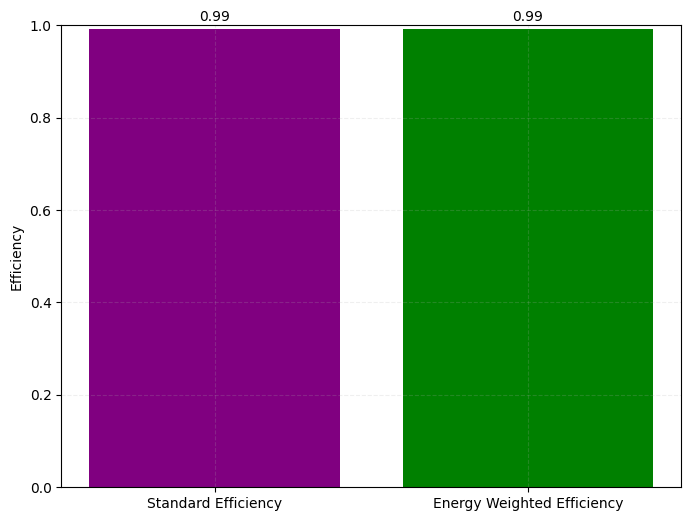

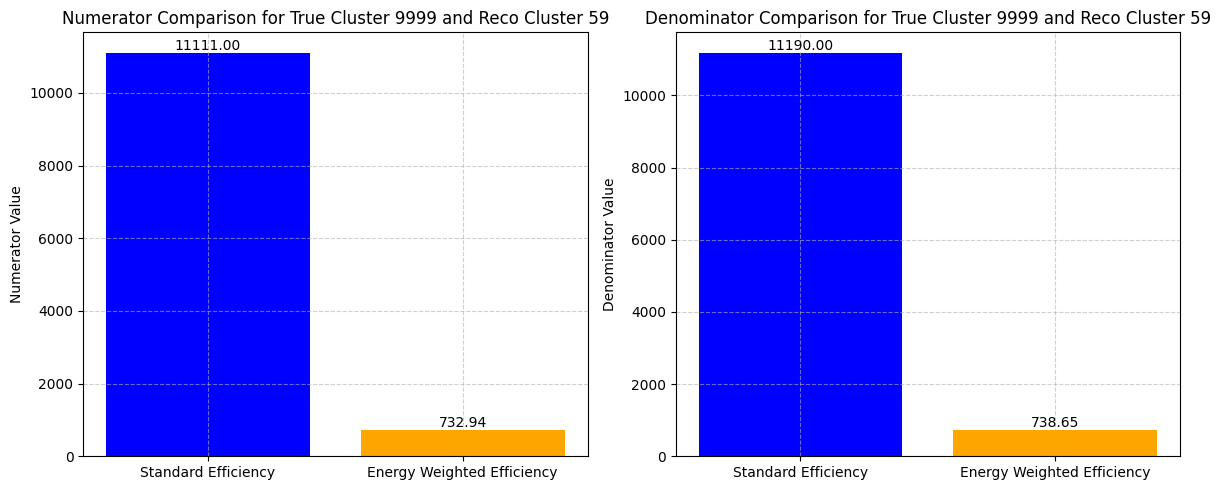

In [45]:
# lets compare before and after energy weighted efficiency calculation for one cluster pair and see how the efficiency values change

efficiency_results = []
numerator = [] # to hold the numerator values for before and after energy weighting
denominator = [] # to hold the denominator values for before and after energy weighting
min_recopoints_threshold = 5

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
true_energies = true_points[:, 5]  # Assuming energy is the 6th column

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)
# Query the KDTree with the true points to find nearest neighbors
indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius
# Count the number of neighbors for each true point
num_neighbors = [len(neighbors) for neighbors in indices]
# Check how many true points are within the radius of any predicted point
matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold)
total_true_points = len(true_points)
efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
numerator.append(matched_true_points)
denominator.append(total_true_points)
efficiency_results.append({
    'true_cluster_id': true_cluster_id,
    'reco_cluster_id': reco_cluster_id,
    'matched_true_points': matched_true_points,
    'total_true_points': total_true_points,
    'efficiency': efficiency
})
# Now calculate energy weighted efficiency
energy_weighted_matched_true_points = 0
for i, neighbors in enumerate(indices):
    if len(neighbors) > min_recopoints_threshold:
        energy_weighted_matched_true_points += true_energies[i]
energy_weighted_efficiency = energy_weighted_matched_true_points / np.sum(true_energies) if np.sum(true_energies) > 0 else 0
numerator.append(energy_weighted_matched_true_points)
denominator.append(np.sum(true_energies))
efficiency_results.append({
    'true_cluster_id': true_cluster_id,
    'reco_cluster_id': reco_cluster_id,
    'matched_true_points': energy_weighted_matched_true_points,
    'total_true_points': np.sum(true_energies),
    'efficiency': energy_weighted_efficiency
})
# plot bar chart to compare the two efficiency values
# also write value of efficiency on top of each bar
labels = ['Standard Efficiency', 'Energy Weighted Efficiency']
efficiency_values = [efficiency_results[0]['efficiency'], efficiency_results[1]['efficiency']]
plt.figure(figsize=(8, 6))
plt.bar(labels, efficiency_values, color=['purple', 'green'])
# write efficiency values on top of each bar
for i, eff in enumerate(efficiency_values):
    plt.text(i, eff + 0.01, f"{eff:.2f}", ha='center', va='bottom')
plt.ylabel("Efficiency")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.2)
# plt.show(block=False)

# plot numerator and denominator values for both cases in a bar chart in separate subplots
# also write value of numerator and denominator on top of each bar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, numerator, color=['blue', 'orange'])
# write numerator values on top of each bar
for i, num in enumerate(numerator):
    plt.text(i, num + 0.01, f"{num:.2f}", ha='center', va='bottom')
plt.ylabel("Numerator Value")
plt.title(f"Numerator Comparison for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.bar(labels, denominator, color=['blue', 'orange'])
# write denominator values on top of each bar
for i, num in enumerate(denominator):
    plt.text(i, num + 0.01, f"{num:.2f}", ha='center', va='bottom')
plt.ylabel("Denominator Value")
plt.title(f"Denominator Comparison for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)



True Cluster 9999 - Reco Cluster -150: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster -28: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster 59: Matched True Energy = 732.94 / 738.65, Energy-Weighted Efficiency = 0.99
True Cluster 9999 - Reco Cluster -74: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster -167: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster 148: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster -118: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster -259: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster 9999 - Reco Cluster 66: Matched True Energy = 0.00 / 738.65, Energy-Weighted Efficiency = 0.00
True Cluster -2

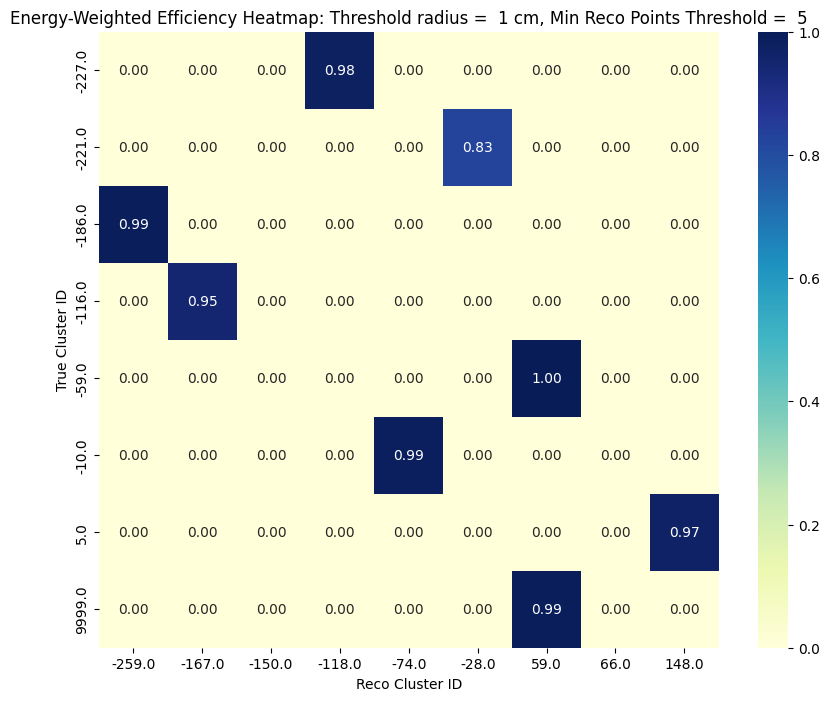

In [46]:
# lets re-weight our true points by energy of the points and then do the same efficiency calculation as above to see if it improves the matching between true and reco clusters
# lets reweight true points by energy

min_recopoints_threshold = 5  # Minimum number of reco points within the radius to consider a true point as matched
# Create a list to store efficiency results for each true cluster
efficiency_results = []

# save energies of true clusters
matched_true_cluster_energy = []
total_true_cluster_energy = []


# Loop over each true cluster
for true_cluster_id, true_points in clusters_true.items():
    true_points = np.array(true_points)
    true_coords = true_points[:, :3]
    true_energies = true_points[:, 5]  # Assuming energy is the 6th column

    # Loop over each predicted cluster to find the best match
    for reco_cluster_id, reco_points in clusters_reco.items():
        reco_points = np.array(reco_points)
        reco_coords = reco_points[:, :3]

        # Build KDTree for the predicted cluster
        reco_tree = KDTree(reco_coords)

        # Query the KDTree with the true points to find nearest neighbors
        indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius

        # Count the number of neighbors for each true point
        num_neighbors = [len(neighbors) for neighbors in indices]

        # Check how many true points are within the radius of any predicted point and reweight by energy
        matched_true_points_energy = np.sum([true_energies[i] for i, neighbors in enumerate(indices) if len(neighbors) > min_recopoints_threshold])
        matched_true_cluster_energy.append(matched_true_points_energy)

        total_true_energy = np.sum(true_energies)
        total_true_cluster_energy.append(total_true_energy)

        efficiency_energy_weighted = matched_true_points_energy / total_true_energy if total_true_energy > 0 else 0
    
        # Store the efficiency result
        efficiency_results.append({
            'true_cluster_id': true_cluster_id,
            'reco_cluster_id': reco_cluster_id,
            'matched_true_energy': matched_true_points_energy,
            'total_true_energy': total_true_energy,
            'efficiency_energy_weighted': efficiency_energy_weighted
        })

# Print the efficiency results
for result in efficiency_results:
    print(f"True Cluster {result['true_cluster_id']:2.4g} - Reco Cluster {result['reco_cluster_id']:2.4g}: "
            f"Matched True Energy = {result['matched_true_energy']:.2f} / {result['total_true_energy']:.2f}, "
            f"Energy-Weighted Efficiency = {result['efficiency_energy_weighted']:.2f}")

# convert this into 2D matrix and a plot
import pandas as pd
df = pd.DataFrame(efficiency_results)
efficiency_matrix_energy_weighted = df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='efficiency_energy_weighted').fillna(0)
print(efficiency_matrix_energy_weighted)
# plot heatmap
import seaborn as sns
# only shows ID values upto 3 significant digits to avoid overcrowding of labels
plt.figure(figsize=(10, 8))
sns.heatmap(efficiency_matrix_energy_weighted, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Energy-Weighted Efficiency Heatmap: Threshold radius = {knn_dist_threshold:2.4g} cm, Min Reco Points Threshold = {min_recopoints_threshold:2.4g}")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
# plt.show(block=False)




Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


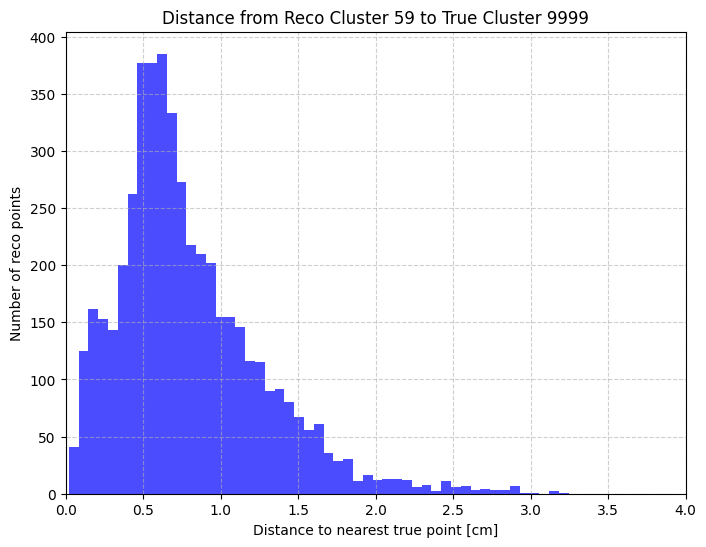

Total number of reco points in this cluster: 4942


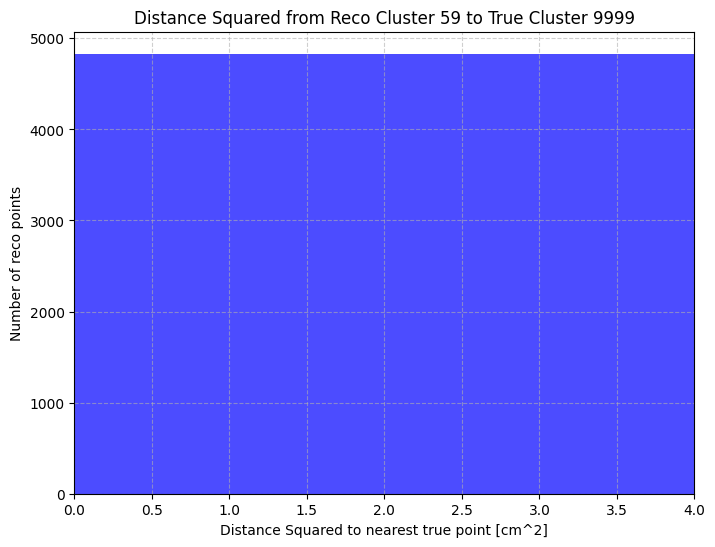

Number of reco points having a nearest true point within 0.5 cm: 1309 = 26.49% of the reco points in this cluster
Number of reco points having a nearest true point within 1.0 cm: 3546 = 71.75% of the reco points in this cluster
Number of reco points having a nearest true point within 2.0 cm: 4720 = 95.51% of the reco points in this cluster
Number of reco points having a nearest true point within 2.5 cm: 4794 = 97.01% of the reco points in this cluster
Number of reco points having a nearest true point within 3.0 cm: 4828 = 97.69% of the reco points in this cluster
Number of reco points having a nearest true point farther than 2.0 cm: 222 = 4.49% of the reco points in this cluster
Distance Threshold: 0.5 cm, Fraction of Reco Points within threshold: 26.49%
Distance Threshold: 1.0 cm, Fraction of Reco Points within threshold: 71.75%
Distance Threshold: 1.5 cm, Fraction of Reco Points within threshold: 89.60%
Distance Threshold: 2.0 cm, Fraction of Reco Points within threshold: 95.51%
Dist

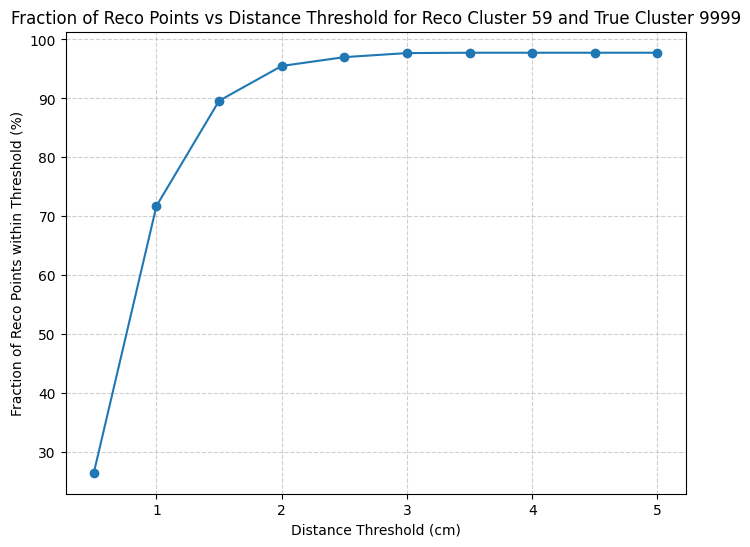

In [47]:
# Lets find the distance between a reco point to its true closest point

# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]

# Build KDTree for the true cluster
true_tree = KDTree(true_coords)
# Query the KDTree with the reco points to find nearest true neighbors
distances, indices = true_tree.query(reco_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=1000, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

print("Total number of reco points in this cluster:", len(indices))

# Now lets find the fraction of reco points that have a nearest true point within a distance but this time instead of distance we want to use distance square
# Query the KDTree with the reco points to find nearest true neighbors and get squared distances
distances_squared, indices = true_tree.query(reco_coords, k=1)  # p=2 for Euclidean distance
distances_squared = distances_squared ** 2  # Square the distances
# Draw distance squared histogram
plt.figure(figsize=(8, 6))
plt.hist(distances_squared, bins=100, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance Squared to nearest true point [cm^2]")
plt.ylabel("Number of reco points")
plt.title(f"Distance Squared from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

# lets counts how many true points are within the knn_dist_threshold of the predicted cluster
num_matched_points = np.sum(distances <= 0.5*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {0.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= 2*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= 2.5*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {2.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= 3.0*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {3.0*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")

num_matched_points = np.sum(distances > 2*knn_dist_threshold)
print(f"Number of reco points having a nearest true point farther than {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")

# lets make a plot of fraction of reco points within a distance threshold vs distance threshold for this cluster pair
radii = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
fractions = []
for radius in radii:
    num_matched_points = np.sum(distances <= radius)
    fraction = num_matched_points / len(indices) if len(indices) > 0 else 0
    fractions.append(fraction)
    print(f"Distance Threshold: {radius} cm, Fraction of Reco Points within threshold: {fraction*100:.2f}%")
# plot this
plt.figure(figsize=(8, 6))
plt.plot(radii, [f*100 for f in fractions], marker='o')
plt.xlabel("Distance Threshold (cm)")
plt.ylabel("Fraction of Reco Points within Threshold (%)")
plt.title(f"Fraction of Reco Points vs Distance Threshold for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)


Testing KDTree matching for True Cluster -10 and Reco Cluster -74


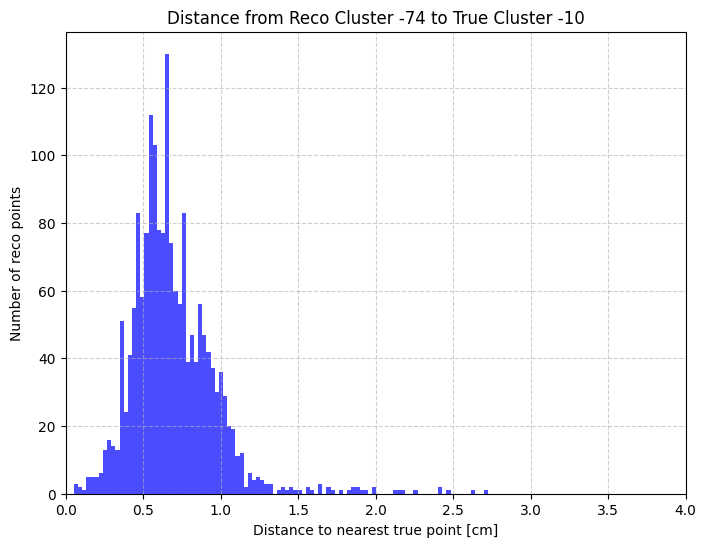

Total number of reco points in this cluster: 1772


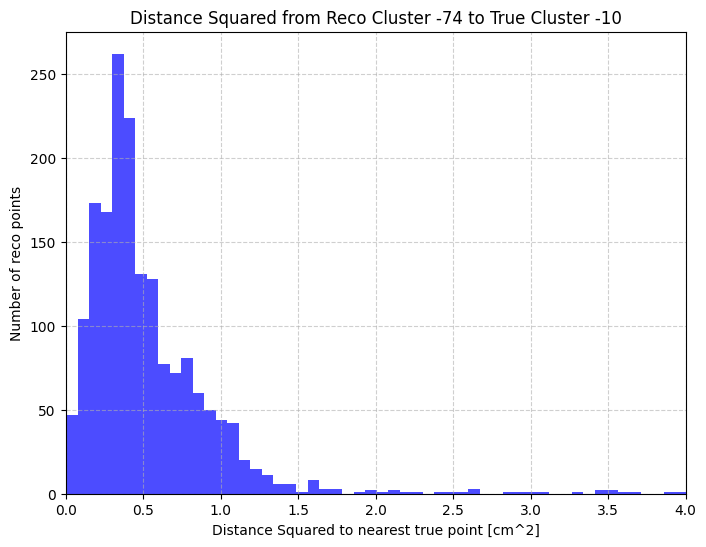

Number of reco points having a nearest true point within 0.5 cm: 382 = 21.56% of the reco points in this cluster
Number of reco points having a nearest true point within 1.0 cm: 1599 = 90.24% of the reco points in this cluster
Number of reco points having a nearest true point within 2.0 cm: 1763 = 99.49% of the reco points in this cluster
Number of reco points having a nearest true point within 2.5 cm: 1770 = 99.89% of the reco points in this cluster
Number of reco points having a nearest true point within 3.0 cm: 1772 = 100.00% of the reco points in this cluster
Number of reco points having a nearest true point farther than 2.0 cm: 9 = 0.51% of the reco points in this cluster
Distance Threshold: 0.5 cm, Fraction of Reco Points within threshold: 21.56%
Distance Threshold: 1.0 cm, Fraction of Reco Points within threshold: 90.24%
Distance Threshold: 1.5 cm, Fraction of Reco Points within threshold: 98.36%
Distance Threshold: 2.0 cm, Fraction of Reco Points within threshold: 99.49%
Distan

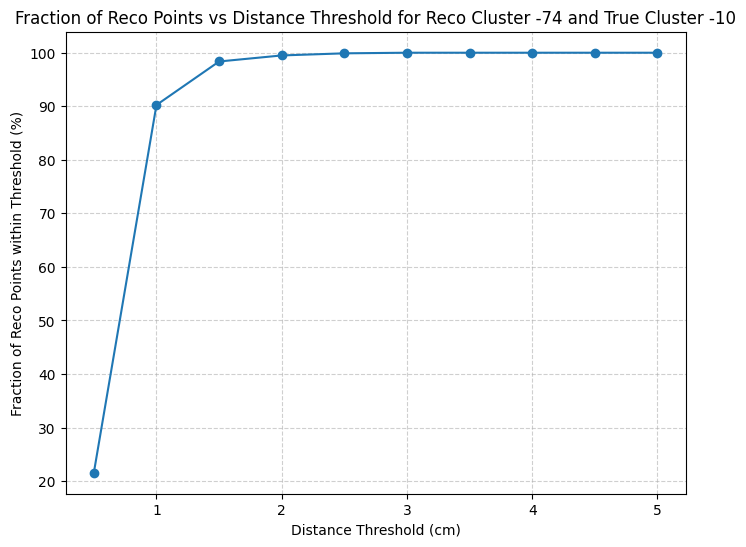

In [48]:
# lets do same for another pair of clusters
# Lets find the distance between a reco point to its true closest point

# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[3]
reco_cluster_id = list(clusters_reco.keys())[3]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
#reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # add an offset to z coordinate of reco points to see how it affects the distance distribution

# Build KDTree for the true cluster
true_tree = KDTree(true_coords)
# Query the KDTree with the reco points to find nearest true neighbors
distances, indices = true_tree.query(reco_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=100, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)
print("Total number of reco points in this cluster:", len(indices))

# Now lets find the fraction of reco points that have a nearest true point within a distance but this time instead of distance we want to use distance square
# Query the KDTree with the reco points to find nearest true neighbors and get squared distances
distances_squared, indices = true_tree.query(reco_coords, k=1)  # p=2 for Euclidean distance
distances_squared = distances_squared ** 2  # Square the distances
# Draw distance squared histogram
plt.figure(figsize=(8, 6))
plt.hist(distances_squared, bins=100, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance Squared to nearest true point [cm^2]")
plt.ylabel("Number of reco points")
plt.title(f"Distance Squared from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

# lets counts how many true points are within the knn_dist_threshold of the predicted cluster
num_matched_points = np.sum(distances <= 0.5*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {0.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= 2*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= 2.5*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {2.5*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")
num_matched_points = np.sum(distances <= 3.0*knn_dist_threshold)
print(f"Number of reco points having a nearest true point within {3.0*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")

num_matched_points = np.sum(distances > 2*knn_dist_threshold)
print(f"Number of reco points having a nearest true point farther than {2*knn_dist_threshold} cm: {num_matched_points} = {num_matched_points/len(indices)*100:.2f}% of the reco points in this cluster")

# lets make a plot of fraction of reco points within a distance threshold vs distance threshold for this cluster pair
radii = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
fractions = []
for radius in radii:
    num_matched_points = np.sum(distances <= radius)
    fraction = num_matched_points / len(indices) if len(indices) > 0 else 0
    fractions.append(fraction)
    print(f"Distance Threshold: {radius} cm, Fraction of Reco Points within threshold: {fraction*100:.2f}%")
# plot this
plt.figure(figsize=(8, 6))
plt.plot(radii, [f*100 for f in fractions], marker='o')
plt.xlabel("Distance Threshold (cm)")
plt.ylabel("Fraction of Reco Points within Threshold (%)")
plt.title(f"Fraction of Reco Points vs Distance Threshold for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)



total true points: 49860 , with shape: (49860, 3)
total reco points: 16188 , with shape: (16188, 3)


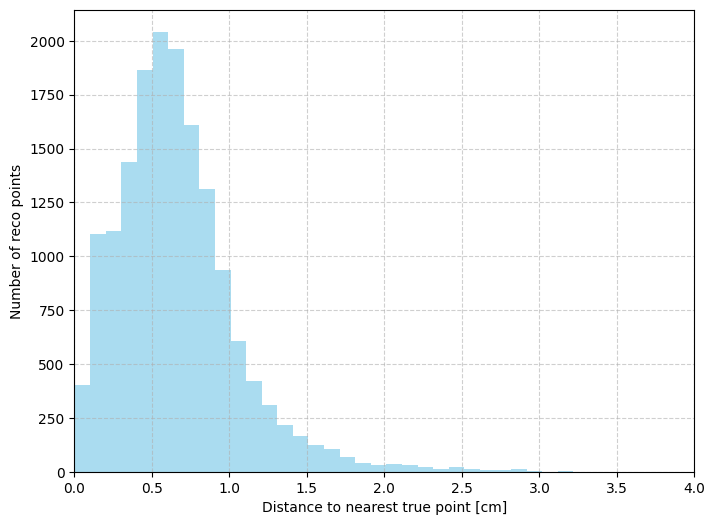

Distance Threshold: 0.5 cm, Fraction of Reco Points within threshold: 35.98%
Distance Threshold: 1.0 cm, Fraction of Reco Points within threshold: 84.74%
Distance Threshold: 1.5 cm, Fraction of Reco Points within threshold: 95.61%
Distance Threshold: 2.0 cm, Fraction of Reco Points within threshold: 97.99%
Distance Threshold: 2.5 cm, Fraction of Reco Points within threshold: 98.71%
Distance Threshold: 3.0 cm, Fraction of Reco Points within threshold: 99.01%
Distance Threshold: 3.5 cm, Fraction of Reco Points within threshold: 99.04%
Distance Threshold: 4.0 cm, Fraction of Reco Points within threshold: 99.04%
Distance Threshold: 4.5 cm, Fraction of Reco Points within threshold: 99.04%
Distance Threshold: 5.0 cm, Fraction of Reco Points within threshold: 99.04%


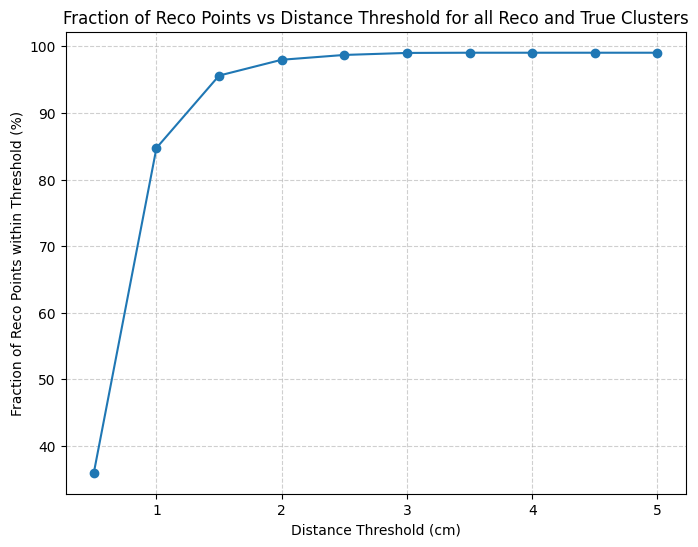

In [49]:
# Now lets draw distances for all reco points to their nearest true points.

all_true_coords = true_5d_points[:, :3]
all_reco_coords = predicted_5d_points[:, :3]

print("total true points:", len(all_true_coords), ", with shape:", all_true_coords.shape)
print("total reco points:", len(all_reco_coords), ", with shape:", all_reco_coords.shape)

true_tree = KDTree(all_true_coords)
# Query the KDTree with the true points to find nearest neighbors
distances, indices = true_tree.query(all_reco_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=1000, color='skyblue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)


# make plot of fraction of reco points within a distance threshold vs distance threshold for all reco points
radii = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
fractions = []
for radius in radii:
    num_matched_points = np.sum(distances <= radius)
    fraction = num_matched_points / len(indices) if len(indices) > 0 else 0
    fractions.append(fraction)
    print(f"Distance Threshold: {radius} cm, Fraction of Reco Points within threshold: {fraction*100:.2f}%")
# plot this
plt.figure(figsize=(8, 6))
plt.plot(radii, [f*100 for f in fractions], marker='o')
plt.xlabel("Distance Threshold (cm)")
plt.ylabel("Fraction of Reco Points within Threshold (%)")
plt.title(f"Fraction of Reco Points vs Distance Threshold for all Reco and True Clusters")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)





Testing KDTree matching for True Cluster -10 and Reco Cluster -74
Efficiency for True Cluster -10 and Reco Cluster -74: Matched True Points = 6406 / 6483, Efficiency = 0.99
Purity for Reco Cluster -74 and True Cluster -10: Matched Reco Points = 1599 / 1772, Purity = 0.90
Angle of the true cluster with respect to z-axis: 77.20 degrees
Radius: 0.5 cm, Matched Reco Points = 382 / 1772, Purity = 0.22
Radius: 1.0 cm, Matched Reco Points = 1599 / 1772, Purity = 0.90
Radius: 1.5 cm, Matched Reco Points = 1743 / 1772, Purity = 0.98
Radius: 2.0 cm, Matched Reco Points = 1763 / 1772, Purity = 0.99
Radius: 2.5 cm, Matched Reco Points = 1770 / 1772, Purity = 1.00
Radius: 3.0 cm, Matched Reco Points = 1772 / 1772, Purity = 1.00


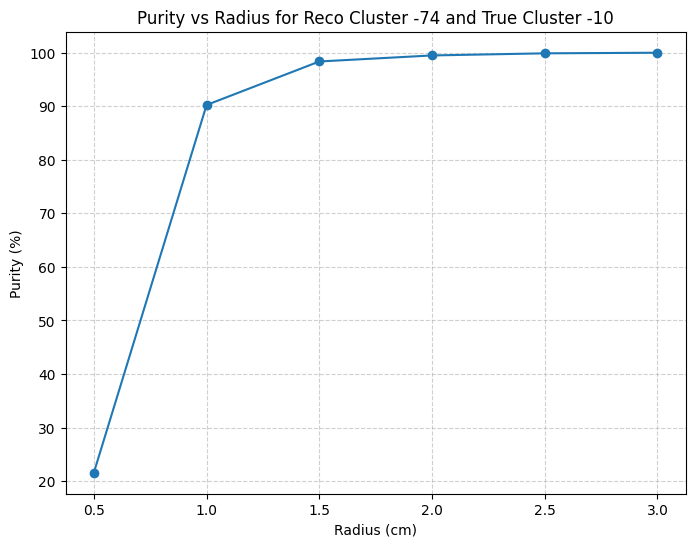

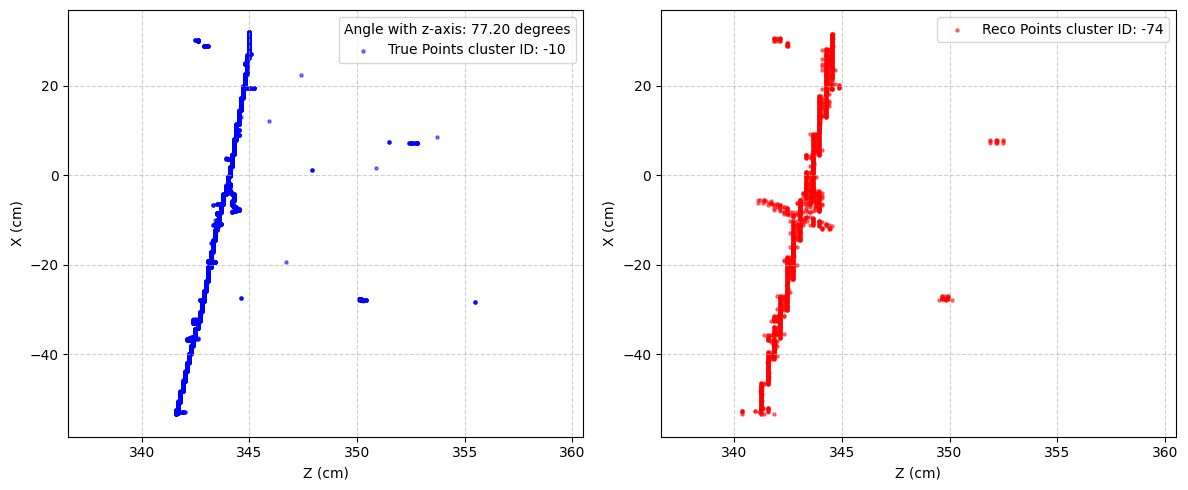

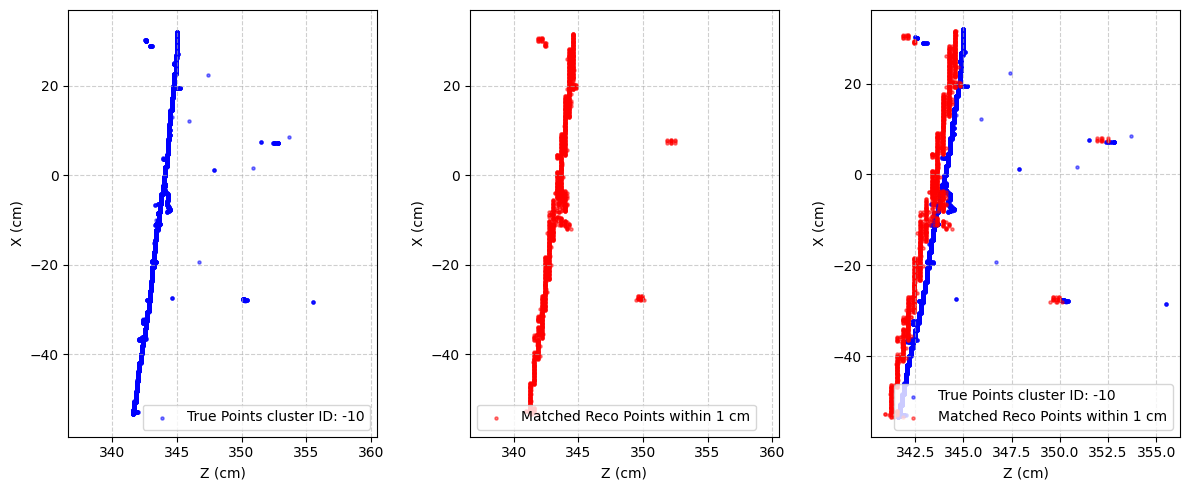

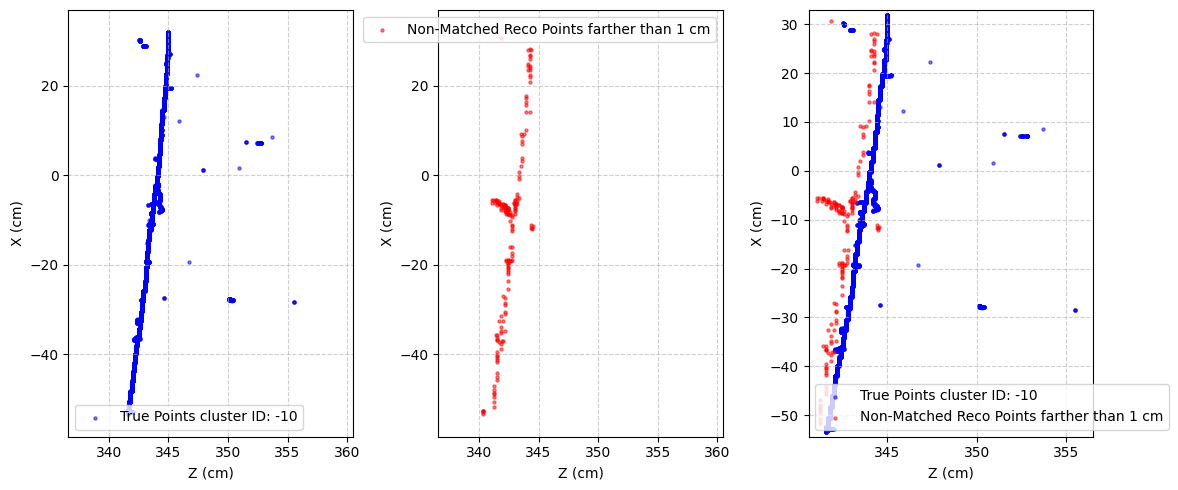

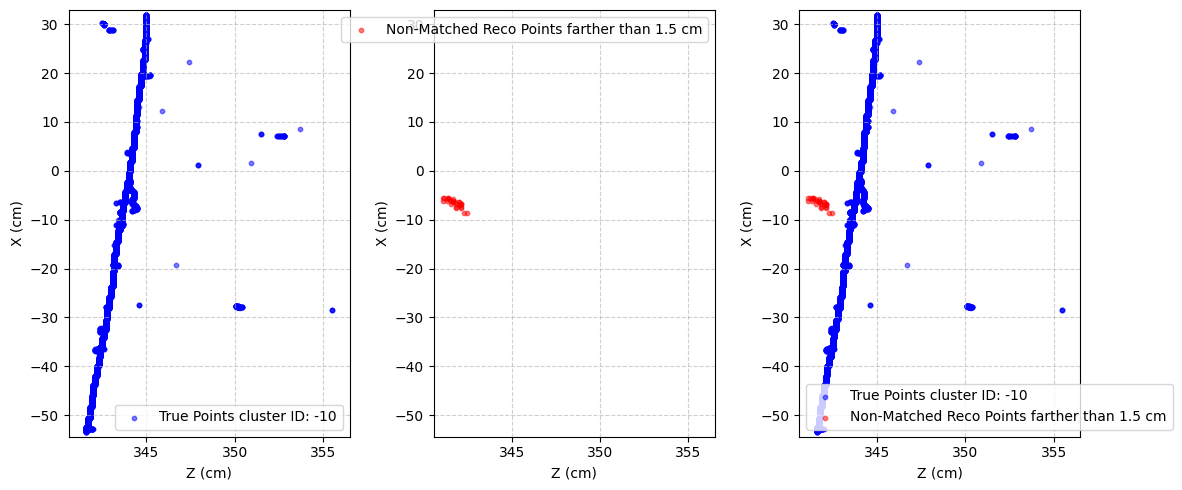

In [50]:
# lets calculate purity for a couple of clusters
# also draw those clusters

purity_results = []  # Initialize purity_results as an empty list

min_recopoints_threshold_eff = 5 # Minimum number of reco points within the radius to consider a true point as matched
min_recopoints_threshold_pur = 1 # Minimum number of true points within the radius to consider a reco point as matched
radius  = 1

true_cluster_id = list(clusters_true.keys())[3]
reco_cluster_id = list(clusters_reco.keys())[3]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
#reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # add an offset to z coordinate of reco points to see how it affects the distance distribution

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# Query the KDTree with the true points to find nearest neighbors
indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius

# Count the number of neighbors for each true point
num_neighbors = [len(neighbors) for neighbors in indices]

# Check how many true points are within the radius of any predicted point
matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold_eff) 
total_true_points = len(true_points)
efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
print(f"Efficiency for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}: "
        f"Matched True Points = {matched_true_points} / {total_true_points}, "
        f"Efficiency = {efficiency:.2f}")

# Now calculate purity for the same cluster pair
# Build KDTree for the true cluster
true_tree = KDTree(true_coords)

# Query the KDTree with the predicted points to find nearest true point
distances, indices = true_tree.query(reco_coords, k=1)
# Check how many reco points have a nearest true point within the radius
matched_reco_points = np.sum(distances <= radius)
total_reco_points = len(reco_points)
purity = matched_reco_points / total_reco_points if total_reco_points > 0 else 0
# Store the purity result
purity_results.append({
        'reco_cluster_id': reco_cluster_id,
        'true_cluster_id': true_cluster_id,
        'matched_reco_points': matched_reco_points,
        'total_reco_points': total_reco_points,
        'purity': purity
})
print(f"Purity for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g}: "
        f"Matched Reco Points = {matched_reco_points} / {total_reco_points}, "
        f"Purity = {purity:.2f}")

# Lets find the angle angle of true cluster with respect to the z-direction
# to find angle lets use last 20% of the true points from higher-z side
true_cluster = np.array(clusters_true[true_cluster_id])
num_points = len(true_cluster)
last_20_percent_points = true_cluster[int(0.8 * num_points):]
# Fit a line to these points in x-z plane and find the angle of this line with respect to z-axis
z = last_20_percent_points[:, 2]
x = last_20_percent_points[:, 0]
coefficients = np.polyfit(z, x, 1)  # Fit a line (degree 1)
slope = coefficients[0]
angle_rad = np.arctan(slope)  # Angle in radians
angle_deg = np.degrees(angle_rad)  # Convert to degrees
if angle_deg < 0:
    angle_deg = abs(angle_deg)  # Take absolute value to get angle with respect to z-axis
print(f"Angle of the true cluster with respect to z-axis: {angle_deg:.2f} degrees")

# lets re-calculate and plot purity for different radius values for the same cluster pair
# this time we use query to exact one true point and not query_ball_point
radii = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
purity_values = []
for radius in radii:
        distance, index = true_tree.query(reco_coords, k=1)
        matched_reco_points = np.sum(distance <= radius)
        total_reco_points = len(reco_points)
        purity = matched_reco_points / total_reco_points if total_reco_points > 0 else 0
        purity_values.append(purity)
        print(f"Radius: {radius} cm, Matched Reco Points = {matched_reco_points} / {total_reco_points}, Purity = {purity:.2f}")
# plot purity vs radius
plt.figure(figsize=(8, 6))
plt.plot(radii, [p*100 for p in purity_values], marker='o')
plt.xlabel("Radius (cm)")
plt.ylabel("Purity (%)")
plt.title(f"Purity vs Radius for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)

# Now draw these clusters side by side in x-z plane
xrange_low = true_cluster[:, 2].min() - 5
xrange_high = true_cluster[:, 2].max() + 5
yrange_low = true_cluster[:, 0].min() - 5
yrange_high = true_cluster[:, 0].max() + 5
true_marker_style = '^'
reco_marker_style = 'v'

true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
# add angle value to the legend
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.legend(title=f"Angle with z-axis: {angle_deg:.2f} degrees")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.scatter(reco_cluster[:, 2], reco_cluster[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Reco Points cluster ID: {reco_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

# lets draw true cluster points and matched_reco_points in side by side plots
radius = 1
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
# find matched reco points
true_tree = KDTree(true_cluster[:, :3])
distances, indices = true_tree.query(reco_cluster[:, :3], k=1)
matched_reco_points = reco_cluster[distances <= radius]
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 3, 2)
plt.scatter(matched_reco_points[:, 2], matched_reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Matched Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 3, 3)
# both true and non-matched reco points together
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(matched_reco_points[:, 2], matched_reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Matched Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplots_adjust(wspace=0.3, hspace=0.1)
# plt.show(block=False)

# Now lets draw true cluster points and non-matched_reco_points in side by side plots
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
# find non-matched reco points
true_tree = KDTree(true_cluster[:, :3])
distances, indices = true_tree.query(reco_cluster[:, :3], k=1)
nonmatched_reco_points = reco_cluster[distances > radius]
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 3, 2)
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 3, 3)
# both true and non-matched reco points together
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(true_cluster[:, 2].min() - 1, true_cluster[:, 2].max() + 1)
plt.ylim(true_cluster[:, 0].min() - 1, true_cluster[:, 0].max() + 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.1)
# plt.show(block=False)

# Now lets draw true cluster points and non-matched_reco_points in side by side plots
# for 1.5 cm radius
radius = 1.5
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
# find non-matched reco points
true_tree = KDTree(true_cluster[:, :3])
distances, indices = true_tree.query(reco_cluster[:, :3], k=1)
nonmatched_reco_points = reco_cluster[distances > radius]
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=10, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(true_cluster[:, 2].min() - 1, true_cluster[:, 2].max() + 1)
plt.ylim(true_cluster[:, 0].min() - 1, true_cluster[:, 0].max() + 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 3, 2)
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 0], s=10, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(true_cluster[:, 2].min() - 1, true_cluster[:, 2].max() + 1)
plt.ylim(true_cluster[:, 0].min() - 1, true_cluster[:, 0].max() + 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 3, 3)
# both true and non-matched reco points together
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=10, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 0], s=10, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(true_cluster[:, 2].min() - 1, true_cluster[:, 2].max() + 1)
plt.ylim(true_cluster[:, 0].min() - 1, true_cluster[:, 0].max() + 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.1)
# plt.show(block=False)



Testing KDTree matching for True Cluster -10 and Reco Cluster -74


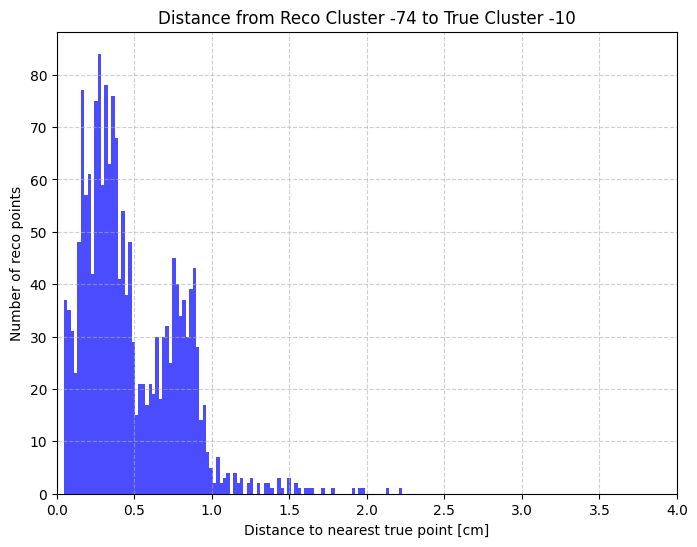

Total number of reco points in this cluster: 1772
Number of reco points having a nearest true point farther than 1 cm: 62 / 1772 = 3.50% of the reco points in this cluster


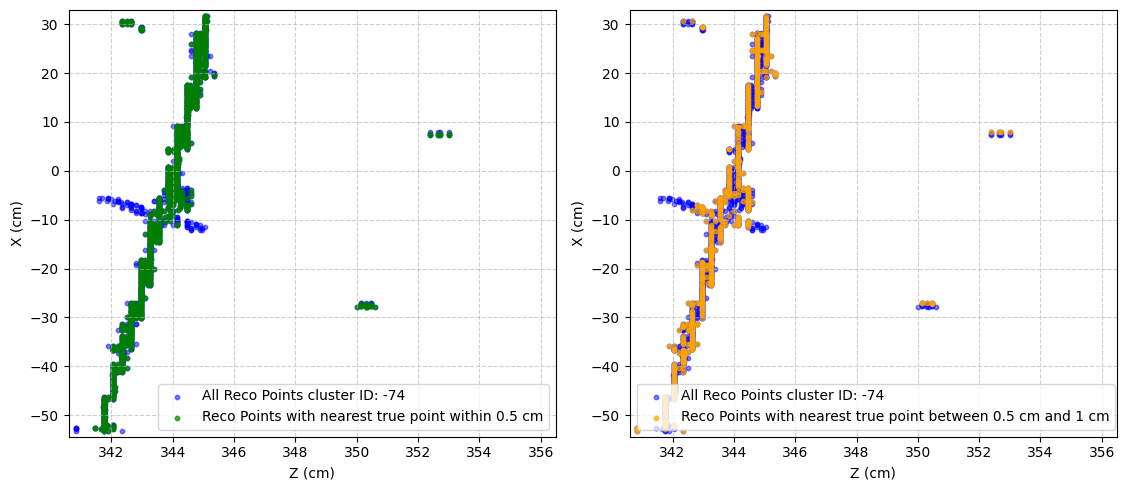

In [51]:
# recalculate distance between reco and nearest true point

# lets do same for another pair of clusters
# Lets find the distance between a reco point to its true closest point

# Select one true cluster and one predicted cluster for testing
true_cluster_id = list(clusters_true.keys())[3]
reco_cluster_id = list(clusters_reco.keys())[3]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # add an offset to z coordinate of reco points to see how it affects the distance distribution

# Build KDTree for the true cluster
true_tree = KDTree(true_coords)
# Query the KDTree with the reco points to find nearest true neighbors
distances, indices = true_tree.query(reco_coords, k=1)

# Draw distance histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=100, color='blue', alpha=0.7)
plt.xlim(0, 4)
plt.xlabel("Distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)
print("Total number of reco points in this cluster:", len(indices))

#print number of reco points that are beyond 1 cm from their nearest true point
num_far_points = np.sum(distances > 1)
print(f"Number of reco points having a nearest true point farther than 1 cm: {num_far_points} / {len(indices)} = {num_far_points/len(indices)*100:.2f}% of the reco points in this cluster")

#Let's draw all reco points and overlap them with reco points which have nearest true point below 0.5 cm and above 0.5 cm but less than 1 cm in two different colors
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(reco_coords[:, 2], reco_coords[:, 0], s=10, color='blue', alpha=0.5, label=f'All Reco Points cluster ID: {reco_cluster_id:2.4g}')
plt.scatter(reco_coords[distances <= 0.5][:, 2], reco_coords[distances <= 0.5][:, 0], s=10, color='green', alpha=0.7, label=f'Reco Points with nearest true point within 0.5 cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(true_coords[:, 2].min() - 1, true_coords[:, 2].max() + 1)
plt.ylim(true_coords[:, 0].min() - 1, true_coords[:, 0].max() + 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.scatter(reco_coords[:, 2], reco_coords[:, 0], s=10, color='blue', alpha=0.5, label=f'All Reco Points cluster ID: {reco_cluster_id:2.4g}')
plt.scatter(reco_coords[(distances > 0.5) & (distances <= 1)][:, 2], reco_coords[(distances > 0.5) & (distances <= 1)][:, 0], s=10, color='orange', alpha=0.7, label=f'Reco Points with nearest true point between 0.5 cm and 1 cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(true_coords[:, 2].min() - 1, true_coords[:, 2].max() + 1)
plt.ylim(true_coords[:, 0].min() - 1, true_coords[:, 0].max() + 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)

Testing KDTree matching for True Cluster -10 and Reco Cluster -74
After shifting reco points by 0.5 cm in z direction:
Efficiency for True Cluster -10 and Reco Cluster -74: Matched True Points = 6433 / 6483, Efficiency = 0.99
Purity for Reco Cluster -74 and True Cluster -10: Matched Reco Points = 1710 / 1772, Purity = 0.97


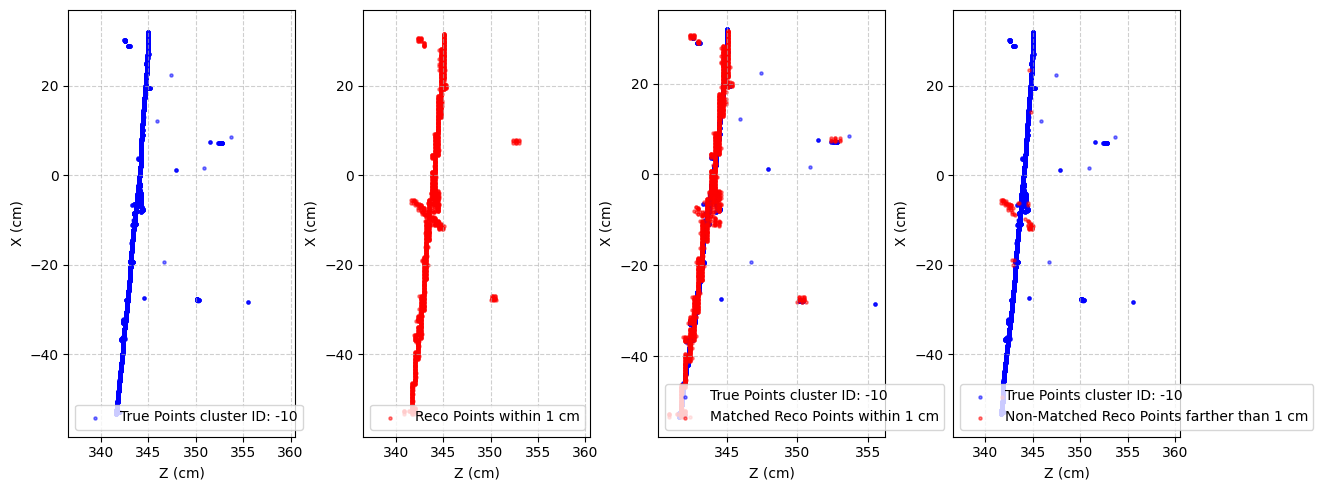

In [52]:
# lets shift reco points by 0.5 cm in z directions and re-draw matched and non-matched points for 1 cm radius
# also recalculate purity for this cluster pair with shifted reco points and see how it changes with radius

purity_results = []  # Initialize purity_results as an empty list

min_recopoints_threshold_eff = 5 # Minimum number of reco points within the radius to consider a true point as matched
min_recopoints_threshold_pur = 1 # Minimum number of true points within the radius to consider a reco point as matched
radius  = 1

true_cluster_id = list(clusters_true.keys())[3]
reco_cluster_id = list(clusters_reco.keys())[3]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # add an offset to z coordinate of reco points to see how it affects the distance distribution
print("After shifting reco points by 0.5 cm in z direction:")

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# Query the KDTree with the true points to find nearest neighbors
indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius

# Count the number of neighbors for each true point
num_neighbors = [len(neighbors) for neighbors in indices]

# Check how many true points are within the radius of any predicted point
matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold_eff) 
total_true_points = len(true_points)
efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
print(f"Efficiency for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}: "
        f"Matched True Points = {matched_true_points} / {total_true_points}, "
        f"Efficiency = {efficiency:.2f}")

# Now calculate purity for the same cluster pair
# Build KDTree for the true cluster
true_tree = KDTree(true_coords)

# Query the KDTree with the predicted points to find nearest true point
distances, indices = true_tree.query(reco_coords, k=1)
# Check how many reco points have a nearest true point within the radius
matched_reco_points = np.sum(distances <= radius)
total_reco_points = len(reco_points)
purity = matched_reco_points / total_reco_points if total_reco_points > 0 else 0
# Store the purity result
purity_results.append({
        'reco_cluster_id': reco_cluster_id,
        'true_cluster_id': true_cluster_id,
        'matched_reco_points': matched_reco_points,
        'total_reco_points': total_reco_points,
        'purity': purity
})
print(f"Purity for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g}: "
        f"Matched Reco Points = {matched_reco_points} / {total_reco_points}, "
        f"Purity = {purity:.2f}")

# lets draw true cluster points, matched_reco_points and non matched reco points in side by side plots
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_cluster = reco_cluster.copy()  # Create a copy to avoid modifying the original data
reco_cluster[:, 2] = reco_cluster[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

# find matched reco points
true_tree = KDTree(true_cluster[:, :3])
distances, indices = true_tree.query(reco_cluster[:, :3], k=1)
matched_reco_points = reco_cluster[distances <= radius]
nonmatched_reco_points = reco_cluster[distances > radius]
plt.figure(figsize=(12, 5))
plt.subplot(1, 4, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 4, 2)
plt.scatter(reco_points[:, 2], reco_points[:, 0], s=marker_size, marker='o', color='red', alpha=0.5, label=f'Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 4, 3)
# both true and non-matched reco points together
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(matched_reco_points[:, 2], matched_reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Matched Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
#both true and non-matched reco points together
plt.subplot(1, 4, 4)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.xlim(xrange_low, xrange_high)
plt.ylim(yrange_low, yrange_high)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplots_adjust(wspace=0.3, hspace=0.1)
# plt.show(block=False)



Testing KDTree matching for True Cluster 9999 and Reco Cluster 59
Efficiency for True Cluster 9999 and Reco Cluster 59: Matched True Points = 11121 / 11190, Efficiency = 0.99
Purity for Reco Cluster 59 and True Cluster 9999: Matched Reco Points = 3499 / 4942, Purity = 0.71
Angle of the true cluster with respect to z-axis: 13.36 degrees


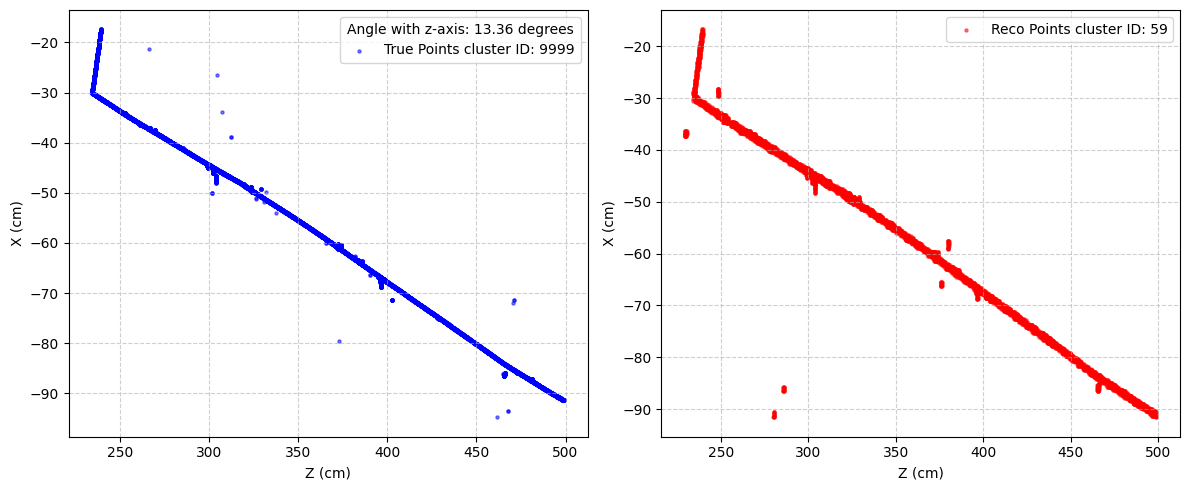

In [53]:
# same for a neutrino cluster
# lets calculate purity for a couple of clusters
# also draw those clusters

min_recopoints_threshold_eff = 5 # Minimum number of reco points within the radius to consider a true point as matched
min_recopoints_threshold_pur = 1 # Minimum number of true points within the radius to consider a reco point as matched
radius  = 1

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
true_coords = true_points[:, :3]
reco_coords = reco_points[:, :3]
reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # add an offset to z coordinate of reco points to see how it affects the distance distribution

# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_coords)

# Query the KDTree with the true points to find nearest neighbors
indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius

# Count the number of neighbors for each true point
num_neighbors = [len(neighbors) for neighbors in indices]

# Check how many true points are within the radius of any predicted point
matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold_eff) 
total_true_points = len(true_points)
efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0
print(f"Efficiency for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}: "
        f"Matched True Points = {matched_true_points} / {total_true_points}, "
        f"Efficiency = {efficiency:.2f}")

# Now calculate purity for the same cluster pair
# Build KDTree for the true cluster
true_tree = KDTree(true_coords)

# Query the KDTree with the predicted points to find nearest true point
distances, indices = true_tree.query(reco_coords, k=1)
# Check how many reco points have a nearest true point within the radius
matched_reco_points = np.sum(distances <= radius)
total_reco_points = len(reco_points)
purity = matched_reco_points / total_reco_points if total_reco_points > 0 else 0
# Store the purity result
purity_results.append({
        'reco_cluster_id': reco_cluster_id,
        'true_cluster_id': true_cluster_id,
        'matched_reco_points': matched_reco_points,
        'total_reco_points': total_reco_points,
        'purity': purity
})
print(f"Purity for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g}: "
        f"Matched Reco Points = {matched_reco_points} / {total_reco_points}, "
        f"Purity = {purity:.2f}")

# Lets find the angle angle of true cluster with respect to the z-direction
# to find angle lets use last 20% of the true points from higher-z side
true_cluster = np.array(clusters_true[true_cluster_id])
num_points = len(true_cluster)
last_20_percent_points = true_cluster[int(0.8 * num_points):]
# Fit a line to these points in x-z plane and find the angle of this line with respect to z-axis
z = last_20_percent_points[:, 2]
x = last_20_percent_points[:, 0]
coefficients = np.polyfit(z, x, 1)  # Fit a line (degree 1)
slope = coefficients[0]
angle_rad = np.arctan(slope)  # Angle in radians
angle_deg = np.degrees(angle_rad)  # Convert to degrees
if angle_deg < 0:
    angle_deg = abs(angle_deg)  # Take absolute value to get angle with respect to z-axis
print(f"Angle of the true cluster with respect to z-axis: {angle_deg:.2f} degrees")

# Now draw these clusters side by side in x-z plane
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_cluster = reco_cluster.copy()  # Create a copy to avoid modifying the original data
reco_cluster[:, 2] = reco_cluster[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.legend(title=f"Angle with z-axis: {angle_deg:.2f} degrees")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
plt.scatter(reco_cluster[:, 2], reco_cluster[:, 0], color='red', s=marker_size, alpha=0.5, label=f'Reco Points cluster ID: {reco_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)


Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


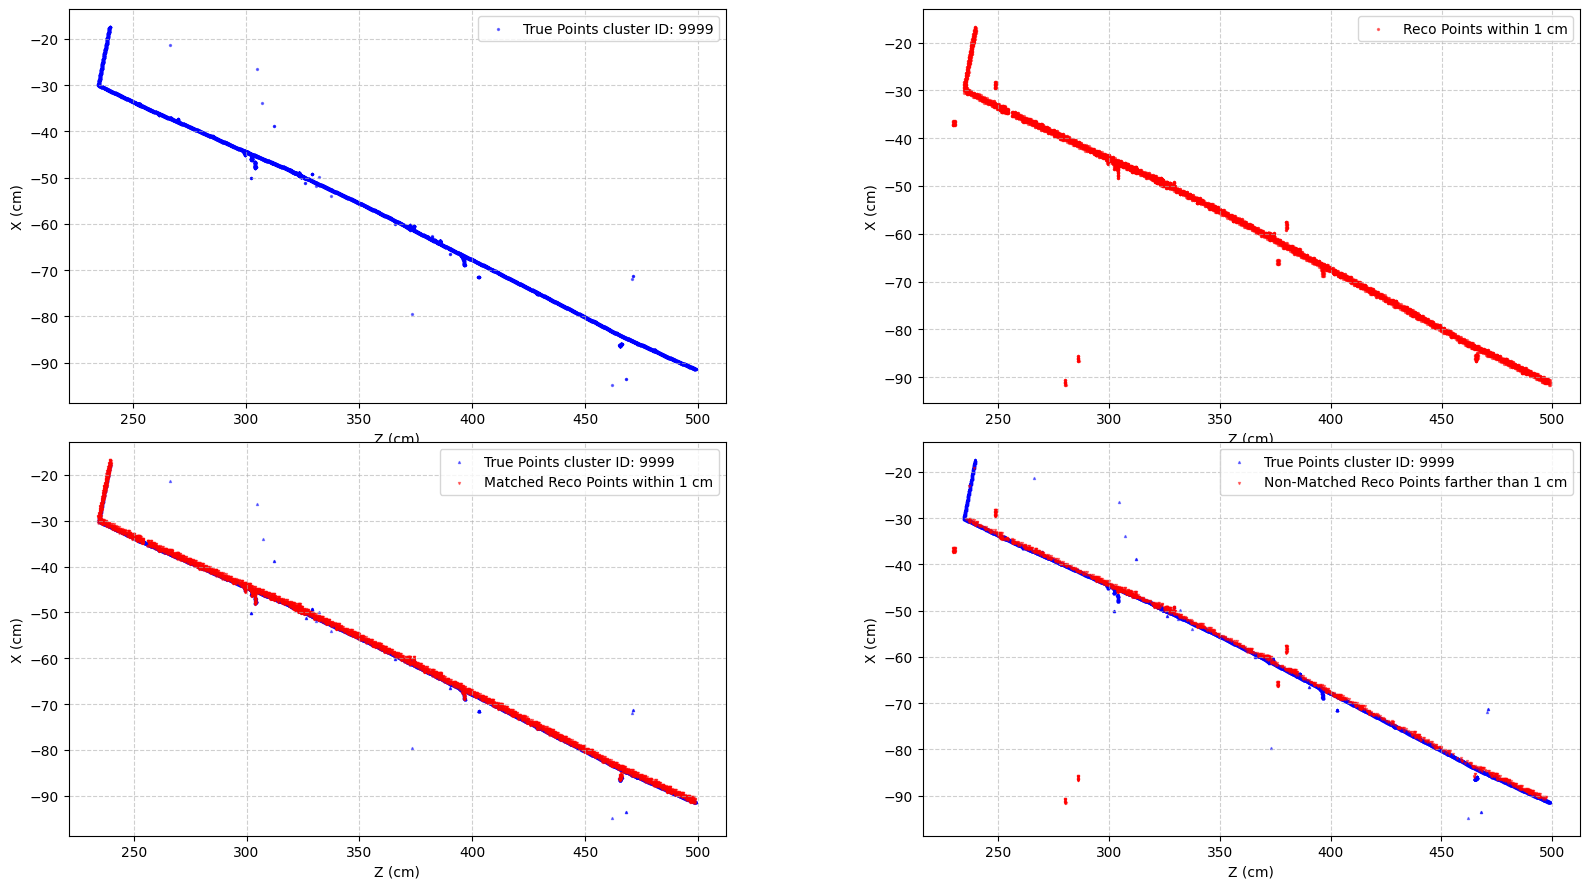

In [54]:
# lets shift reco points by 0.5 cm in z directions and re-draw matched and non-matched points for 1 cm radius
# also recalculate purity for this cluster pair with shifted reco points and see how it changes with radius


marker_size = 2

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

# lets draw true cluster points, matched_reco_points and non matched reco points in side by side plots
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_cluster = reco_cluster.copy()  # Create a copy to avoid modifying the original data
reco_cluster[:, 2] = reco_cluster[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

# find matched reco points
true_tree = KDTree(true_cluster[:, :3])
distances, indices = true_tree.query(reco_cluster[:, :3], k=1)
matched_reco_points = reco_cluster[distances <= radius]
nonmatched_reco_points = reco_cluster[distances > radius]
plt.figure(figsize=(16, 9))
plt.subplot(2, 2, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(2, 2, 2)
plt.scatter(reco_cluster[:, 2], reco_cluster[:, 0], s=marker_size, marker='o', color='red', alpha=0.5, label=f'Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(2, 2, 3)
# both true and non-matched reco points together
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], marker='^', s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(matched_reco_points[:, 2], matched_reco_points[:, 0], marker='v', s=marker_size, color='red', alpha=0.5, label=f'Matched Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
#both true and non-matched reco points together
plt.subplot(2, 2, 4)
plt.scatter(true_cluster[:, 2], true_cluster[:, 0], marker='^', s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 0],  marker='v', s=marker_size, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("X (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplots_adjust(wspace=0.3, hspace=0.1)
# plt.show(block=False)



Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


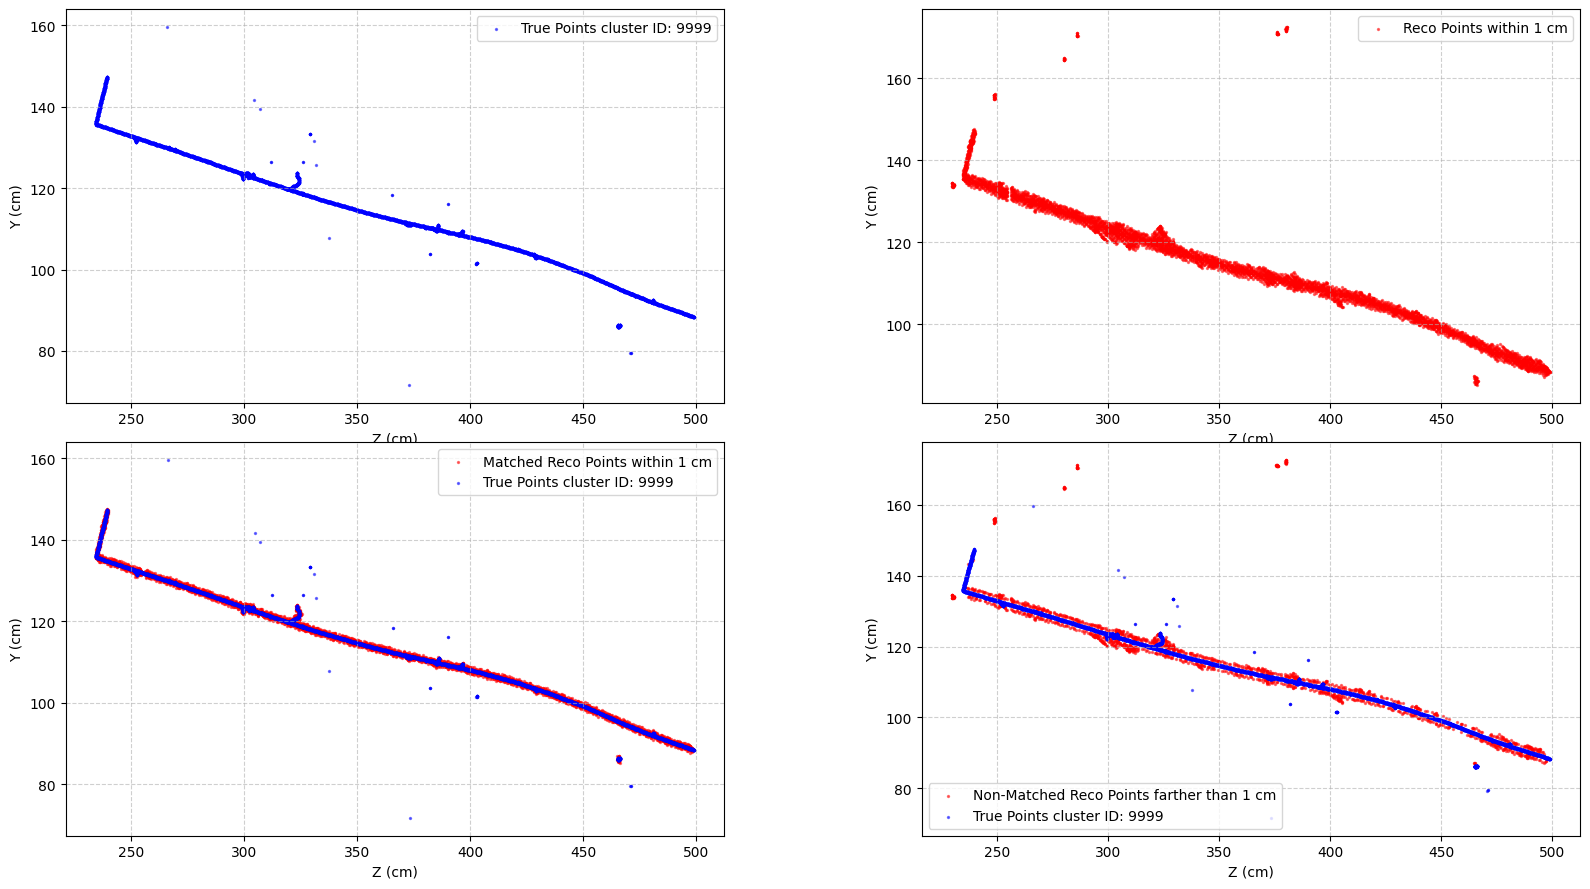

In [55]:
# lets draw in Y-Z plane for the same cluster pair

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")

# lets draw true cluster points, matched_reco_points and non matched reco points in side by side plots
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_cluster = reco_cluster.copy()  # Create a copy to avoid modifying the original data
reco_cluster[:, 2] = reco_cluster[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

# find matched reco points
true_tree = KDTree(true_cluster[:, :3])
distances, indices = true_tree.query(reco_cluster[:, :3], k=1)
matched_reco_points = reco_cluster[distances <= radius]
nonmatched_reco_points = reco_cluster[distances > radius]
plt.figure(figsize=(16, 9))
plt.subplot(2, 2, 1)
plt.scatter(true_cluster[:, 2], true_cluster[:, 1], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("Y (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(2, 2, 2)
plt.scatter(reco_cluster[:, 2], reco_cluster[:, 1], s=marker_size, marker='o', color='red', alpha=0.5, label=f'Reco Points within {radius} cm')
plt.xlabel("Z (cm)")
plt.ylabel("Y (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(2, 2, 3)
# both true and non-matched reco points together
plt.scatter(matched_reco_points[:, 2], matched_reco_points[:, 1], s=marker_size, color='red', alpha=0.5, label=f'Matched Reco Points within {radius} cm')
plt.scatter(true_cluster[:, 2], true_cluster[:, 1], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("Y (cm)")
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
#both true and non-matched reco points together
plt.subplot(2, 2, 4)
plt.scatter(nonmatched_reco_points[:, 2], nonmatched_reco_points[:, 1], s=marker_size, color='red', alpha=0.5, label=f'Non-Matched Reco Points farther than {radius} cm')
plt.scatter(true_cluster[:, 2], true_cluster[:, 1], s=marker_size, color='blue', alpha=0.5, label=f'True Points cluster ID: {true_cluster_id:2.4g}')
plt.xlabel("Z (cm)")
plt.ylabel("Y (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplots_adjust(wspace=0.3, hspace=0.1)
# plt.show(block=False)

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


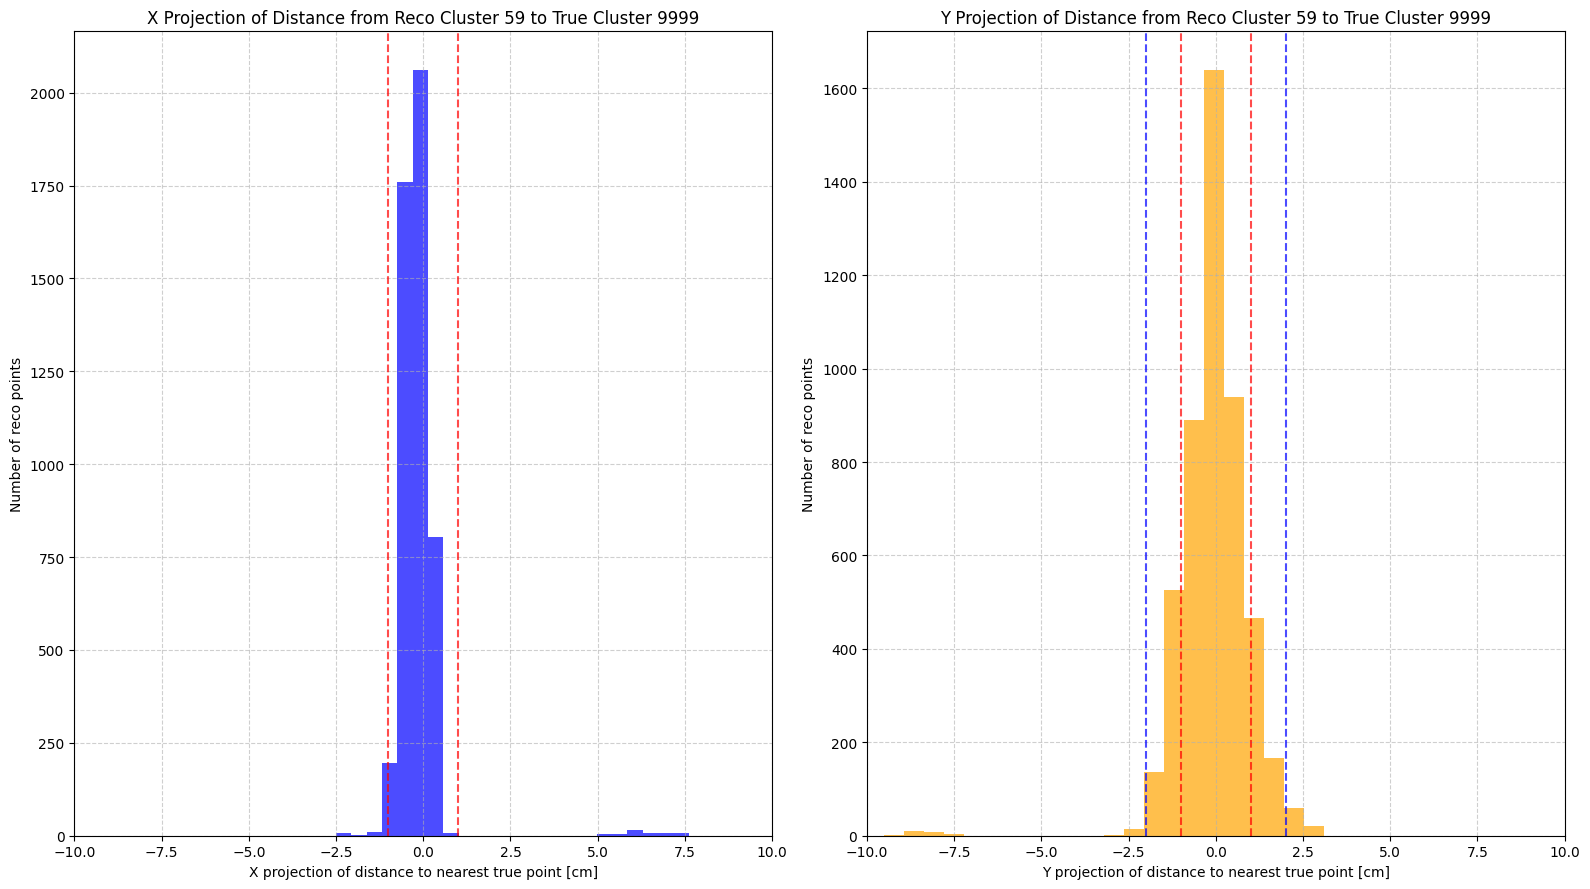

In [56]:
# for the above cluster pair, lets draw the x value of the distance between reco and their nearest true point also calculate how many reco points have x values for different ranges of this distance
# Calculate the x value of the distance between reco points and their nearest true point
true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_points = reco_cluster[:, :3]
reco_points[:, 2] = reco_points[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction
true_points = true_cluster[:, :3]
true_tree = KDTree(true_points)
distances, indices = true_tree.query(reco_points, k=1)
nearest_points = true_points[indices]
x_projection = nearest_points[:, 0] - reco_points[:, 0]
y_projection = nearest_points[:, 1] - reco_points[:, 1]
# Now draw both the x and y projections of distances
plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)
plt.hist(x_projection, bins=100, color='blue', alpha=0.7)
plt.xlabel("X projection of distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"X Projection of Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-10, 10)
# draw dotted lines on both +1 and -1 cm of 0 x value
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=-1, color='red', linestyle='--', alpha=0.7)
plt.subplot(1, 2, 2)
plt.hist(y_projection, bins=100, color='orange', alpha=0.7)
plt.xlabel("Y projection of distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"Y Projection of Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.xlim(-10, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=-1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=2, color='blue', linestyle='--', alpha=0.7)
plt.axvline(x=-2, color='blue', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.show(block=False)



In [57]:
# lets re-calculate purity for above clusters by applying two distance cuts, 1 cm on x-projection and 2 cm on y-projection of the distance between reco points and their nearest true point
# Calculate the x and y projection of the distance between reco points and their nearest true point
true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_points = reco_cluster[:, :3]
reco_points[:, 2] = reco_points[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction
true_points = true_cluster[:, :3]
true_tree = KDTree(true_points)
distances, indices = true_tree.query(reco_points, k=1)
nearest_points = true_points[indices]
x_projection = nearest_points[:, 0] - reco_points[:, 0]
y_projection = nearest_points[:, 1] - reco_points[:, 1]
# Apply the distance cuts
matched_reco_points = reco_points[(np.abs(x_projection) <= 1) & (np.abs(y_projection) <= 2)]
total_reco_points = len(reco_points)
purity = len(matched_reco_points) / total_reco_points if total_reco_points > 0 else 0
print(f"Purity for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g} with distance cuts: "
        f"Matched Reco Points = {len(matched_reco_points)} / {total_reco_points}, "
        f"Purity = {100*purity:.2f} %")

#also calculate how many reco points have y-projection between 1 and 2 cm, and beyond 2 cm
num_points_y_beyond_1 = np.sum(np.abs(y_projection) > 1)
num_points_y_beyond_2 = np.sum(np.abs(y_projection) > 2)
print(f"Number of reco points with y-projection beyond 1 cm: {num_points_y_beyond_1} / {total_reco_points} = {num_points_y_beyond_1/total_reco_points*100:.2f}% of the reco points in this cluster")
print(f"Number of reco points with y-projection beyond 2 cm: {num_points_y_beyond_2} / {total_reco_points} = {num_points_y_beyond_2/total_reco_points*100:.2f}% of the reco points in this cluster")

# also calculate how many reco points have x-projection between 1 and 2 cm, and beyond 2 cm
num_points_x_beyond_1 = np.sum(np.abs(x_projection) > 1)
num_points_x_beyond_2 = np.sum(np.abs(x_projection) > 2)
print(f"Number of reco points with x-projection beyond 1 cm: {num_points_x_beyond_1} / {total_reco_points} = {num_points_x_beyond_1/total_reco_points*100:.2f}% of the reco points in this cluster")
print(f"Number of reco points with x-projection beyond 2 cm: {num_points_x_beyond_2} / {total_reco_points} = {num_points_x_beyond_2/total_reco_points*100:.2f}% of the reco points in this cluster")

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59
Purity for Reco Cluster 59 and True Cluster 9999 with distance cuts: Matched Reco Points = 4737 / 4942, Purity = 95.85 %
Number of reco points with y-projection beyond 1 cm: 1182 / 4942 = 23.92% of the reco points in this cluster
Number of reco points with y-projection beyond 2 cm: 167 / 4942 = 3.38% of the reco points in this cluster
Number of reco points with x-projection beyond 1 cm: 127 / 4942 = 2.57% of the reco points in this cluster
Number of reco points with x-projection beyond 2 cm: 99 / 4942 = 2.00% of the reco points in this cluster


Testing KDTree matching for True Cluster 9999 and Reco Cluster 59


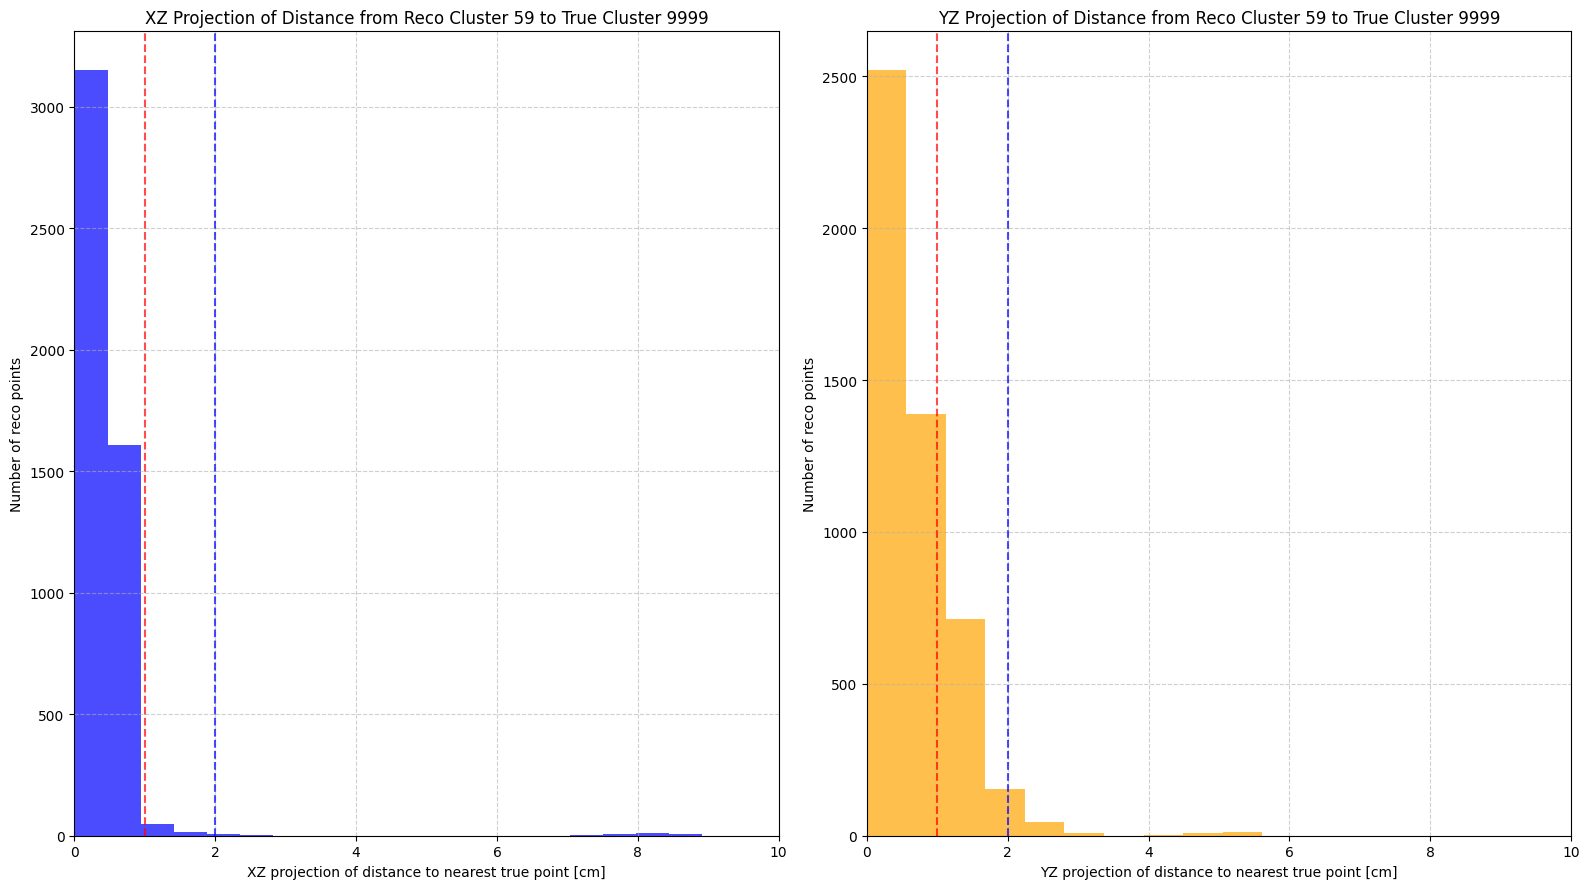

Number of reco points with xz-projection beyond 1 cm: 173 / 4942 = 3.50% of the reco points in this cluster
Number of reco points with xz-projection beyond 2 cm: 117 / 4942 = 2.37% of the reco points in this cluster
Number of reco points with yz-projection beyond 1 cm: 1282 / 4942 = 25.94% of the reco points in this cluster
Number of reco points with yz-projection beyond 2 cm: 208 / 4942 = 4.21% of the reco points in this cluster


In [58]:
# for the above cluster pair, lets draw the xz and yz projections of the distance between reco and their nearest true point also calculate how many reco points have xz and yz values for different ranges of this distance

true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_points = reco_cluster[:, :3]
reco_points[:, 2] = reco_points[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction
true_points = true_cluster[:, :3]
true_tree = KDTree(true_points)
distances, indices = true_tree.query(reco_points, k=1)
nearest_points = true_points[indices]
xz_projection = np.sqrt((nearest_points[:, 0] - reco_points[:, 0])**2 + (nearest_points[:, 2] - reco_points[:, 2])**2)
yz_projection = np.sqrt((nearest_points[:, 1] - reco_points[:, 1])**2 + (nearest_points[:, 2] - reco_points[:, 2])**2)
# Now draw both the xz and yz projections of distances
plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)
plt.hist(xz_projection, bins=100, color='blue', alpha=0.7)
plt.xlabel("XZ projection of distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"XZ Projection of Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 10)
# draw dotted lines on both +1 and -1 cm of 0 x value
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=2, color='blue', linestyle='--', alpha=0.7)
plt.subplot(1, 2, 2)
plt.hist(yz_projection, bins=100, color='orange', alpha=0.7)
plt.xlabel("YZ projection of distance to nearest true point [cm]")
plt.ylabel("Number of reco points")
plt.title(f"YZ Projection of Distance from Reco Cluster {reco_cluster_id:2.4g} to True Cluster {true_cluster_id:2.4g}")
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=2, color='blue', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.show(block=False)

#also calculate how many reco points have xz-projection between 1 and 2 cm, and beyond 2 cm
num_points_xz_beyond_1 = np.sum(xz_projection > 1)
num_points_xz_beyond_2 = np.sum(xz_projection > 2)
print(f"Number of reco points with xz-projection beyond 1 cm: {num_points_xz_beyond_1} / {total_reco_points} = {num_points_xz_beyond_1/total_reco_points*100:.2f}% of the reco points in this cluster")
print(f"Number of reco points with xz-projection beyond 2 cm: {num_points_xz_beyond_2} / {total_reco_points} = {num_points_xz_beyond_2/total_reco_points*100:.2f}% of the reco points in this cluster")

#also calculate how many reco points have yz-projection between 1 and 2 cm, and beyond 2 cm
num_points_yz_beyond_1 = np.sum(yz_projection > 1)
num_points_yz_beyond_2 = np.sum(yz_projection > 2)
print(f"Number of reco points with yz-projection beyond 1 cm: {num_points_yz_beyond_1} / {total_reco_points} = {num_points_yz_beyond_1/total_reco_points*100:.2f}% of the reco points in this cluster")
print(f"Number of reco points with yz-projection beyond 2 cm: {num_points_yz_beyond_2} / {total_reco_points} = {num_points_yz_beyond_2/total_reco_points*100:.2f}% of the reco points in this cluster")



In [59]:
# lets re-calculate purity for above clusters by applying two distance cuts, 1 cm on xz projection and 2 cm on yz projection of the distance between reco points and their nearest true point
true_cluster_id = list(clusters_true.keys())[0]
reco_cluster_id = list(clusters_reco.keys())[2]
print(f"Testing KDTree matching for True Cluster {true_cluster_id:2.4g} and Reco Cluster {reco_cluster_id:2.4g}")
true_cluster = np.array(clusters_true[true_cluster_id])
reco_cluster = np.array(clusters_reco[reco_cluster_id])
reco_points = reco_cluster[:, :3]
reco_points[:, 2] = reco_points[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction
true_points = true_cluster[:, :3]
true_tree = KDTree(true_points)
distances, indices = true_tree.query(reco_points, k=1)
nearest_points = true_points[indices]
xz_projection = np.sqrt((nearest_points[:, 0] - reco_points[:, 0])**2 + (nearest_points[:, 2] - reco_points[:, 2])**2)
yz_projection = np.sqrt((nearest_points[:, 1] - reco_points[:, 1])**2 + (nearest_points[:, 2] - reco_points[:, 2])**2)
# Apply the distance cuts
matched_reco_points = reco_points[(xz_projection <= 1) & (yz_projection <= 2)]
total_reco_points = len(reco_points)
purity = len(matched_reco_points) / total_reco_points if total_reco_points > 0 else 0
print(f"Purity for Reco Cluster {reco_cluster_id:2.4g} and True Cluster {true_cluster_id:2.4g} with distance cuts: "
        f"Matched Reco Points = {len(matched_reco_points)} / {total_reco_points}, "
        f"Purity = {100*purity:.2f} %")

Testing KDTree matching for True Cluster 9999 and Reco Cluster 59
Purity for Reco Cluster 59 and True Cluster 9999 with distance cuts: Matched Reco Points = 4685 / 4942, Purity = 94.80 %


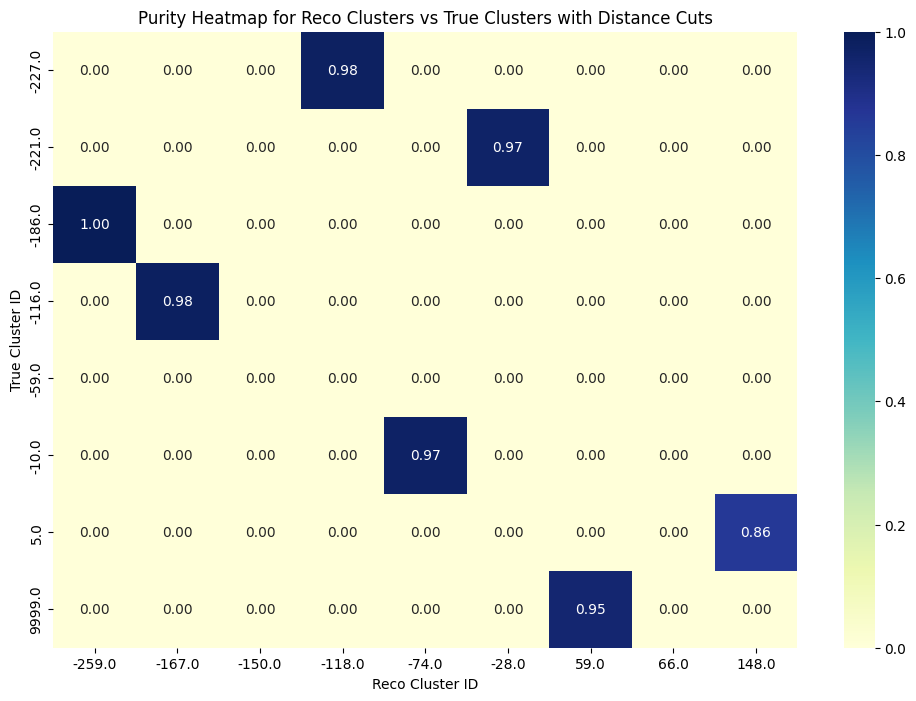

In [60]:
# Now lets calculate purity for each reco cluster and make a heatmap of purity values for all true and reco cluster pairs
# Create a list to store purity results for each reco cluster
purity_results = []
min_recopoints_threshold = 1  # Minimum number of true points within the radius to consider a reco point as matched

# Loop over each reco cluster
for reco_cluster_id, reco_points in clusters_reco.items():
    reco_points = np.array(reco_points)
    reco_coords = reco_points[:, :3]
    reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

    # loop over each true cluster
    for true_cluster_id, true_points in clusters_true.items():
        true_points = np.array(true_points)
        true_coords = true_points[:, :3]

        # Build KDTree for the true cluster
        true_tree = KDTree(true_coords)

        # Query the KDTree with the predicted points to find nearest true point
        distances, indices = true_tree.query(reco_coords, k=1)

        nearest_points = true_coords[indices]
        xz_projection = np.sqrt((nearest_points[:, 0] - reco_coords[:, 0])**2 + (nearest_points[:, 2] - reco_coords[:, 2])**2)
        yz_projection = np.sqrt((nearest_points[:, 1] - reco_coords[:, 1])**2 + (nearest_points[:, 2] - reco_coords[:, 2])**2)

        # Apply distance cuts to determine matched reco points
        matched_reco_points = reco_coords[(xz_projection <= 1) & (yz_projection <= 2)]
        total_reco_points = len(reco_coords)
        purity = len(matched_reco_points) / total_reco_points if total_reco_points > 0 else 0

        # Store the purity result for this cluster pair
        purity_results.append({
            'reco_cluster_id': reco_cluster_id,
            'true_cluster_id': true_cluster_id,
            'matched_reco_points': len(matched_reco_points),
            'total_reco_points': total_reco_points,
            'purity': purity
        })
# Convert purity results to a DataFrame for easier analysis
purity_df = pd.DataFrame(purity_results)
# Create a pivot table for the heatmap
heatmap_data = purity_df.pivot(index='true_cluster_id', columns='reco_cluster_id', values='purity')
# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Purity Heatmap for Reco Clusters vs True Clusters with Distance Cuts")
plt.xlabel("Reco Cluster ID")
plt.ylabel("True Cluster ID")
# plt.show(block=False)

    


In [61]:
# lets re-pair true and reco clusters who have a purity value. We can then later use this true-reco pair for further analysis
# Filter out pairs with non-zero purity
matched_pairs = purity_df[purity_df['purity'] > 0]
# For each true cluster, find the reco cluster with the highest purity
best_matches = matched_pairs.loc[matched_pairs.groupby('true_cluster_id')['purity'].idxmax()]
# Display the best matches
print("Best True-Reco Cluster Matches based on Purity:")
print(best_matches[['true_cluster_id', 'reco_cluster_id', 'purity']])


Best True-Reco Cluster Matches based on Purity:
    true_cluster_id  reco_cluster_id    purity
49           -227.0           -118.0  0.980061
12           -221.0            -28.0  0.965686
62           -186.0           -259.0  1.000000
34           -116.0           -167.0  0.983457
23            -59.0             59.0  0.003845
27            -10.0            -74.0  0.972348
45              5.0            148.0  0.860558
16           9999.0             59.0  0.947997


In [62]:
# for above pairs get the efficiencies
# Create a list to store efficiency results for each matched pair
efficiency_results = []
# Loop over each matched pair to calculate efficiency
for _, row in best_matches.iterrows():
    true_cluster_id = row['true_cluster_id']
    reco_cluster_id = row['reco_cluster_id']
    true_points = np.array(clusters_true[true_cluster_id])
    reco_points = np.array(clusters_reco[reco_cluster_id])
    true_coords = true_points[:, :3]
    reco_coords = reco_points[:, :3]
    reco_coords[:, 2] = reco_coords[:, 2] + 0.5  # Shift reco points by 0.5 cm in z direction

    # Build KDTree for the predicted cluster
    reco_tree = KDTree(reco_coords)

    # Query the KDTree with the true points to find nearest neighbors
    indices = reco_tree.query_ball_point(true_coords, r=knn_dist_threshold)  # Find all neighbors within radius

    # Count the number of neighbors for each true point
    num_neighbors = [len(neighbors) for neighbors in indices]

    # Check how many true points are within the radius of any predicted point
    matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold) 
    total_true_points = len(true_points)
    efficiency = matched_true_points / total_true_points if total_true_points > 0 else 0

    efficiency_results.append({
        'true_cluster_id': true_cluster_id,
        'reco_cluster_id': reco_cluster_id,
        'matched_true_points': matched_true_points,
        'total_true_points': total_true_points,
        'efficiency': efficiency
    })
# Convert efficiency results to a DataFrame for easier analysis
efficiency_df = pd.DataFrame(efficiency_results)
# Display the efficiency results
print("Efficiency for Best True-Reco Cluster Matches:")
print(efficiency_df[['true_cluster_id', 'reco_cluster_id', 'efficiency']])


Efficiency for Best True-Reco Cluster Matches:
   true_cluster_id  reco_cluster_id  efficiency
0           -227.0           -118.0    0.987837
1           -221.0            -28.0    0.850374
2           -186.0           -259.0    0.998740
3           -116.0           -167.0    0.955824
4            -59.0             59.0    1.000000
5            -10.0            -74.0    0.996915
6              5.0            148.0    0.978555
7           9999.0             59.0    0.995442


Performance Dictionary for True-Reco Cluster Pairs:
   true_cluster_id  reco_cluster_id    purity  efficiency
0           -227.0           -118.0  0.980061    0.987837
1           -221.0            -28.0  0.965686    0.850374
2           -186.0           -259.0  1.000000    0.998740
3           -116.0           -167.0  0.983457    0.955824
4            -59.0             59.0  0.003845    1.000000
5            -10.0            -74.0  0.972348    0.996915
6              5.0            148.0  0.860558    0.978555
7           9999.0             59.0  0.947997    0.995442


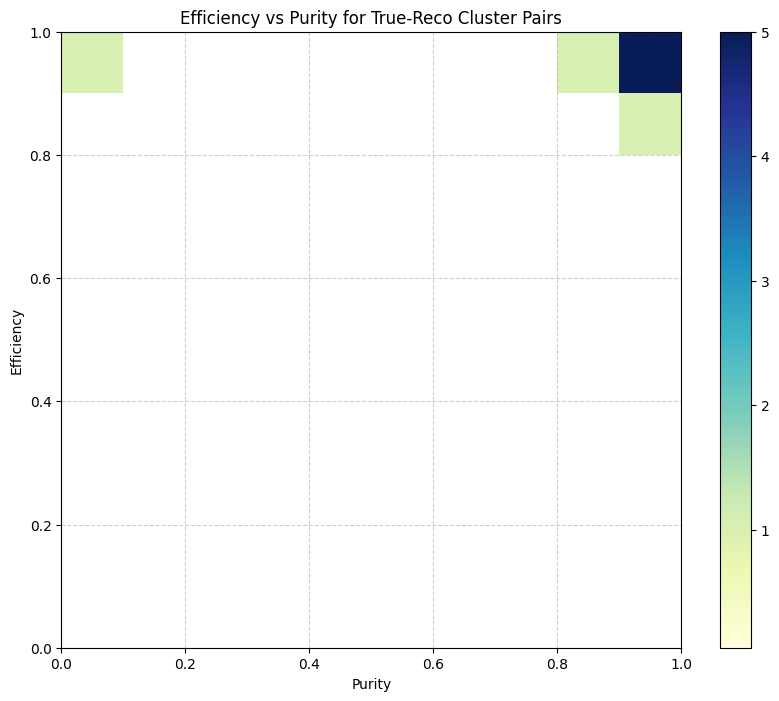

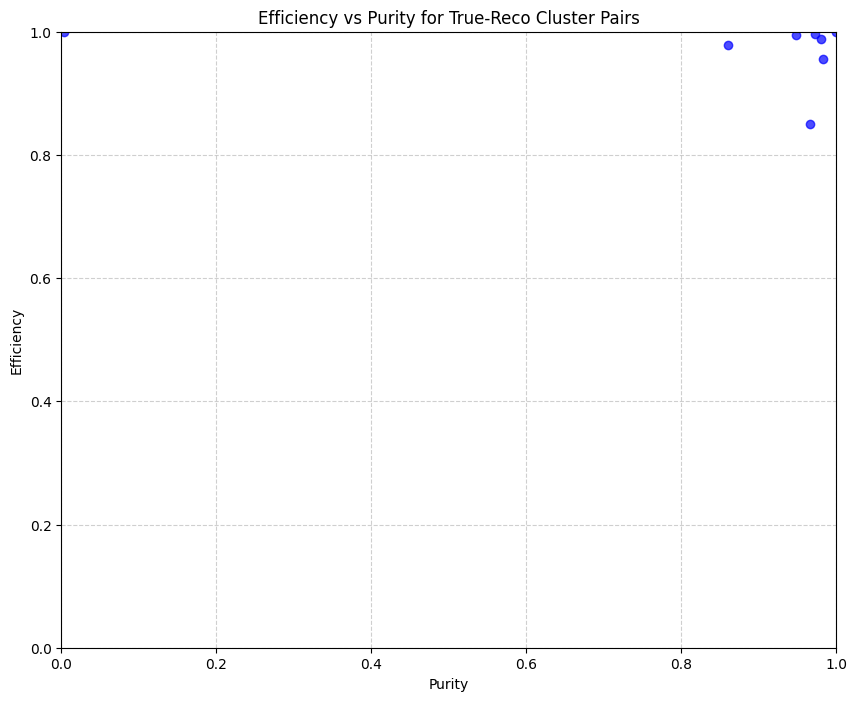

In [63]:
# lets associate and save efficiency and purity values for each true-reco pair in a dictionary for later use
# Create a dictionary to store efficiency and purity for each true-reco pair
performance_dict = {}
# Loop over each matched pair to fill the performance dictionary
for _, row in best_matches.iterrows():
    true_cluster_id = row['true_cluster_id']
    reco_cluster_id = row['reco_cluster_id']
    purity = row['purity']
    efficiency_row = efficiency_df[(efficiency_df['true_cluster_id'] == true_cluster_id) & (efficiency_df['reco_cluster_id'] == reco_cluster_id)]
    if not efficiency_row.empty:
        efficiency = efficiency_row.iloc[0]['efficiency']
        performance_dict[(true_cluster_id, reco_cluster_id)] = {
            'purity': purity,
            'efficiency': efficiency
        }
# Display the performance dictionary
print("Performance Dictionary for True-Reco Cluster Pairs:")
# Convert efficiency and purity results to a DataFrame for easier prints
performance_df = pd.DataFrame([{
    'true_cluster_id': key[0],
    'reco_cluster_id': key[1],
    'purity': value['purity'],
    'efficiency': value['efficiency']
} for key, value in performance_dict.items()])
print(performance_df[['true_cluster_id', 'reco_cluster_id', 'purity', 'efficiency']])

# now lets draw 2D efficiency vs purity plot for these pairs. Not has a scatter plot but as a col histogram where x-axis is purity, y-axis is efficiency and color is number of pairs in that bin of purity and efficiency
plt.figure(figsize=(10, 8))
cmap = plt.cm.YlGnBu.copy()
cmap.set_under('white')
plt.hist2d(performance_df['purity'], performance_df['efficiency'], bins=[10, 10], range=[[0,1],[0,1]], cmap=cmap, vmin=0.05)
plt.xlabel('Purity')
plt.ylabel('Efficiency')
plt.xlim(0.0, 1)
plt.ylim(0.0, 1)
plt.title('Efficiency vs Purity for True-Reco Cluster Pairs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar()
# plt.show(block=False)

plt.figure(figsize=(10, 8))
plt.scatter(performance_df['purity'], performance_df['efficiency'], color='blue', alpha=0.7)
plt.xlabel('Purity')
plt.ylabel('Efficiency')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Efficiency vs Purity for True-Reco Cluster Pairs')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show(block=False)





In [64]:
# lets calculate how many true clusters are reconstructed with at least 80% purity and 80% efficiency
# Define thresholds for purity and efficiency
purity_threshold = 0.8
efficiency_threshold = 0.8
# Filter the performance DataFrame based on the thresholds
high_quality_pairs = performance_df[(performance_df['purity'] >= purity_threshold) & (performance_df['efficiency'] >= efficiency_threshold)]
# Count the number of unique true clusters that meet the criteria
num_high_quality_true_clusters = high_quality_pairs['true_cluster_id'].nunique()
print(f"Number of true clusters reconstructed with at least {purity_threshold*100:.0f}% purity and {efficiency_threshold*100:.0f}% efficiency: {num_high_quality_true_clusters}")

# what is the fraction of true clusters that are reconstructed with at least 80% purity and 80% efficiency
total_true_clusters = performance_df['true_cluster_id'].nunique()
fraction_high_quality = num_high_quality_true_clusters / total_true_clusters if total_true_clusters > 0 else 0
print(f"{100*fraction_high_quality:.2f}% clusters are reconstructed with at least {purity_threshold*100:.0f}% purity and {efficiency_threshold*100:.0f}% efficiency:")

# lets re-caluculate the above for same purity and efficiency threshold
# Define thresholds for purity and efficiency
purity_threshold = 0.9
efficiency_threshold = 0.9
# Filter the performance DataFrame based on the thresholds
high_quality_pairs = performance_df[(performance_df['purity'] >= purity_threshold) & (performance_df['efficiency'] >= efficiency_threshold)]
# Count the number of unique true clusters that meet the criteria
num_high_quality_true_clusters = high_quality_pairs['true_cluster_id'].nunique()
print(f"Number of true clusters reconstructed with at least {purity_threshold*100:.0f}% purity and {efficiency_threshold*100:.0f}% efficiency: {num_high_quality_true_clusters}")
# what is the fraction of true clusters that are reconstructed with at least 90% purity and 90% efficiency
total_true_clusters = performance_df['true_cluster_id'].nunique()
fraction_high_quality = num_high_quality_true_clusters / total_true_clusters if total_true_clusters > 0 else 0
print(f"{100*fraction_high_quality:.2f}% clusters are reconstructed with at least {purity_threshold*100:.0f}% purity and {efficiency_threshold*100:.0f}% efficiency:")


Number of true clusters reconstructed with at least 80% purity and 80% efficiency: 7
87.50% clusters are reconstructed with at least 80% purity and 80% efficiency:
Number of true clusters reconstructed with at least 90% purity and 90% efficiency: 5
62.50% clusters are reconstructed with at least 90% purity and 90% efficiency:


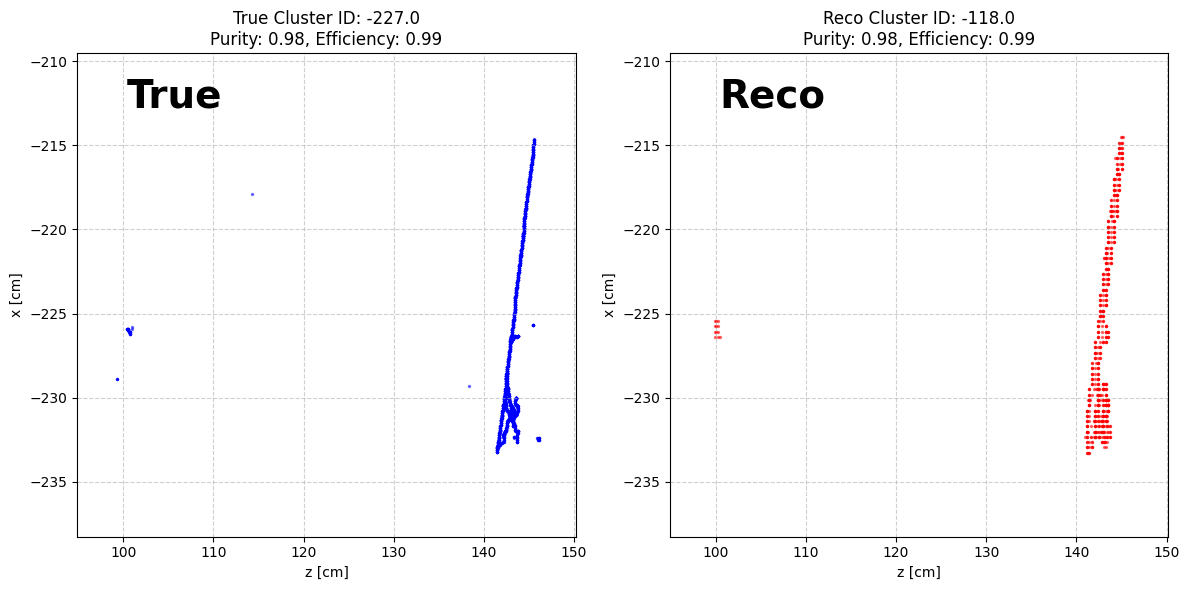

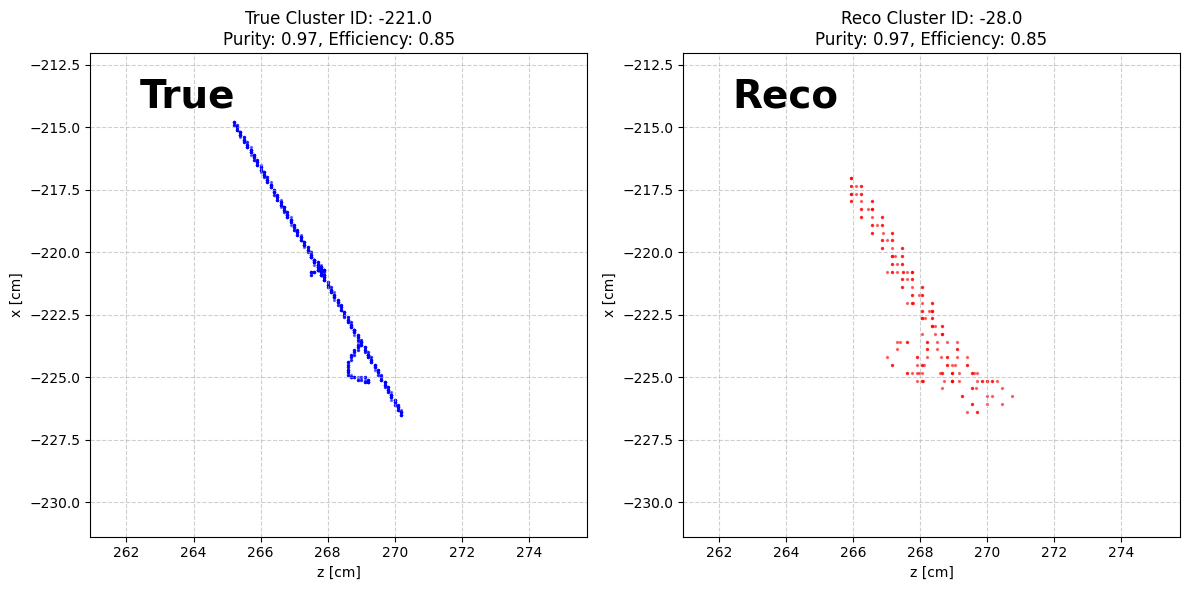

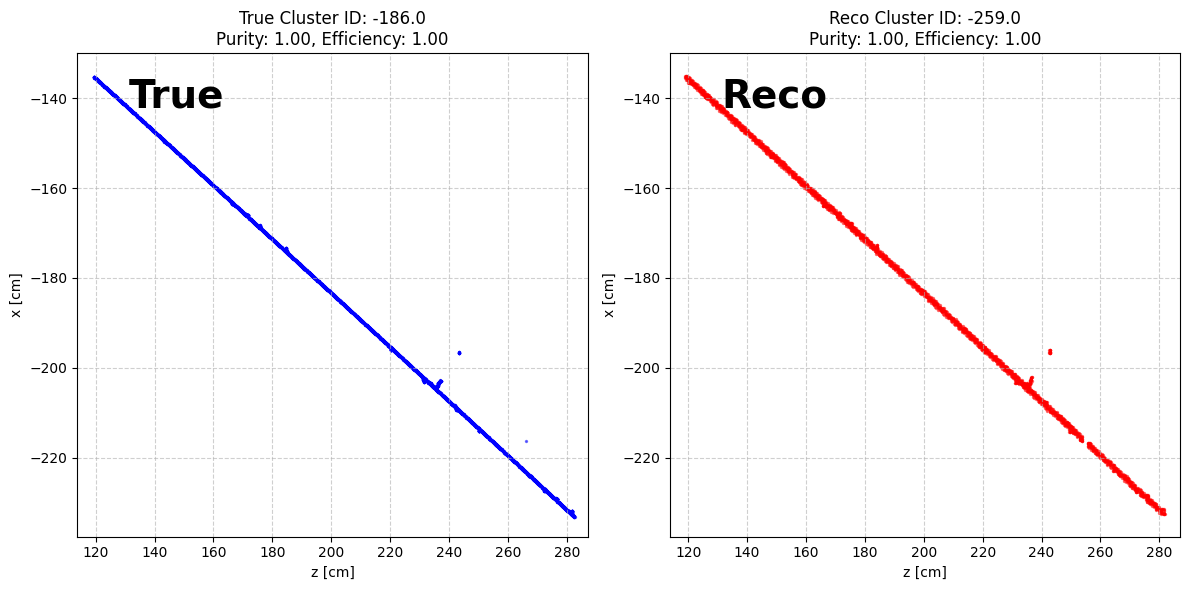

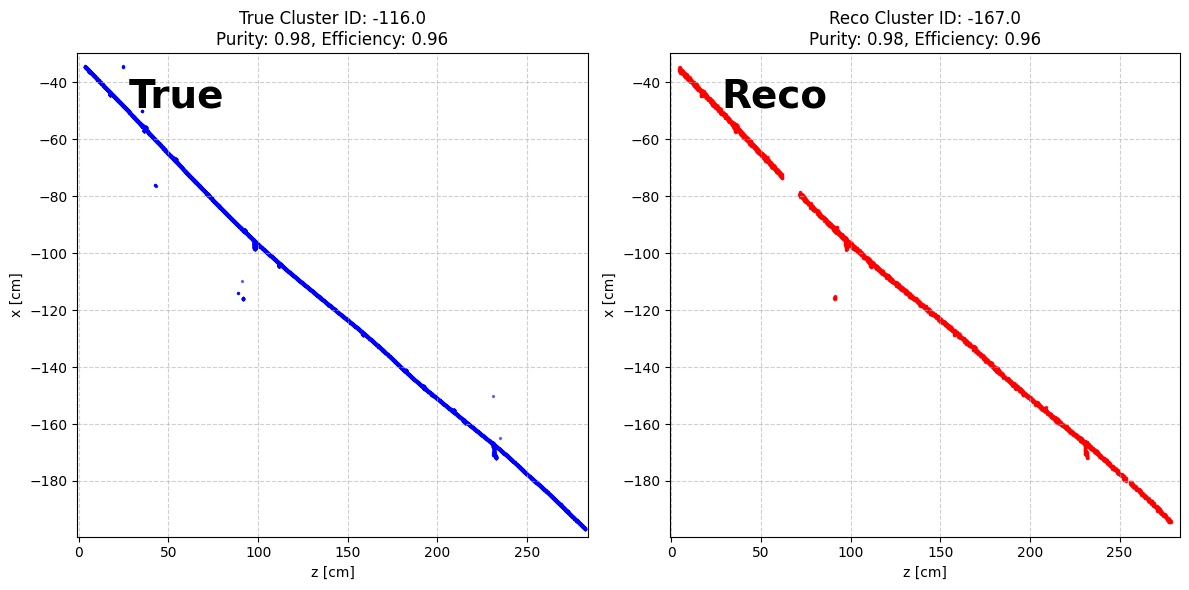

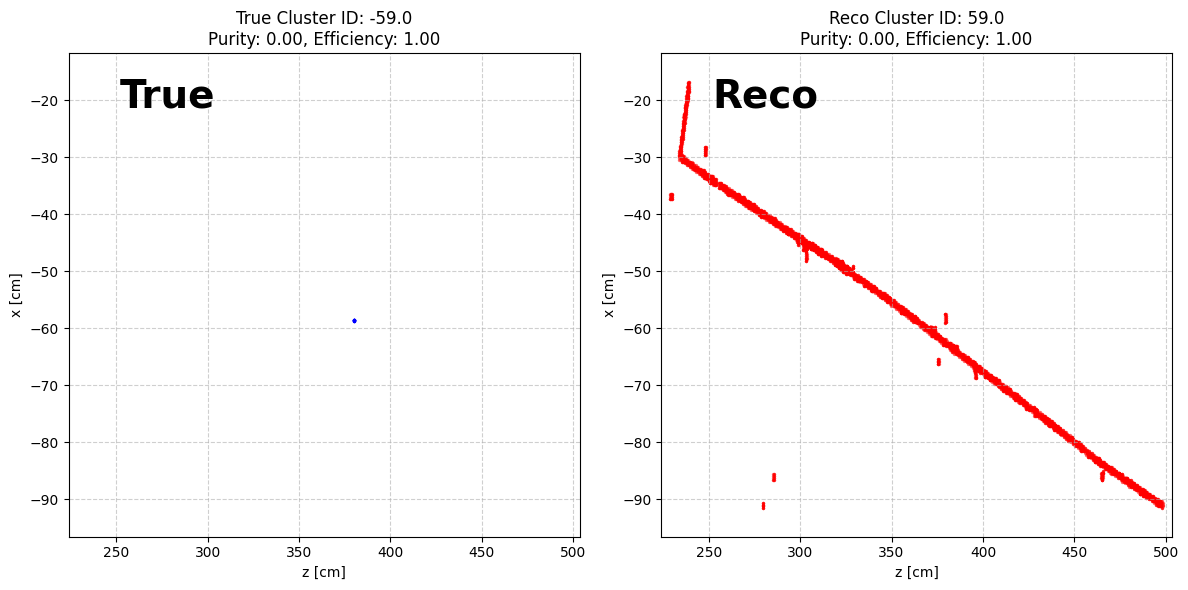

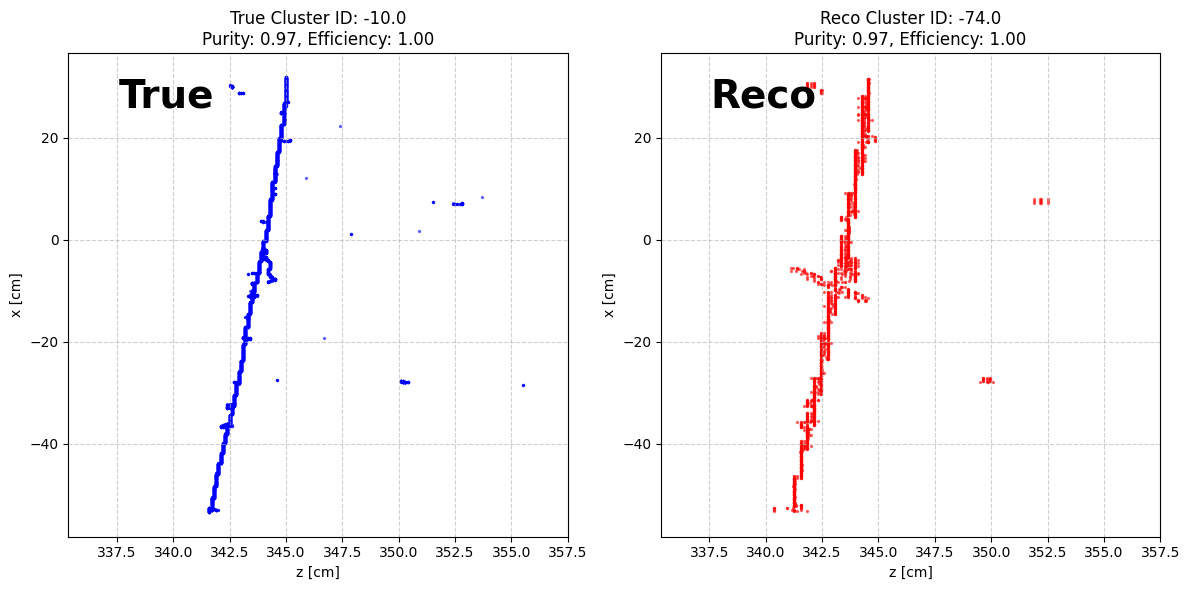

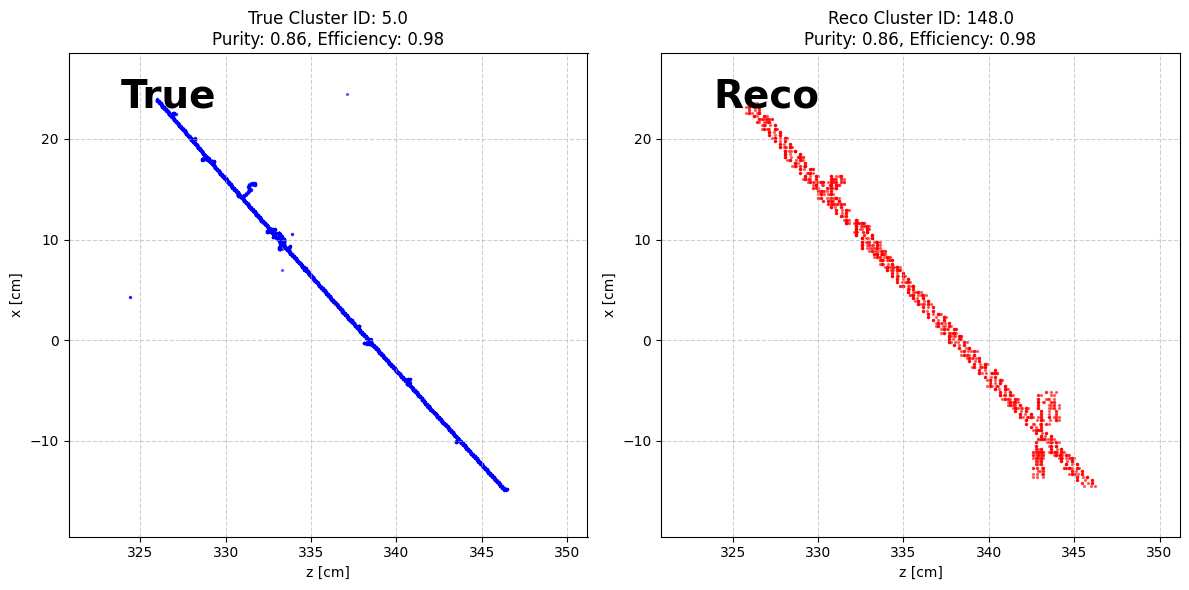

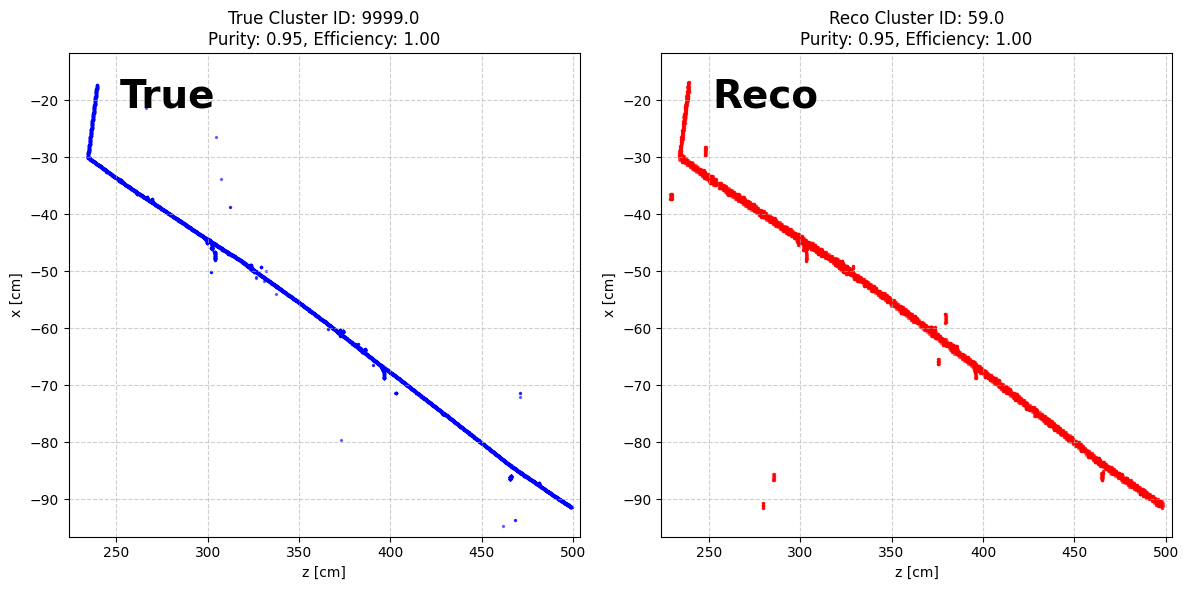

In [65]:
# lets draw each true-reco pair in side by side plots with their efficiency and purity in the title of the plot to visually compare them
# Loop over each matched pair to draw side-by-side plots
for _, row in best_matches.iterrows():
    true_cluster_id = row['true_cluster_id']
    reco_cluster_id = row['reco_cluster_id']
    purity = row['purity']
    efficiency_row = efficiency_df[(efficiency_df['true_cluster_id'] == true_cluster_id) & (efficiency_df['reco_cluster_id'] == reco_cluster_id)]
    if not efficiency_row.empty:
        efficiency = efficiency_row.iloc[0]['efficiency']
        true_points = np.array(clusters_true[true_cluster_id])
        reco_points = np.array(clusters_reco[reco_cluster_id])
        # Create side-by-side plots
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        # True cluster plot
        axes[0].scatter(true_points[:, 2], true_points[:, 0], s=marker_size, color='blue', alpha=0.5)
        # let's write large True label on the true cluster plot and large Reco label on the reco cluster plot
        axes[0].text(0.10, 0.95, "True", transform=axes[0].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
        axes[0].set_title(f'True Cluster ID: {true_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
        axes[0].set_xlabel('z [cm]')
        axes[0].set_ylabel('x [cm]')
        axes[0].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
        axes[0].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
        axes[0].grid(True, linestyle='--', alpha=0.6)
        # Reco cluster plot
        axes[1].scatter(reco_points[:, 2], reco_points[:, 0], s=marker_size, color='red',alpha=0.5)
        axes[1].text(0.10, 0.95, "Reco", transform=axes[1].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
        axes[1].set_title(f'Reco Cluster ID: {reco_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
        axes[1].set_xlabel('z [cm]')
        axes[1].set_ylabel('x [cm]')
        axes[1].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
        axes[1].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
        axes[1].grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        # plt.show(block=False)

In [66]:
# Lets draw a specific cluster to demonstrate performance of wirecell fiducial selection

print("Testing performance of the wirecell fiducial selections")

true_cluster_id = -189
reco_cluster_id = -67

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])

# purity and efficiency for this pair
purity = performance_dict.get((true_cluster_id, reco_cluster_id), {}).get('purity', 0)
efficiency = performance_dict.get((true_cluster_id, reco_cluster_id), {}).get('efficiency', 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# True cluster plot
axes[0].scatter(true_points[:, 2], true_points[:, 0], s=marker_size, color='blue', alpha=0.5)
# let's write large True label on the true cluster plot and large Reco label on the reco cluster plot
axes[0].text(0.10, 0.95, "True", transform=axes[0].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
axes[0].set_title(f'True Cluster ID: {true_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
axes[0].set_xlabel('z [cm]')
axes[0].set_ylabel('x [cm]')
axes[0].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
axes[0].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
axes[0].grid(True, linestyle='--', alpha=0.6)
# Reco cluster plot
axes[1].scatter(reco_points[:, 2], reco_points[:, 0], s=marker_size, color='red',alpha=0.5)
axes[1].text(0.10, 0.95, "Reco", transform=axes[1].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
axes[1].set_title(f'Reco Cluster ID: {reco_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
axes[1].set_xlabel('z [cm]')
axes[1].set_ylabel('x [cm]')
axes[1].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
axes[1].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show(block=False)


Testing performance of the wirecell fiducial selections


KeyError: -189

Y min:  -203.3
Y max:  200.5
Z min:  4.7
Z max:  500.6
shape of true points before fiducial selection:  (6506, 7)
shape of true points after fiducial selection:  (5892, 7)
shape of reco points before fiducial selection:  (2455, 5)
shape of reco points after fiducial selection:  (2452, 5)
shape of true points after fiducial selection:  (5892, 3)
shape of reco points after fiducial selection:  (2452, 3)
Purity after fiducial selection: 0.72, Efficiency after fiducial selection: 1.00


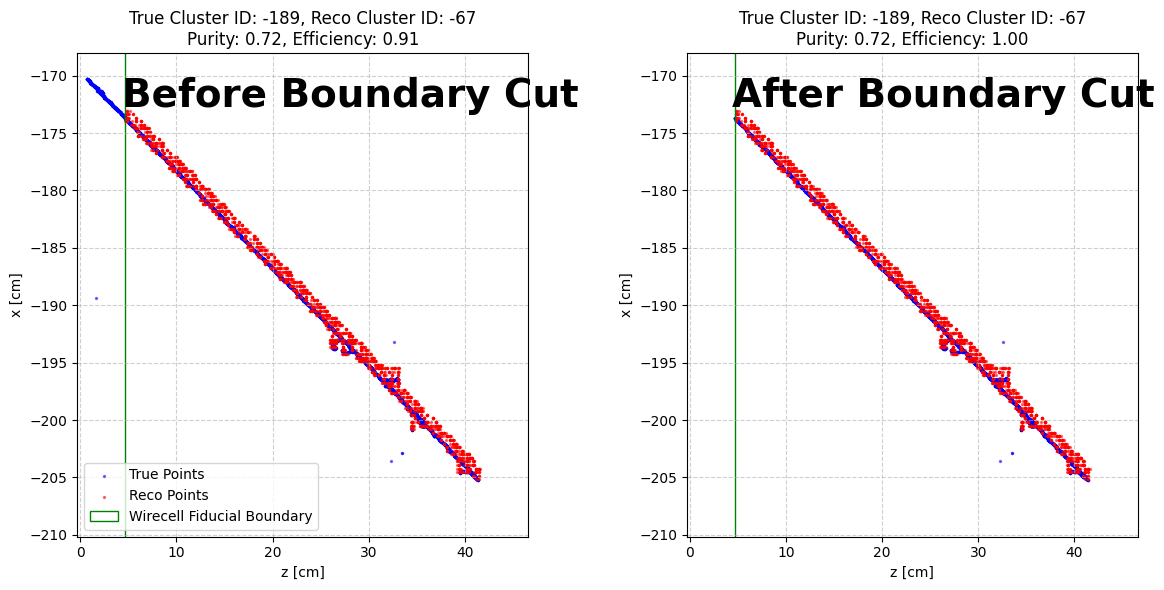

In [ ]:
# Lets redraw above true cluster before and after fiducial selection
true_cluster_id = -189
reco_cluster_id = -67

x_min=-250
x_max=250
y_min=-203.3
y_max=200.5
z_min=4.7
z_max=500.6


width_z_boundary=z_max-z_min
height_y_boundary=y_max-y_min
height_x_boundary=x_max-x_min

print("Y min: ", y_min)
print("Y max: ", y_max)
print("Z min: ", z_min)
print("Z max: ", z_max)

true_points = np.array(clusters_true[true_cluster_id])
reco_points = np.array(clusters_reco[reco_cluster_id])
reco_coords = reco_points[:, :3] 
reco_coords[:, 2] = reco_coords[:, 2] + 0.5

# define a boundary rectangle using x, y coordinates of four corners
from matplotlib.patches import Rectangle
rect = Rectangle((z_min, x_min), width_z_boundary, height_x_boundary,
                 edgecolor='green',
                 facecolor='none', label ='Wirecell Fiducial Boundary')

rect_copy = Rectangle((z_min, x_min), width_z_boundary, height_x_boundary,
                 edgecolor='green',
                 facecolor='none', label ='Wirecell Fiducial Boundary')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# True cluster plot
axes[0].scatter(true_points[:, 2], true_points[:, 0], s=marker_size, color='blue', alpha=0.5, label='True Points')
axes[0].scatter(reco_points[:, 2], reco_points[:, 0], s=marker_size, color='red', alpha=0.5, label ='Reco Points')
# let's write large True label on the true cluster plot and large Reco label on the reco cluster plot
axes[0].set_title(f'True Cluster ID: {true_cluster_id}, Reco Cluster ID: {reco_cluster_id}\nPurity: {purity:.2f}, Efficiency: {efficiency:.2f}')
axes[0].text(0.10, 0.95, "Before Boundary Cut", transform=axes[0].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
axes[0].set_xlabel('z [cm]')
axes[0].set_ylabel('x [cm]')
axes[0].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
axes[0].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].add_patch(rect)
axes[0].legend(loc='best')

# For this pair lets recalculate purity and efficiency after applying the wirecell fiducial selection
# Apply wirecell fiducial selection
# only keep points that are within the boundary defined by x_min, x_max, y_min, y_max, z_min and z_max
true_points_filtered = true_points[
    (true_points[:, 0] >= x_min) & (true_points[:, 0] <= x_max) &
    (true_points[:, 1] >= y_min) & (true_points[:, 1] <= y_max) &
    (true_points[:, 2] >= z_min) & (true_points[:, 2] <= z_max)
]
print("shape of true points before fiducial selection: ", true_points.shape)
print("shape of true points after fiducial selection: ", true_points_filtered.shape)

reco_points_filtered = reco_points[
    (reco_points[:, 0] >= x_min) & (reco_points[:, 0] <= x_max) &
    (reco_points[:, 1] >= y_min) & (reco_points[:, 1] <= y_max) &
    (reco_points[:, 2] >= z_min) & (reco_points[:, 2] <= z_max)
]
print("shape of reco points before fiducial selection: ", reco_points.shape)
print("shape of reco points after fiducial selection: ", reco_points_filtered.shape)

reco_points_filtered = np.array(reco_points_filtered)
reco_points_filtered = reco_points_filtered[:, :3]

true_points_filtered = np.array(true_points_filtered) 
true_points_filtered = true_points_filtered[:, :3]

print("shape of true points after fiducial selection: ", true_points_filtered.shape)
print("shape of reco points after fiducial selection: ", reco_points_filtered.shape)

# calculate efficiency first
# Build KDTree for the predicted cluster
reco_tree = KDTree(reco_points_filtered)
# Query the KDTree with the true points to find nearest neighbors
indices = reco_tree.query_ball_point(true_points_filtered, r=knn_dist_threshold)  # Find all neighbors within radius
# Count the number of neighbors for each true point
num_neighbors = [len(neighbors) for neighbors in indices]
# Check how many true points are within the radius of any predicted point
matched_true_points = np.sum(np.array(num_neighbors) > min_recopoints_threshold)
total_true_points = len(true_points_filtered)

efficiency_after_fiducial = matched_true_points / total_true_points if total_true_points > 0 else 0
# calculate purity after fiducial selection
# Build KDTree for the true cluster
true_tree = KDTree(true_points_filtered)
# Query the KDTree with the predicted points to find nearest true point
distances, indices = true_tree.query(reco_points_filtered, k=1)
nearest_points = true_points_filtered[indices]
xz_projection = np.sqrt((nearest_points[:, 0] - reco_points_filtered[:, 0])**2 + (nearest_points[:, 2] - reco_points_filtered[:, 2])**2)
yz_projection = np.sqrt((nearest_points[:, 1] - reco_points_filtered[:, 1])**2 + (nearest_points[:, 2] - reco_points_filtered[:, 2])**2)
# Apply distance cuts to determine matched reco points
matched_reco_points = reco_points_filtered[(xz_projection <= 1) & (yz_projection <= 2)]
total_reco_points = len(reco_points_filtered)

purity_after_fiducial = len(matched_reco_points) / total_reco_points if total_reco_points > 0 else 0
print(f"Purity after fiducial selection: {purity_after_fiducial:.2f}, Efficiency after fiducial selection: {efficiency_after_fiducial:.2f}")

# draw the true and reco clusters after fiducial selection in right side plot
axes[1].scatter(true_points_filtered[:, 2], true_points_filtered[:, 0], s=marker_size, color='blue', alpha=0.5)
axes[1].scatter(reco_points_filtered[:, 2], reco_points_filtered[:, 0], s=marker_size, color='red',alpha=0.5)
axes[1].text(0.10, 0.95, "After Boundary Cut", transform=axes[1].transAxes, fontsize=28, fontweight='bold', ha='left', va='top')
axes[1].set_title(f'True Cluster ID: {true_cluster_id}, Reco Cluster ID: {reco_cluster_id}\nPurity: {purity_after_fiducial:.2f}, Efficiency: {efficiency_after_fiducial:.2f}')
axes[1].set_xlabel('z [cm]')
axes[1].set_ylabel('x [cm]')
axes[1].set_xlim(reco_points[:, 2].min() - 5, reco_points[:, 2].max() + 5)
axes[1].set_ylim(reco_points[:, 0].min() - 5, reco_points[:, 0].max() + 5)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].add_patch(rect_copy)

plt.tight_layout()
# plt.show(block=False)


In [ ]:
# Draaw coundary region



# Draw rectange
